# Lección 18.2 · El proyecto integrador: de la pregunta al repositorio que otro puede reproducir

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-18-flujos-proyecto/18.2_proyecto_integrador.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 18 — Flujos reproducibles y proyecto final** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas (más el proyecto: un semestre) | Intermedio → maestría | Lección 18.1 (Snakemake); Módulos 6, 7 y 9 (opción A) u 11 (opción B) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Formular** una pregunta biológica concreta y **elegir** entre la opción A (genómica de un patógeno) y la opción B
   (transcriptómica), sabiendo qué lecciones del curso sostienen cada etapa.
2. **Dimensionar** el proyecto antes de escribir una regla: número de pares $N=cG/(2L)$, disco, horas-núcleo y tiempo con
   $P$ núcleos (ejemplo del libro «Presupuesto de la opción A»).
3. **Generar** el esqueleto de un proyecto reproducible (Noble, 2009): `README`, licencia, `CITATION.cff`, `Snakefile`,
   configuración, entornos, pruebas, `.gitignore` y sumas SHA-256.
4. **Fijar** cada argumento de $R=f(C,\mathcal{E},D,\theta,\omega)$ y **cuantificar** la seguridad de una suma de
   verificación con el argumento del cumpleaños.
5. **Versionar** el proyecto con Git y **probarlo** a tres niveles: pruebas unitarias con `pytest`, prueba de integración
   sobre datos diminutos simulados (en un clon limpio del repositorio) y comprobaciones de cordura.
6. **Ejecutar** un mini-proyecto de principio a fin con el clon del LTEE (calidad → mapeo → variantes → anotación →
   informe) y **producir** un informe con su **procedencia** (versiones, *hashes*, *commit*).
7. **Preparar** los metadatos para el SRA/ENA, **detectar** los errores que introducen las hojas de cálculo y
   **planificar** la ética de los datos humanos.
8. **Planificar** el semestre con un cronograma y su camino crítico y **autoevaluarse** con la rúbrica
   (ejemplo del libro «Aplicar la rúbrica»).

## 🗺️ Mapa de la clase

1. Una receta que otro pueda cocinar: el mapa del curso
2. Elegir la pregunta y dimensionar el proyecto (🔍 interactivo: explorador de presupuesto)
3. Estructura del proyecto: generamos el esqueleto
4. Las capas de la reproducibilidad y las sumas de verificación
5. Control de versiones y pruebas (Git, `pytest`, prueba de integración en un clon limpio)
6. Documentación e informe reproducible: el mini-proyecto del LTEE de principio a fin
7. Metadatos y publicación de datos
8. Ética y datos humanos
9. Cronograma (🔍 interactivo, 🎬 animación)
10. Rúbrica de evaluación (🔍 interactivo: calculadora)
11. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Proyecto integrador» del capítulo 18 del libro
> *Bioinformática Práctica*. Usamos sus símbolos ($c$, $G$, $L$, $N$, $W$, $T_P$, $C$, $\mathcal{E}$, $D$, $\theta$,
> $\omega$, $b$, $n$, $w_i$, $x_i$), sus figuras (árbol del proyecto, capas, jerarquía del SRA, cronograma) y reproducimos
> cifra por cifra sus ejemplos resueltos «Presupuesto de la opción A» y «Aplicar la rúbrica». El notebook se puede seguir
> sin el libro, pero **no** sin la Lección 18.1: allí se explica cada línea del *Snakefile* que aquí reorganizamos en un
> proyecto completo.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, gzip, json, time, math, heapq, hashlib, shutil, subprocess, tempfile, platform, datetime, textwrap
from collections import defaultdict, deque
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Image, Markdown, display
import warnings
warnings.filterwarnings("ignore", message="The figure layout has changed to tight")
warnings.filterwarnings("ignore", message="This figure was using a layout engine")

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"
# carpeta temporal para los proyectos de la lección: /tmp en Colab y en Linux o macOS
TMP = "/tmp" if os.access("/tmp", os.W_OK) else tempfile.gettempdir()

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio de GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        os.makedirs(os.path.dirname(name) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
    return name

def sh(cmd, cwd=None, quiet=False, check=True):
    """Ejecuta una orden de la terminal, la muestra y devuelve (stdout, stderr, segundos)."""
    if not quiet:
        print("$", cmd.replace(sys.executable, "python"))
    t0 = time.time()
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=cwd)
    if check and p.returncode != 0:
        raise RuntimeError(p.stderr[-1500:])
    return p.stdout, p.stderr, time.time() - t0

print("Listo para la Lección 18.2")

Entorno listo ✔  |  Colab: False
Listo para la Lección 18.2


## 1. Una receta que otro pueda cocinar

Un buen libro de cocina no dice «añada sal al gusto y hornee hasta que esté listo». Dice cuántos gramos, a qué temperatura,
durante cuántos minutos y en qué molde; y la prueba de que la receta está bien escrita es que alguien que nunca vio al autor
la cocine y obtenga **el mismo plato**. El proyecto integrador es su primera receta de ese tipo. No se evalúa sólo si su
plato está rico (si sus resultados son biológicamente interesantes), sino si un compañero, con su repositorio y **una sola
orden**, obtiene exactamente las mismas tablas y figuras.

Durante el curso usted ya cocinó cada ingrediente por separado. El proyecto los encadena. Esta tabla es el mapa: cada fila
es una etapa del proyecto y cada insignia abre en Colab la lección donde aprendió a hacerla.

| Etapa del proyecto | Opción A: patógeno (ADN) | Opción B: RNA-seq |
|---|---|---|
| Calidad de lecturas | 6.2 Control de calidad y fastp [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-06-ngs/6.2_control_calidad_trimming.ipynb) | 6.2 (igual) |
| Cuánto secuenciar | 6.3 Cobertura y Lander-Waterman [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-06-ngs/6.3_cobertura_lander_waterman.ipynb) | 11.1 Cuantificación (profundidad) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-11-rnaseq/11.1_cuantificacion_salmon.ipynb) |
| Lecturas → señal | 7.2 BWA, minimap2 y samtools [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-07-mapeo/7.2_bwa_minimap2_samtools.ipynb) · 7.3 Visualización [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-07-mapeo/7.3_visualizacion_alineamientos.ipynb) | 11.1 Salmon y el algoritmo EM [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-11-rnaseq/11.1_cuantificacion_salmon.ipynb) |
| Inferencia | 9.1 Verosimilitud de genotipos [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-09-variantes/9.1_verosimilitud_genotipos.ipynb) · 9.2 Pipeline con bcftools [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-09-variantes/9.2_pipeline_bcftools.ipynb) | 11.2 Normalización y binomial negativa [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-11-rnaseq/11.2_normalizacion_binomial_negativa.ipynb) · 11.3 Expresión diferencial y FDR [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-11-rnaseq/11.3_expresion_diferencial_fdr.ipynb) |
| Interpretación | 9.3 Anotación funcional [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-09-variantes/9.3_anotacion_variantes.ipynb) · 8.4 Anotación genómica [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-08-ensamblaje/8.4_anotacion_genomica.ipynb) | 11.4 Enriquecimiento funcional [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-11-rnaseq/11.4_enriquecimiento_funcional.ipynb) |
| Síntesis | 5.2 Árboles por distancias [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-05-filogenetica/5.2_upgma_neighbor_joining.ipynb) · 5.3 Máxima verosimilitud [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-05-filogenetica/5.3_maxima_verosimilitud_bootstrap.ipynb) | 11.3 mapas de calor · 16.1 Redes y módulos [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-16-sistemas-redes/16.1_redes_ppi.ipynb) |
| Flujo reproducible | 18.1 Snakemake y Nextflow [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-18-flujos-proyecto/18.1_snakemake_nextflow.ipynb) | 18.1 (igual) |
| Fundamentos | 0.3 Semillas, versiones, *hashes* y Git [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-00-preparacion/0.3_reproducibilidad.ipynb) | 0.3 (igual) |
| Bases | 1.2 Genes y ORF [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-01-biologia-molecular/1.2_genes_orfs.ipynb) · 2.1 Formatos de archivo [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-02-formatos-bases-datos/2.1_formatos_archivos.ipynb) · 2.2 Bases de datos [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-02-formatos-bases-datos/2.2_bases_de_datos.ipynb) · 3.2 Programación dinámica [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-03-alineamiento/3.2_programacion_dinamica.ipynb) | 2.1 y 2.2 (igual) |

Y si su proyecto se aparta de estas dos opciones, el curso ofrece otras piezas: alineamiento múltiple (4.1 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-04-msa-motivos-hmm/4.1_alineamiento_multiple.ipynb)), ensamblaje *de novo* (8.3 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-08-ensamblaje/8.3_spades_quast.ipynb)),
célula única (12.1 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-12-celula-unica/12.1_qc_normalizacion.ipynb), 12.3 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-12-celula-unica/12.3_clustering_marcadores.ipynb)), epigenómica (13.1 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-13-epigenomica/13.1_chipseq_atacseq.ipynb)),
metagenómica (14.3 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-14-metagenomica/14.3_metagenomica_shotgun.ipynb)), estructura (15.2 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-15-estructural/15.2_prediccion_alphafold.ipynb)), asociación genómica (10.3 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-10-poblaciones-gwas/10.3_gwas.ipynb))
o aprendizaje automático (17.1 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-17-machine-learning/17.1_ml_clasico_secuencias.ipynb), 17.3 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-17-machine-learning/17.3_modelos_lenguaje_proteinas.ipynb)). Las reglas de esta lección (estructura,
pruebas, procedencia, metadatos, rúbrica) valen para cualquiera de ellos.

> 💡 **La idea clave de toda la lección.** El proyecto está terminado cuando **otra persona**, con su repositorio, las
> accesiones de los datos y una sola orden, obtiene las mismas tablas y figuras que usted.

## 2. Elegir la pregunta y dimensionar el proyecto

Todo proyecto empieza por una **pregunta biológica concreta**, y el resto (datos, métodos, recursos) se deriva de ella.
«Analizar genomas de tuberculosis» no es una pregunta; «¿los 24 aislados de este brote hospitalario comparten mutaciones de
resistencia y están separados por pocas SNV, como esperaríamos si hubiera transmisión reciente?» sí lo es: dice qué datos
hacen falta, qué hay que medir y qué resultado cambiaría una decisión clínica. Proponemos dos opciones que recorren buena
parte del curso:

* **Opción A: genómica de un patógeno.** A partir de lecturas Illumina pareadas de 20 a 30 aislados clínicos de una
  bacteria (por ejemplo, *Mycobacterium tuberculosis*, cuyo genoma de referencia H37Rv tiene unos 4,41 Mb), identificar
  variantes respecto a la referencia, anotar las que caen en genes asociados a resistencia antimicrobiana y reconstruir la
  filogenia de los aislados para discutir si hay transmisión reciente. Es exactamente el flujo de la Lección 18.1.
  Plataformas de vigilancia genómica como **Nextstrain** se construyen sobre este mismo esquema, con Snakemake como motor
  (Hadfield *et al.*, 2018).
* **Opción B: transcriptómica.** A partir de un experimento de RNA-seq público con **al menos tres réplicas biológicas por
  condición**, cuantificar transcritos, detectar genes diferencialmente expresados con control de la tasa de falsos
  descubrimientos (FDR) e interpretar la lista con un análisis de enriquecimiento funcional (Módulo 11).

| Etapa | A: patógeno (ADN) | B: RNA-seq |
|---|---|---|
| Datos | FASTQ pareados de aislados (SRA/ENA) | FASTQ de un diseño con réplicas |
| Calidad | `fastp`, MultiQC (Módulo 6) | `fastp`, MultiQC (Módulo 6) |
| Lecturas → señal | BWA-MEM, `samtools` (Módulo 7) | pseudoalineamiento o mapeo, algoritmo EM (Módulo 11) |
| Inferencia | llamado y filtrado de variantes (Módulo 9) | normalización, binomial negativa, FDR (Módulo 11) |
| Interpretación | anotación funcional, resistencia (Módulo 9) | enriquecimiento GO/KEGG (Módulo 11) |
| Síntesis | filogenia de consensos (Módulo 5) | mapa de calor, rutas enriquecidas |

### El presupuesto: cuánto disco y cuánto cómputo

Antes de escribir una sola regla conviene estimar cuánto disco y cuánto cómputo hará falta. Es lo mismo que haría antes de
una mudanza: contar las cajas antes de alquilar el camión. Basta la fórmula de cobertura de la Lección 6.3: si queremos
una **profundidad media** $c$ sobre un genoma de $G$ bases con **pares** de lecturas de longitud $L$ cada una, cada par
aporta $2L$ bases y necesitamos

$$
N = \frac{c\,G}{2L}\quad\text{pares por muestra}, \qquad B = 2L\,N = c\,G \quad\text{bases por muestra.}
$$

Para el disco, recuerde el formato FASTQ (Lección 2.1): cada lectura ocupa cuatro líneas; la secuencia ($L$ letras) y la
calidad ($L$ letras) pesan un byte por carácter, más dos saltos de línea y unas **60 letras de cabecera** en total (las
líneas `@…` y `+…`). Con $n$ muestras, y un factor de compresión $\kappa\approx4$ para `gzip`:

$$
\text{bytes}_{\text{FASTQ}} = 2N\,(2L + 2 + h), \qquad
\text{disco}_{\text{gz}} \approx \frac{n\cdot\text{bytes}_{\text{FASTQ}}}{\kappa}.
$$

| Símbolo | Significado | Valor en el ejemplo |
|---|---|---|
| $c$ | profundidad media deseada | $100\times$ |
| $G$ | tamaño del genoma de referencia | $4{,}41$ Mb (H37Rv) |
| $L$ | longitud de cada lectura del par | 150 pb |
| $N$ | pares de lecturas por muestra | $\approx1{,}47\times10^6$ |
| $h$ | letras de cabecera por lectura (`@…` y `+…`) | 60 |
| $\kappa$ | factor de compresión de `gzip` | $\approx4$ |
| $n$ | número de muestras (aislados) | 24 |
| $W$ | trabajo total: suma de las duraciones de todos los trabajos del flujo | 616 min |
| $T_P$ | tiempo de pared con $P$ núcleos (planificador de la Lección 18.1) | $T_{16}\approx2{,}8$ h |

### 🧮 Ejemplo resuelto (libro): «Presupuesto de la opción A»

Queremos 24 aislados de *M. tuberculosis* ($G=4{,}41$ Mb) a $c=100\times$ con lecturas pareadas de $2\times150$ pb.

1. **Pares por muestra:** $N = cG/(2L) = 100\times4{,}41\times10^6/300 \approx 1{,}47\times10^6$, es decir,
   $B = 4{,}41\times10^8$ bases.
2. **Disco sin comprimir:** $2N(2L+2+h) = 2\times1{,}47\times10^6\times362 \approx 1{,}06$ GB por muestra (cada base
   ocupa unos dos bytes: la letra y su calidad).
3. **Comprimido:** $1{,}06/4 \approx 0{,}27$ GB por muestra; los 24 aislados, unos **6,4 GB**: cabe en un portátil.
4. **Cómputo:** con las duraciones del ejemplo de Amdahl de la Lección 18.1, el trabajo total es $W=616$ min
   $\approx10{,}3$ horas-núcleo; con 16 núcleos el planificador termina en unas **2,8 horas** (1,6 horas si el llamado se
   divide por regiones del genoma).

El proyecto es viable en un servidor modesto o en unas pocas horas de un clúster universitario. Con estas cifras en mano se
puede decidir, **antes de empezar**, si los archivos intermedios deben borrarse (`temp()`) y cuántos núcleos pedir.

> 🤔 **Antes de ejecutar, prediga.** Si en lugar de $100\times$ pidiéramos $30\times$ (suficiente para muchas SNV
> haploides), ¿cuánto disco ocuparían los 24 aislados? ¿Cambiaría mucho el tiempo con 16 núcleos? *(Pista: el disco es
> proporcional a $c$; en el modelo del libro, las duraciones del flujo no dependen de $c$.)*

In [2]:
def budget(c=100, G_mb=4.41, L=150, n=24, header=60, kappa=4):
    """Presupuesto de disco del ejemplo del libro (bytes por lectura = 2L + 2 saltos de línea + cabeceras)."""
    N = c * G_mb * 1e6 / (2 * L)                  # pares por muestra
    bases = 2 * L * N
    fq = N * 2 * (2 * L + 2 + header)             # bytes FASTQ sin comprimir por muestra
    return {"pares por muestra N": N, "bases por muestra": bases,
            "FASTQ por muestra (GB)": fq / 1e9, "FASTQ.gz por muestra (GB)": fq / kappa / 1e9,
            f"total gz, n={n} (GB)": n * fq / kappa / 1e9}

bA = budget()
for k, v in bA.items():
    print(f"{k:28s} {v:12.3g}")

pares por muestra N              1.47e+06
bases por muestra                4.41e+08
FASTQ por muestra (GB)               1.06
FASTQ.gz por muestra (GB)           0.266
total gz, n=24 (GB)                  6.39


> 🔎 **Qué observamos.** Las cifras del libro: $1{,}47\times10^6$ pares, $4{,}41\times10^8$ bases, 1,06 GB sin comprimir,
> 0,27 GB comprimido y 6,4 GB para los 24 aislados.

Ahora el cómputo. Reutilizamos el **grafo de trabajos** del flujo del libro (el de la Lección 18.1: `fastp`, `mapear`,
`dedup` por muestra; `llamar`, `filtrar`, `anotar`, `consenso`, `filogenia`, `multiqc`) con sus duraciones ilustrativas en
minutos, y el **planificador voraz** que da prioridad al trabajo con el camino más largo hasta el final. Con 24 muestras:

In [3]:
def duration(rule, n):
    """Minutos (ilustrativos, los del libro) de cada trabajo con n muestras."""
    return {"bwa_index": 2, "fastp": 3, "mapear": 12, "dedup": 4, "consenso": 1, "llamar": 6 + 3 * n,
            "filtrar": 1, "anotar": 2, "filogenia": 4 + 2 * n, "multiqc": 1, "all": 0, "concat": 1}[rule]

def rule_of(v):
    return "bwa_index" if v == "bwa_index" else v.split("_")[0]

def build_dag(samples, regions=0):
    """Grafo {trabajo: [sucesores]} del flujo del libro y sus duraciones; regions>0 divide el llamado (scatter-gather)."""
    succ = defaultdict(list)
    def edge(u, v):
        succ[u].append(v)
        succ.setdefault(v, [])
    n = len(samples)
    for m in samples:
        edge(f"fastp_{m}", f"mapear_{m}"); edge("bwa_index", f"mapear_{m}"); edge(f"mapear_{m}", f"dedup_{m}")
        edge(f"fastp_{m}", "multiqc"); edge("filtrar", f"consenso_{m}"); edge(f"consenso_{m}", "filogenia")
        if regions:
            for r in range(regions):
                edge(f"dedup_{m}", f"region_{r}")
        else:
            edge(f"dedup_{m}", "llamar")
    if regions:
        for r in range(regions):
            edge(f"region_{r}", "concat")
        edge("concat", "filtrar")
    else:
        edge("llamar", "filtrar")
    edge("filtrar", "anotar")
    for v in ("anotar", "filogenia", "multiqc"):
        edge(v, "all")
    t = {v: duration("llamar", n) / regions if rule_of(v) == "region" else duration(rule_of(v), n) for v in succ}
    return dict(succ), t

def indegrees(succ):
    d = {v: 0 for v in succ}
    for u in succ:
        for v in succ[u]:
            d[v] += 1
    return d

def topo_order(succ):
    """Algoritmo de Kahn (Lección 18.1)."""
    d = indegrees(succ)
    q = deque(v for v in succ if d[v] == 0)
    out = []
    while q:
        v = q.popleft()
        out.append(v)
        for u in succ[v]:
            d[u] -= 1
            if d[u] == 0:
                q.append(u)
    return out

def schedule(succ, t, P):
    """Planificador voraz de lista con prioridad = camino más largo hasta el final. Devuelve T_P (min)."""
    tail = {}
    for v in reversed(topo_order(succ)):
        tail[v] = t[v] + max((tail[u] for u in succ[v]), default=0)
    d = indegrees(succ)
    ready = [(-tail[v], v) for v in succ if d[v] == 0]
    heapq.heapify(ready)
    now, free, running, done = 0.0, P, [], 0
    while done < len(succ):
        while ready and free:
            _, v = heapq.heappop(ready)
            heapq.heappush(running, (now + t[v], v))
            free -= 1
        now, v = heapq.heappop(running)
        free += 1
        done += 1
        for u in succ[v]:
            d[u] -= 1
            if d[u] == 0:
                heapq.heappush(ready, (-tail[u], u))
    return now

def compute_budget(n, P, regions=0):
    succ, t = build_dag([f"m{i:02d}" for i in range(n)], regions)
    return sum(t.values()), schedule(succ, t, P)

W24, T16 = compute_budget(24, 16)
_, T16s = compute_budget(24, 16, regions=24)
print(f"W = {W24:.0f} min = {W24 / 60:.1f} horas-núcleo")
print(f"T_16 = {T16 / 60:.2f} h   ·   T_16 con el llamado dividido en 24 regiones = {T16s / 60:.2f} h")
print(f"horas-CPU sólo de mapeo (24 × 12 min): {24 * duration('mapear', 24) / 60:.1f}")

W = 616 min = 10.3 horas-núcleo
T_16 = 2.77 h   ·   T_16 con el llamado dividido en 24 regiones = 1.59 h
horas-CPU sólo de mapeo (24 × 12 min): 4.8


> 🔎 **Qué observamos.** $W=616$ min $\approx10{,}3$ horas-núcleo, $T_{16}=2{,}77$ h y 1,59 h con el llamado por regiones:
> las cifras del libro. Fíjese en que 16 núcleos **no** dividen el tiempo por 16 ($10{,}3/16=0{,}64$ h): el camino crítico
> (`llamar` y `filogenia` crecen con $n$) impone un mínimo, como vimos con la ley de Amdahl en la Lección 18.1.

Ahora juegue con el presupuesto. El explorador siguiente muestra el disco comprimido en función del número de aislados
para varias profundidades; pase el ratón sobre cualquier punto para leer el cálculo completo.

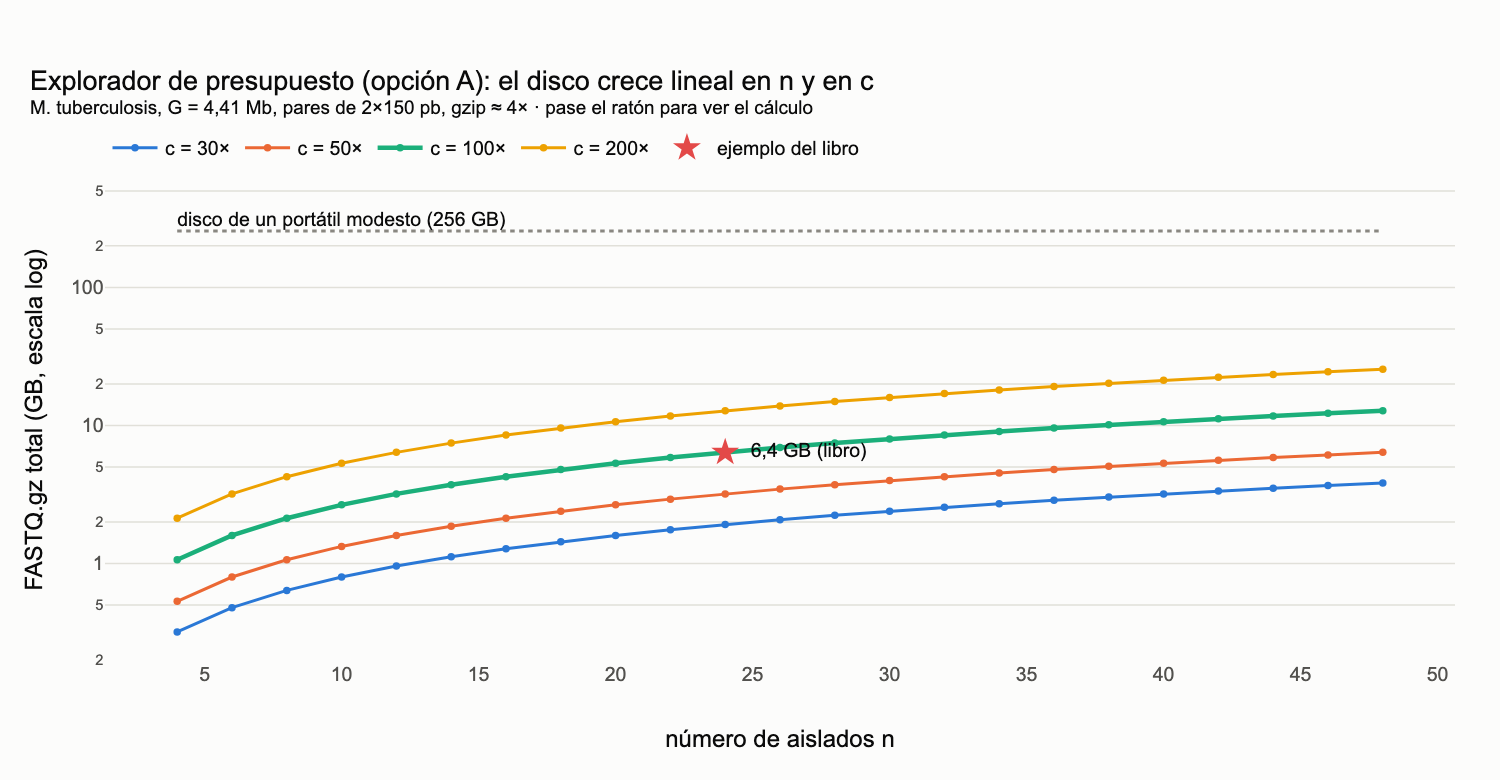

In [4]:
depths = [30, 50, 100, 200]
ns = list(range(4, 49, 2))
fig = go.Figure()
for k, c in enumerate(depths):
    rows = [budget(c=c, n=n) for n in ns]
    per = rows[0]["FASTQ.gz por muestra (GB)"]
    Nn = rows[0]["pares por muestra N"]
    fig.add_trace(go.Scatter(
        x=ns, y=[r[f"total gz, n={n} (GB)"] for r, n in zip(rows, ns)], mode="lines+markers", name=f"c = {c}×",
        line=dict(color=ec.CATEGORICAL[k], width=3 if c == 100 else 2), marker=dict(size=5),
        customdata=[[c, Nn / 1e6, per, n] for n in ns],
        hovertemplate=("<b>%{customdata[3]} aislados a %{customdata[0]}×</b><br>"
                       "N = cG/(2L) = %{customdata[1]:.2f} millones de pares por muestra<br>"
                       "FASTQ.gz ≈ %{customdata[2]:.2f} GB por muestra<br>"
                       "<b>total ≈ %{y:.1f} GB</b><extra></extra>")))
fig.add_trace(go.Scatter(x=[24], y=[bA["total gz, n=24 (GB)"]], mode="markers+text", name="ejemplo del libro",
                         marker=dict(size=14, color=ec.RED, symbol="star"), text=["  6,4 GB (libro)"],
                         textposition="middle right", hovertemplate="Ejemplo del libro: 24 aislados a 100× → %{y:.1f} GB<extra></extra>"))
fig.add_trace(go.Scatter(x=[ns[0], ns[-1]], y=[256, 256], mode="lines+text", line=dict(color=ec.MUTED, dash="dot"),
                         text=["disco de un portátil modesto (256 GB)", ""], textposition="top right", showlegend=False,
                         hovertemplate="Referencia: un portátil con 256 GB de disco<extra></extra>"))
fig.update_layout(
    title="Explorador de presupuesto (opción A): el disco crece lineal en n y en c<br>"
          "<sup>M. tuberculosis, G = 4,41 Mb, pares de 2×150 pb, gzip ≈ 4× · pase el ratón para ver el cálculo</sup>",
    xaxis_title="número de aislados n", yaxis_title="FASTQ.gz total (GB, escala log)", yaxis_type="log",
    yaxis_range=[math.log10(0.2), math.log10(600)],
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=520, margin=dict(t=120, l=70, r=30))
fig.show()

> 🔎 **Qué observamos.** En escala logarítmica las curvas son copias desplazadas unas de otras: el disco es
> $\propto c\cdot n$, así que duplicar $c$ sube la curva la misma distancia para cualquier $n$. Incluso 48
> aislados a $200\times$ caben en un disco de un portátil. Para bacterias, el **disco de los datos crudos** rara vez es el
> problema; lo son los **intermedios** (SAM sin comprimir, BAM sin ordenar), que pueden ocupar varias veces lo que los
> crudos si no se marcan con `temp()`. Y el tiempo: veamos cómo baja $T_P$ con el número de núcleos, con y sin dividir el
> llamado.

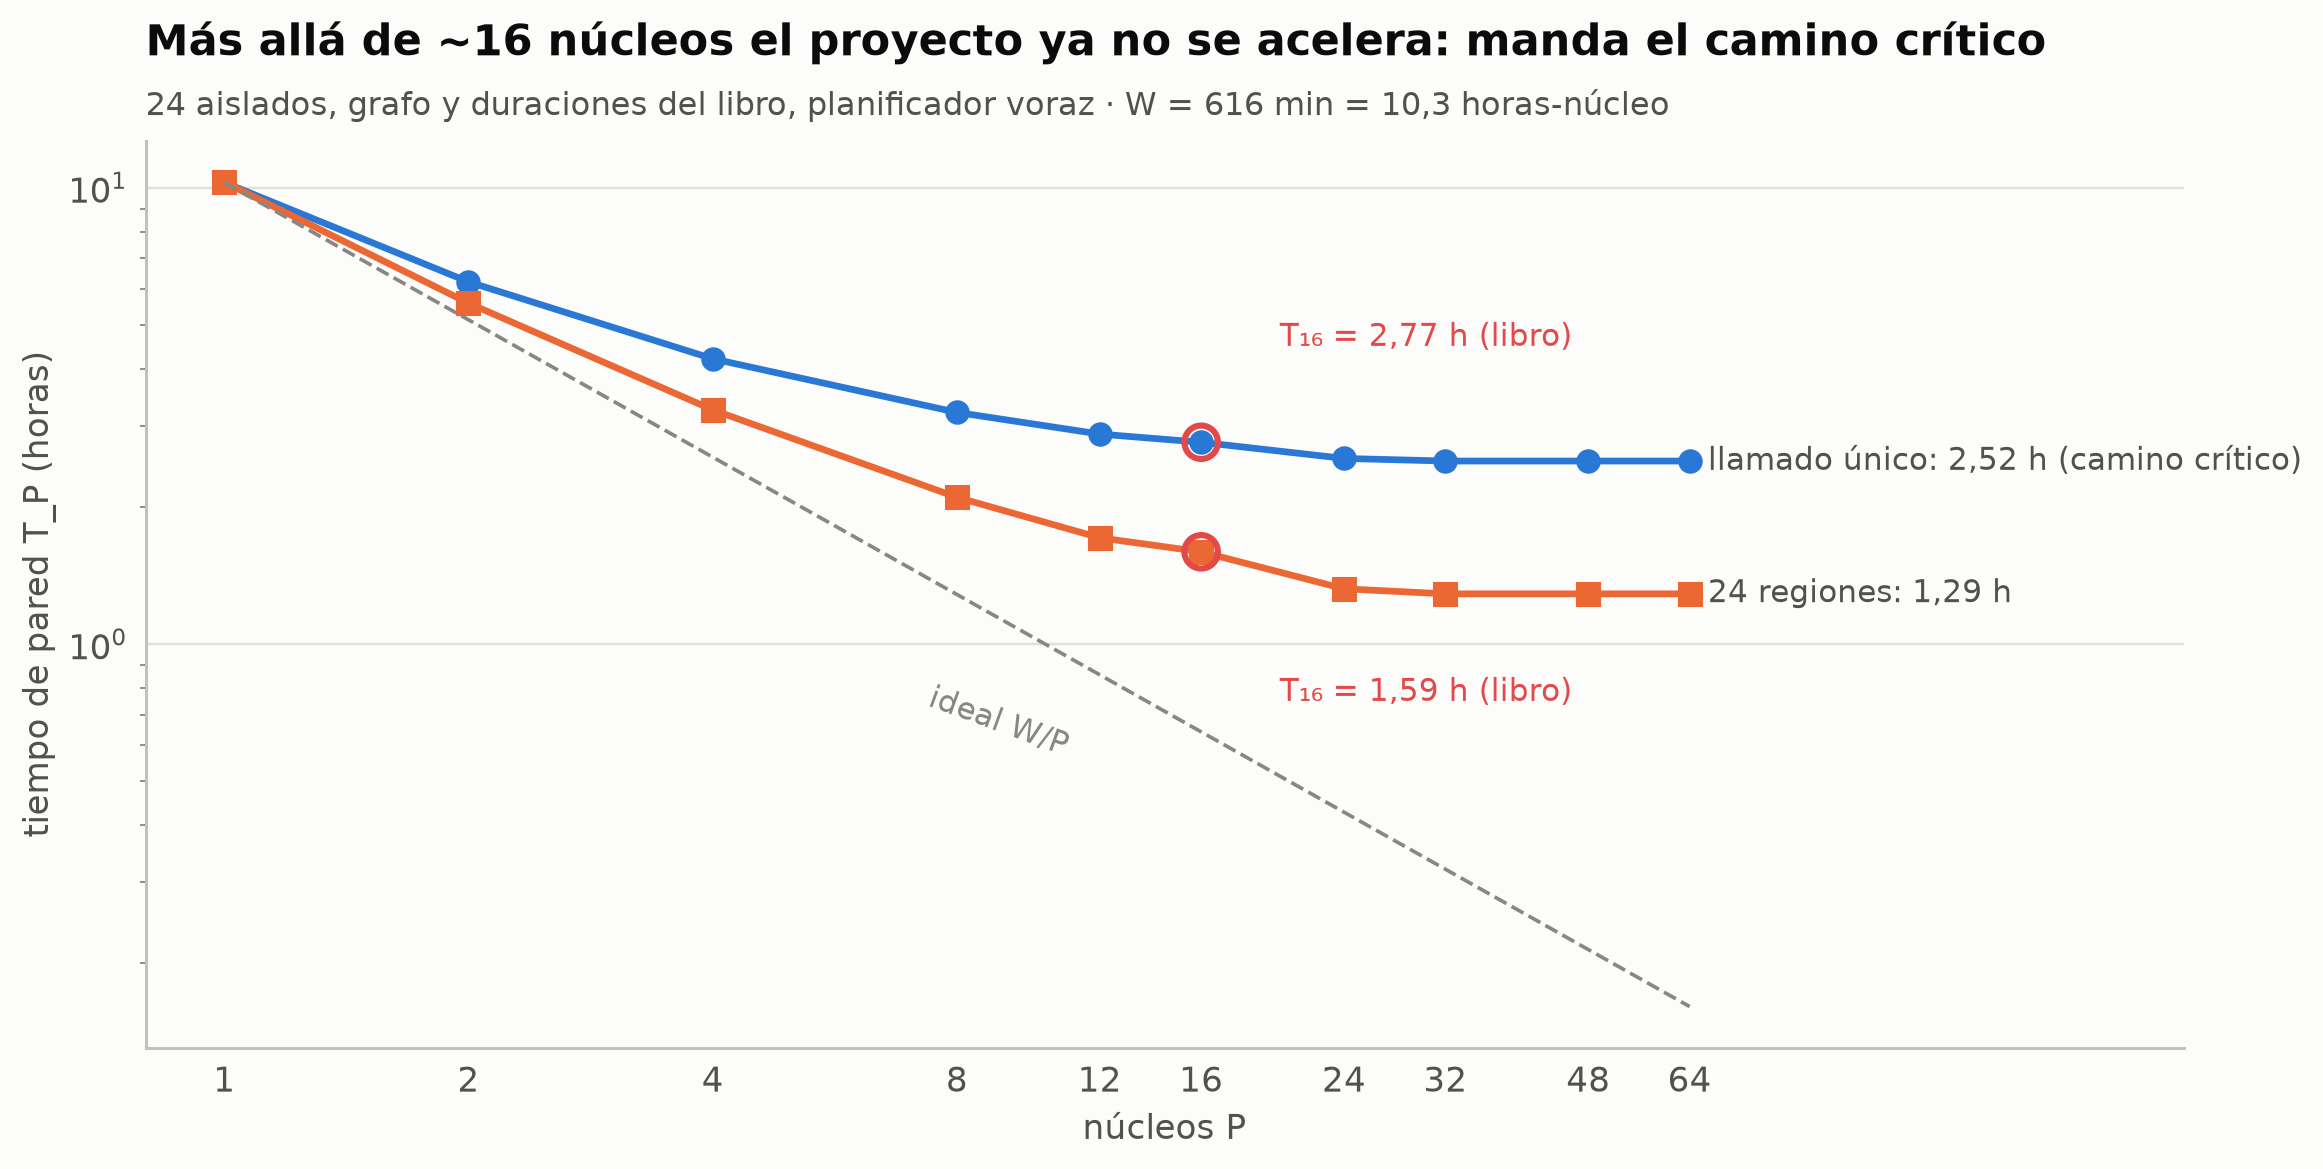

In [5]:
Ps = [1, 2, 4, 8, 12, 16, 24, 32, 48, 64]
TP_base = [compute_budget(24, P)[1] / 60 for P in Ps]
TP_scat = [compute_budget(24, P, regions=24)[1] / 60 for P in Ps]
fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.plot(Ps, TP_base, "o-", color=ec.BLUE, lw=2.2)
ax.plot(Ps, TP_scat, "s-", color=ec.ORANGE, lw=2.2)
ax.plot(Ps, [W24 / 60 / P for P in Ps], "--", color=ec.MUTED, lw=1.2)
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xticks(Ps); ax.set_xticklabels([str(P) for P in Ps])
fmt = lambda v: f"{v:.2f}".replace(".", ",")
ec.label_end(ax, Ps[-1], TP_base[-1], f"llamado único: {fmt(TP_base[-1])} h (camino crítico)")
ec.label_end(ax, Ps[-1], TP_scat[-1], f"24 regiones: {fmt(TP_scat[-1])} h")
ax.text(9, W24 / 60 / 9 * 0.72, "ideal W/P", color=ec.MUTED, fontsize=10, rotation=-20, ha="center", va="top")
ax.scatter([16, 16], [T16 / 60, T16s / 60], s=120, facecolor="none", edgecolor=ec.RED, lw=2, zorder=5)
ax.annotate(f"T₁₆ = {fmt(T16 / 60)} h (libro)", (16, T16 / 60), xytext=(20, 4.5), color=ec.RED, fontsize=10,
            arrowprops=dict(arrowstyle="-", color=ec.RED))
ax.annotate(f"T₁₆ = {fmt(T16s / 60)} h (libro)", (16, T16s / 60), xytext=(20, 0.75), color=ec.RED, fontsize=10,
            arrowprops=dict(arrowstyle="-", color=ec.RED))
ax.set_xlabel("núcleos P")
ax.set_ylabel("tiempo de pared T_P (horas)")
ax.set_xlim(0.8, 260)
ec.title(ax, "Más allá de ~16 núcleos el proyecto ya no se acelera: manda el camino crítico",
         "24 aislados, grafo y duraciones del libro, planificador voraz · W = 616 min = 10,3 horas-núcleo")
plt.show()

> 🔎 **Qué observamos.** La curva azul se aplana en torno a 2,5 h: por muchos núcleos que pidamos, el llamado conjunto y la
> filogenia (que crecen con $n$) no se reparten. Dividir el llamado en regiones (naranja) baja el piso a ~1,3 h. La
> decisión práctica para el presupuesto: **pedir 16 núcleos** y dividir el llamado; pedir 64 sería malgastar la cuota del
> clúster.

### ¿Y la opción B? Un presupuesto con datos reales

Para la opción B usemos las cifras **reales** del experimento *airway* (Himes *et al.*, 2014; SRP033351), que ya analizamos
en el Módulo 11: 16 corridas de lecturas pareadas de células de músculo liso de las vías respiratorias tratadas con
dexametasona, albuterol, ambos o nada. El SRA publica el número de pares (*spots*) y de bases de cada corrida; con el mismo
modelo de bytes estimamos el disco.

In [6]:
air = pd.read_csv(course_file("airway_SRP033351_samples.tsv"), sep="\t")
air["L media"] = air.bases / air.spots / 2
air["FASTQ.gz (GB)"] = air.spots * 2 * (2 * air["L media"] + 2 + 60) / 4 / 1e9
print(f"{len(air)} corridas · {air.spots.sum() / 1e6:.0f} millones de pares · {air.bases.sum() / 1e9:.1f} Gb · "
      f"L media = {air['L media'].mean():.0f} pb · disco gz ≈ {air['FASTQ.gz (GB)'].sum():.0f} GB")
display(air.groupby("treatment").agg(corridas=("run", "size"), pares_M_media=("spots", lambda s: round(s.mean() / 1e6, 1)),
                                     disco_GB_total=("FASTQ.gz (GB)", "sum")).round(1))
print(f"corridas con longitud media de lectura menor que 63 pb: {(air['L media'] < 62.9).sum()} de {len(air)}")

16 corridas · 491 millones de pares · 57.2 Gb · L media = 59 pb · disco gz ≈ 44 GB


,corridas,pares_M_media,disco_GB_total
treatment,,,
Albuterol,4,30.4,11.4
Albuterol_Dexamethasone,4,28.5,10.3
Dexamethasone,4,35.0,11.8
Untreated,4,28.9,10.4


corridas con longitud media de lectura menor que 63 pb: 7 de 16


> 🔎 **Qué observamos.** Unos 44 GB de FASTQ comprimido, siete veces más que la opción A: el transcriptoma humano se
> secuenció aquí con 21–43 millones de pares de hasta $2\times63$ pb por muestra (en 7 de las 16 corridas las lecturas son en
> promedio más cortas, y por eso la longitud media es 59 pb). En la tabla, `pares_M_media` es la media de pares por corrida (en millones)
> y `disco_GB_total`, la suma del disco de las cuatro corridas de cada tratamiento. Pero cuantificar con Salmon (Lección 11.1) cuesta minutos por
> muestra, así que el cómputo sigue siendo modesto. El diseño cumple el requisito de la opción B: **cuatro líneas celulares
> por tratamiento**, que son las réplicas biológicas (y un factor de bloque en el modelo de la Lección 11.3).

> ✅ **Compruebe su comprensión.** ¿Por qué el disco de la opción A no depende de la longitud $L$ de las lecturas (a igual
> $c$), salvo por las cabeceras? *(Respuesta: porque $2L\cdot N = cG$ es fijo; lecturas más largas significan menos
> pares. Sólo las cabeceras, $h$ por lectura, pesan más cuando hay más lecturas cortas.)*

## 3. Estructura del proyecto: generamos el esqueleto

Un proyecto computacional bien organizado se entiende **al abrir su carpeta principal**, igual que una cocina ordenada en la
que cualquiera encuentra la sal. Noble (2009) propuso una organización que se ha vuelto casi un estándar: una carpeta para
datos, otra para resultados, otra para código y otra para documentación, con un principio innegociable: **los datos crudos
son de sólo lectura** y todo lo demás puede regenerarse desde ellos con una única orden. Wilson *et al.* (2017) llaman a
esto las prácticas «suficientemente buenas»: no hace falta ser ingeniero de *software*, basta con ser consistente.

La adaptación del libro a un flujo con Snakemake (con Nextflow bastaría cambiar `workflow/Snakefile` por `main.nf` y
`nextflow.config`):

| Entrada | Contenido | ¿En Git? |
|---|---|---|
| `README.md` | cómo instalar, ejecutar y citar | ✅ |
| `LICENSE`, `CITATION.cff` | licencia y forma de citar | ✅ |
| `workflow/Snakefile` | el flujo (Lección 18.1) | ✅ |
| `config/config.yaml` | muestras, referencia, umbrales | ✅ |
| `config/muestras.tsv` | metadatos por muestra | ✅ |
| `envs/*.yaml` | entornos con versiones exactas | ✅ |
| `scripts/` | código propio (Python, R) | ✅ |
| `tests/` | datos mínimos y pruebas `test_*.py` | ✅ |
| `informe/` | informe reproducible | ✅ |
| `datos/` | crudos, de sólo lectura | ❌ |
| `ref/` | referencia descargada y verificada | ❌ |
| `resultados/`, `logs/` | todo lo que el flujo regenera | ❌ |
| `.gitignore`, `checksums.sha256` | excluye datos; registra sus sumas | ✅ |

**La regla de oro:** borrar `resultados/` nunca debe ser una catástrofe, porque una orden lo reconstruye.

Vamos a **construir de verdad** ese proyecto para nuestra pregunta del curso, el clon REL7179B del experimento de evolución
a largo plazo (LTEE) de Lenski, secuenciado en la corrida SRR2584863:

> **Pregunta.** ¿Qué mutaciones puntuales (SNV) ha acumulado el clon REL7179B respecto de su ancestro REL606, en qué genes
> caen y qué efecto tienen sobre las proteínas?

Es una versión en miniatura de la opción A: un «aislado» en lugar de 24, y las lecturas de las ventanas alrededor de sus
variantes (Lección 9.2) en lugar del genoma completo, para que todo corra en segundos. Como en la Lección 18.1, repartimos
los pares de lecturas en tres submuestras A, B y C (como tres carriles del secuenciador), de modo que el flujo tenga pasos
por muestra y pasos conjuntos. El proyecto vive en una carpeta temporal, **fuera** del repositorio del curso.

In [7]:
PROJ = os.path.join(TMP, "proyecto-ltee")
shutil.rmtree(PROJ, ignore_errors=True)            # empezamos siempre desde cero
for d in ("workflow", "config", "envs", "scripts", "tests/datos", "informe", "datos", "ref"):
    os.makedirs(os.path.join(PROJ, d), exist_ok=True)

def gz_writer(path):
    """gzip determinista: mtime=0, así el mismo contenido da siempre los mismos bytes (y la misma suma SHA-256)."""
    return io.TextIOWrapper(gzip.GzipFile(path, "wb", compresslevel=6, mtime=0))

def fetch_inputs(root):
    """Coloca los datos crudos y la referencia en root/datos y root/ref. En un proyecto real, aquí se
    descargarían las lecturas por su accesión (SRR2584863) y el genoma por la suya (NC_012967.1)."""
    os.makedirs(f"{root}/datos", exist_ok=True)
    os.makedirs(f"{root}/ref", exist_ok=True)
    # datos/: el par i va a la submuestra i mod 3 (A, B, C), como en la Lección 18.1
    readers = [gzip.open(course_file(f"SRR2584863_variant_windows_{r}.fastq.gz"), "rt") for r in (1, 2)]
    writers = {(m, r): gz_writer(f"{root}/datos/{m}_R{r}.fastq.gz") for m in "ABC" for r in (1, 2)}
    i = 0
    while True:
        recs = [[fh.readline() for _ in range(4)] for fh in readers]
        if not recs[0][0]:
            break
        for r in (1, 2):
            writers["ABC"[i % 3], r].writelines(recs[r - 1])
        i += 1
    for fh in list(writers.values()) + readers:
        fh.close()
    # ref/: el genoma del ancestro REL606 (NC_012967.1) y su anotación de RefSeq
    with gzip.open(course_file("NC_012967.1.fasta.gz"), "rt") as fh, open(f"{root}/ref/REL606.fa", "w") as out:
        out.write(fh.read())
    shutil.copy(course_file("NC_012967.1_features.tsv.gz"), f"{root}/ref/genes.tsv.gz")
    return i

i = fetch_inputs(PROJ)
# informe/: el estilo gráfico del curso viaja con el proyecto (también es código del que dependen las figuras)
shutil.copy(ec.__file__, f"{PROJ}/informe/estilo_curso.py")
open(f"{PROJ}/scripts/__init__.py", "w").close()
print(f"{i:,} pares repartidos en A, B y C · proyecto en {PROJ}")

17,910 pares repartidos en A, B y C · proyecto en /tmp/proyecto-ltee


Ahora los archivos de texto, uno por celda, como los escribiría usted. Primero el `README`, que debe responder **cuatro
preguntas**: qué hace el proyecto, cómo se instala el entorno, cómo se ejecuta (idealmente una orden) y cómo se cita.

In [8]:
%%writefile {PROJ}/README.md
# proyecto-ltee

Mutaciones puntuales del clon **REL7179B** del experimento de evolución a largo plazo (LTEE) de *E. coli*
respecto de su ancestro **REL606**: llamado, anotación del efecto en las proteínas e informe reproducible.

## Pregunta
¿Qué SNV ha acumulado REL7179B frente a REL606, en qué genes caen y qué efecto tienen?

## Instalar
    conda env create -f envs/mapeo.yaml     # bwa, samtools, bcftools
    conda env create -f envs/python.yaml    # snakemake, pandas, matplotlib, pytest

## Ejecutar (una orden)
    snakemake --cores 4                     # o: snakemake --cores 4 --sdm conda

## Probar
    python -m pytest -q tests/                                  # pruebas unitarias
    snakemake --cores 2 --configfile tests/config_mini.yaml     # integración con datos simulados

## Datos
Corrida SRR2584863 (BioProject PRJNA295606, BioSample SAMN04096083) del SRA/ENA; las sumas SHA-256 de los
archivos de entrada están en `checksums.sha256` (`sha256sum -c checksums.sha256`).

## Citar
Véase `CITATION.cff`. Licencia MIT (`LICENSE`).

Writing /tmp/proyecto-ltee/README.md


In [9]:
%%writefile {PROJ}/CITATION.cff
cff-version: 1.2.0
message: "Si usa este análisis, cítelo con estos metadatos."
title: "proyecto-ltee: mutaciones del clon REL7179B del LTEE frente a REL606"
version: 1.0.0
date-released: 2026-10-01
license: MIT
authors:
  - family-names: "Apellido"
    given-names: "Nombre"
    affiliation: "Maestría en Bioinformática"
repository-code: "https://github.com/usuario/proyecto-ltee"
keywords: [LTEE, "Escherichia coli", variantes, Snakemake, reproducibilidad]

Writing /tmp/proyecto-ltee/CITATION.cff


In [10]:
lic = """MIT License

Copyright (c) 2026 Apellido, Nombre

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated
documentation files (the "Software"), to deal in the Software without restriction, including without limitation
the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to
permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of
the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED.
"""
open(f"{PROJ}/LICENSE", "w").write(lic)
print("LICENSE escrito (MIT, texto abreviado para el ejemplo: en su proyecto copie el texto completo)")

LICENSE escrito (MIT, texto abreviado para el ejemplo: en su proyecto copie el texto completo)


La **configuración** separa lo que cambia entre proyectos (muestras, referencia, umbrales, semilla) de la lógica del flujo.
La tabla de muestras es a la vez la entrada del flujo y la hoja de metadatos para el depósito (sección 7): sus columnas
siguen los campos que piden el SRA y el ENA. Los valores de REL7179B vienen del propio ENA.

In [11]:
%%writefile {PROJ}/config/config.yaml
muestras: "config/muestras.tsv"       # una fila por muestra: alimenta el flujo y el depósito
dir_datos: "datos"
referencia: "ref/REL606.fa"           # NC_012967.1
anotacion: "ref/genes.tsv.gz"         # CDS de RefSeq, coordenadas 1-based inclusivas
calidad_minima: 20                    # calidad media mínima de cada lectura del par (Phred)
filtro: "QUAL>=30 && INFO/DP>=10"     # bcftools filter -i
semilla: 2026                         # ω: datos simulados de las pruebas

Writing /tmp/proyecto-ltee/config/config.yaml


In [12]:
%%writefile {PROJ}/config/muestras.tsv
muestra	run_accession	experiment_accession	sample_accession	study_accession	organismo	cepa	carril	fecha_colecta	pais	hospedero	tipo_muestra	plataforma	estrategia	disposicion
A	SRR2584863	SRX1317390	SAMN04096083	PRJNA295606	Escherichia coli B str. REL606	REL7179B	1/3	not applicable	not applicable	not applicable	cultivo de laboratorio	ILLUMINA	WGS	PAIRED
B	SRR2584863	SRX1317390	SAMN04096083	PRJNA295606	Escherichia coli B str. REL606	REL7179B	2/3	not applicable	not applicable	not applicable	cultivo de laboratorio	ILLUMINA	WGS	PAIRED
C	SRR2584863	SRX1317390	SAMN04096083	PRJNA295606	Escherichia coli B str. REL606	REL7179B	3/3	not applicable	not applicable	not applicable	cultivo de laboratorio	ILLUMINA	WGS	PAIRED

Writing /tmp/proyecto-ltee/config/muestras.tsv


Los **entornos** declaran las versiones **exactas** de cada programa (Bioconda; Grüning *et al.*, 2018). Estos dos
archivos son los del **proyecto del estudiante**: `mapeo.yaml` fija las mismas versiones que el libro y la Lección 18.1
(`bwa` 0.7.18, `samtools` 1.20). Este cuaderno, en cambio, no los activa: en Colab, por comodidad, instalaremos los
programas con `apt-get`, que trae versiones más antiguas, y la corrida guardada del curso usó versiones más recientes. El
informe registrará las versiones que **realmente** se usaron; si difieren del `yaml`, la procedencia lo delatará, que es
exactamente para lo que sirve.

In [13]:
%%writefile {PROJ}/envs/mapeo.yaml
name: ltee-mapeo
channels: [conda-forge, bioconda]
dependencies:
  - bwa=0.7.18
  - samtools=1.20
  - bcftools=1.20

Writing /tmp/proyecto-ltee/envs/mapeo.yaml


In [14]:
%%writefile {PROJ}/envs/python.yaml
name: ltee-python
channels: [conda-forge, bioconda]
dependencies:
  - python=3.12
  - snakemake-minimal=9.*
  - pandas=2.2
  - matplotlib=3.10
  - pytest=8.*

Writing /tmp/proyecto-ltee/envs/python.yaml


El `.gitignore` es la mitad invisible de la estructura: dice qué **no** va en Git. Los datos crudos, la referencia y todo
lo regenerable quedan fuera (pesan, cambian o se pueden reconstruir); la lista de sus **sumas** sí entra. Las barras
iniciales (`/datos/`) anclan el patrón a la raíz: así `tests/datos/`, con los datos diminutos de las pruebas, **sí** se
versiona.

In [15]:
%%writefile {PROJ}/.gitignore
# datos crudos y referencia: se descargan por su accesión y se verifican con checksums.sha256
/datos/
/ref/
# todo lo que el flujo regenera
/resultados/
/logs/
/limpio/
/mapeo/
/qc/
/variantes/
.snakemake/
__pycache__/
.pytest_cache/
# índices que el flujo crea junto a las referencias de prueba
*.amb
*.ann
*.bwt
*.pac
*.sa
*.fai

Writing /tmp/proyecto-ltee/.gitignore


El **código propio** va en `scripts/`, en funciones pequeñas que se puedan probar. Es la diferencia principal con la
Lección 18.1, donde la lógica de Python vivía en bloques `run:` dentro del *Snakefile*: allí era cómodo, pero **no se puede
importar** desde una prueba. Primero, el algoritmo de Kahn de la Lección 18.1 (lo probaremos con el ejemplo del libro):

In [16]:
%%writefile {PROJ}/scripts/kahn.py
"""Orden topológico con el algoritmo de Kahn (Lección 18.1)."""
from collections import deque


def orden_topologico(sucesores):
    """Devuelve una lista de vértices en orden topológico; lanza ValueError si el grafo tiene un ciclo.

    sucesores: dict {vértice: [hijos]}; los hijos que no son claves se tratan como hojas.
    """
    grado = {v: 0 for v in sucesores}
    for hijos in sucesores.values():
        for u in hijos:
            grado[u] = grado.get(u, 0) + 1
    cola = deque(v for v, d in grado.items() if d == 0)
    orden = []
    while cola:
        v = cola.popleft()
        orden.append(v)
        for u in sucesores.get(v, []):
            grado[u] -= 1
            if grado[u] == 0:
                cola.append(u)
    if len(orden) < len(grado):
        raise ValueError("el grafo tiene un ciclo: no existe orden topológico")
    return orden

Writing /tmp/proyecto-ltee/scripts/kahn.py


El control de calidad hace el papel de `fastp` (Lección 6.2): descarta los pares en los que alguna lectura tiene calidad
media Phred menor que el umbral. Es una simplificación deliberada, en Python puro para no depender de más programas.

In [17]:
%%writefile {PROJ}/scripts/qc.py
"""Filtro de pares de lecturas por calidad media (en el papel de fastp, Lección 6.2)."""
import gzip
import io
import json
import sys


def calidad_media(qual, offset=33):
    """Calidad Phred media de una cadena de calidades FASTQ (Phred+33)."""
    qual = qual.strip()
    return sum(ord(c) - offset for c in qual) / max(1, len(qual))


def _escritor(path):
    return io.TextIOWrapper(gzip.GzipFile(path, "wb", compresslevel=1, mtime=0))   # bytes deterministas


def filtrar_pares(r1, r2, o1, o2, qmin):
    """Copia a o1/o2 los pares cuyas dos lecturas tienen calidad media >= qmin. Devuelve un resumen."""
    total = kept = bases = 0
    with gzip.open(r1, "rt") as f1, gzip.open(r2, "rt") as f2, _escritor(o1) as w1, _escritor(o2) as w2:
        while True:
            a = [f1.readline() for _ in range(4)]
            b = [f2.readline() for _ in range(4)]
            if not a[0]:
                break
            total += 1
            if min(calidad_media(a[3]), calidad_media(b[3])) >= qmin:
                kept += 1
                bases += len(a[1].strip()) + len(b[1].strip())
                w1.writelines(a)
                w2.writelines(b)
    return {"pares": total, "conservados": kept, "bases_conservadas": bases}


if __name__ == "__main__":
    r1, r2, o1, o2, js, qmin, muestra = sys.argv[1:8]
    res = {"muestra": muestra, **filtrar_pares(r1, r2, o1, o2, float(qmin))}
    with open(js, "w") as fh:
        json.dump(res, fh, indent=1)

Writing /tmp/proyecto-ltee/scripts/qc.py


La anotación hace el papel de SnpEff (Lección 9.3), un poco más ambiciosa que en la 18.1: además del gen, calcula el
**efecto en la proteína**. Para una SNV en la posición $p$ de un CDS que empieza en $s$ y termina en $e$ (coordenadas
1-based inclusivas), el desplazamiento dentro del gen es $k=p-s$ en la hebra $+$ y $k=e-p$ en la hebra $-$ (donde además
hay que complementar las bases); el codón afectado es el número $\lfloor k/3\rfloor+1$ y la posición dentro del codón,
$k \bmod 3$. Traducimos el codón de referencia y el mutado con el código genético estándar y clasificamos: **sinónima**
(mismo aminoácido), **de sentido erróneo** (otro aminoácido), **sin sentido** (aparece un codón de parada) o **pérdida de
parada**.

In [18]:
%%writefile {PROJ}/scripts/anotar.py
"""Anotación de SNV: gen afectado y efecto en la proteína (en el papel de SnpEff, Lección 9.3)."""
import csv
import gzip
import sys

BASES = "TCAG"
AMINO = "FFLLSSSSYY**CC*WLLLLPPPPHHQQRRRRIIIMTTTTNNKKSSRRVVVVAAAADDEEGGGG"
CODIGO = {a + b + c: AMINO[16 * i + 4 * j + k]
          for i, a in enumerate(BASES) for j, b in enumerate(BASES) for k, c in enumerate(BASES)}
COMP = str.maketrans("ACGTN", "TGCAN")


def revcomp(s):
    return s.translate(COMP)[::-1]


def leer_fasta(path):
    with open(path) as fh:
        return "".join(l.strip() for l in fh if not l.startswith(">")).upper()


def leer_cds(path):
    with gzip.open(path, "rt") as fh:
        filas = csv.DictReader((l for l in fh if not l.startswith("#")), delimiter="\t")
        return [dict(r, start=int(r["start"]), end=int(r["end"])) for r in filas if r["type"] == "CDS"]


def consecuencia(genoma, cds, pos, alt):
    """Efecto de la SNV pos>alt (1-based) sobre el CDS dado. genoma: cadena (índice 0 = posición 1)."""
    s, e = cds["start"], cds["end"]
    if (e - s + 1) % 3:
        return {"efecto": "CDS irregular (pseudogén)"}
    gen = genoma[s - 1:e]
    k = pos - s
    if cds["strand"] == "-":
        gen, k, alt = revcomp(gen), e - pos, alt.translate(COMP)
    n_codon, fase = k // 3, k % 3
    ref_codon = gen[3 * n_codon: 3 * n_codon + 3]
    alt_codon = ref_codon[:fase] + alt + ref_codon[fase + 1:]
    aa_ref, aa_alt = CODIGO.get(ref_codon, "X"), CODIGO.get(alt_codon, "X")
    if aa_ref == aa_alt:
        efecto = "sinónima"
    elif aa_alt == "*":
        efecto = "sin sentido"
    elif aa_ref == "*":
        efecto = "pérdida de parada"
    else:
        efecto = "de sentido erróneo"
    return {"efecto": efecto, "codon": f"{ref_codon}>{alt_codon}", "cambio": f"{aa_ref}{n_codon + 1}{aa_alt}"}


def anotar(vcf, cds, genoma):
    """Una fila por SNV del VCF (bgzip) con el gen, el producto y el efecto."""
    filas = []
    with gzip.open(vcf, "rt") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            f = line.rstrip("\n").split("\t")
            pos, ref, alt = int(f[1]), f[3], f[4].split(",")[0]
            hits = [c for c in cds if c["start"] <= pos <= c["end"]]
            fila = {"POS": pos, "REF": ref, "ALT": alt, "QUAL": round(float(f[5]), 1),
                    "gen": "intergénica", "producto": "", "efecto": "intergénica", "codon": "", "cambio": ""}
            if hits:
                c = hits[0]
                fila.update(gen=c["gene"] or c["locus_tag"], producto=c["product"],
                            **consecuencia(genoma, c, pos, alt))
            filas.append(fila)
    return filas


if __name__ == "__main__":
    vcf, genes, ref, out = sys.argv[1:5]
    filas = anotar(vcf, leer_cds(genes), leer_fasta(ref))
    cols = ["POS", "REF", "ALT", "QUAL", "gen", "efecto", "cambio", "codon", "producto"]
    with open(out, "w") as fh:
        fh.write("\t".join(cols) + "\n")
        for r in filas:
            fh.write("\t".join(str(r.get(c, "")) for c in cols) + "\n")

Writing /tmp/proyecto-ltee/scripts/anotar.py


Y un generador de **datos de prueba simulados** (la semilla $\omega$ de la configuración entra aquí): un fragmento de 10 kb
de REL606 que contiene el gen *topA*, con **una SNV plantada** en la segunda base del codón 101 (una transición, que por
estar en la segunda posición del codón cambia siempre el aminoácido), y 1 500 pares de lecturas de $2\times150$ pb con un
0,1 % de errores. Como sabemos la respuesta, la prueba de integración podrá comprobar que el flujo la encuentra.

In [19]:
%%writefile {PROJ}/scripts/simular_mini.py
"""Datos diminutos para la prueba de integración: 10 kb de REL606 con una SNV conocida y lecturas simuladas."""
import gzip
import io
import json
import random
import sys

sys.path.insert(0, ".")
from scripts.anotar import leer_fasta, revcomp  # noqa: E402

TRANSICION = {"A": "G", "G": "A", "C": "T", "T": "C"}


def simular(ref, genes, salida, semilla, ini=1326001, fin=1336000, gen_ini=1329420, n_pares=1500, L=150,
            inserto=350, error=0.001):
    rng = random.Random(semilla)
    frag = leer_fasta(ref)[ini - 1:fin]
    pos_gen = gen_ini + 3 * 100 + 1                       # 2.ª base del codón 101 de topA
    k = pos_gen - ini
    alt = TRANSICION[frag[k]]
    mut = frag[:k] + alt + frag[k + 1:]
    with open(f"{salida}/ref_mini.fa", "w") as fh:
        fh.write(">mini\n" + "\n".join(frag[i:i + 60] for i in range(0, len(frag), 60)) + "\n")
    with gzip.open(genes, "rt") as fh, io.TextIOWrapper(gzip.GzipFile(f"{salida}/genes_mini.tsv.gz", "wb", mtime=0)) as out:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if line.startswith("#"):
                continue
            if f[0] == "type":
                out.write(line)
            elif int(f[3]) >= ini and int(f[4]) <= fin:
                f[3], f[4] = str(int(f[3]) - ini + 1), str(int(f[4]) - ini + 1)
                out.write("\t".join(f) + "\n")

    def ruido(s):
        return "".join(rng.choice("ACGT".replace(b, "")) if rng.random() < error else b for b in s)

    w = [io.TextIOWrapper(gzip.GzipFile(f"{salida}/mini_R{r}.fastq.gz", "wb", mtime=0)) for r in (1, 2)]
    for i in range(n_pares):
        a = rng.randrange(0, len(mut) - inserto)
        frag_ins = mut[a:a + inserto]
        r1, r2 = frag_ins[:L], revcomp(frag_ins)[:L]
        if rng.random() < 0.5:
            r1, r2 = r2, r1
        for fh, s in zip(w, (r1, r2)):
            fh.write(f"@mini_{i}\n{ruido(s)}\n+\n{'I' * L}\n")
    for fh in w:
        fh.close()
    verdad = {"POS": k + 1, "REF": frag[k], "ALT": alt, "gen": "topA", "semilla": semilla}
    with open(f"{salida}/verdad.json", "w") as fh:
        json.dump(verdad, fh)
    return verdad


if __name__ == "__main__":
    print(simular(sys.argv[1], sys.argv[2], sys.argv[3], int(sys.argv[4])))

Writing /tmp/proyecto-ltee/scripts/simular_mini.py


El **informe** es el último eslabón del flujo, no un documento aparte: un *script* que lee **sólo** archivos generados por
el flujo y escribe tablas, una figura y un registro de **procedencia** (versiones, *commit*, sumas SHA-256). Ningún número
se copia a mano (regla 9 de Sandve *et al.*, 2013: conectar cada afirmación con el resultado que la sustenta). Aquí es un
*script* para que corra en un segundo; en su proyecto puede ser un cuaderno Jupyter ejecutado por una regla.

In [20]:
%%writefile {PROJ}/informe/informe.py
"""Informe reproducible: lee sólo salidas del flujo; escribe informe.md, una figura y procedencia.json."""
import argparse
import datetime
import glob
import hashlib
import json
import os
import platform
import re
import subprocess
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
try:
    import estilo_curso as ec
    ec.set_style()
    COL = dict(zip(["de sentido erróneo", "sinónima", "sin sentido", "intergénica", "CDS irregular (pseudogén)"],
                   [ec.BLUE, ec.AQUA, ec.RED, ec.ORANGE, ec.MUTED]))
except Exception:            # el informe no debe fallar por el estilo
    ec, COL = None, {}

TRANSICIONES = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}


def sha256(path, bloque=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for trozo in iter(lambda: fh.read(bloque), b""):
            h.update(trozo)
    return h.hexdigest()


def salida(cmd):
    try:
        p = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=30)
        return (p.stdout + p.stderr).strip()
    except Exception:
        return ""


def version(cmd):
    txt = salida(cmd).splitlines()
    return next((l.strip() for l in txt if re.search(r"\d+\.\d+", l)), "no encontrado")


def flagstat(path):
    txt = open(path).read()
    num = lambda pat: int(re.search(r"^(\d+) \+ \d+ " + pat, txt, re.M).group(1))
    return {"lecturas": num("in total"), "mapeadas": num("mapped"), "duplicados": num("duplicates")}


def tabla_md(df):
    """Tabla Markdown sin dependencias externas."""
    filas = ["| " + " | ".join(map(str, df.columns)) + " |", "|" + "---|" * len(df.columns)]
    filas += ["| " + " | ".join(map(str, r)) + " |" for r in df.itertuples(index=False)]
    return "\n".join(filas)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--ref"); ap.add_argument("--genes"); ap.add_argument("--datos")
    ap.add_argument("--muestras", nargs="+")
    a = ap.parse_args()
    os.makedirs("resultados/figuras", exist_ok=True)

    # 1. calidad y mapeo, muestra por muestra
    filas = []
    for m in a.muestras:
        q = json.load(open(f"qc/{m}.json"))
        f = flagstat(f"qc/{m}.flagstat.txt")
        filas.append({"muestra": m, "pares": q["pares"], "conservados": q["conservados"],
                      "% conservados": round(100 * q["conservados"] / q["pares"], 1),
                      "% mapeadas": round(100 * f["mapeadas"] / f["lecturas"], 2),
                      "% duplicados": round(100 * f["duplicados"] / f["lecturas"], 2)})
    qc = pd.DataFrame(filas)
    qc.to_csv("resultados/qc_resumen.tsv", sep="\t", index=False)

    # 2. variantes
    var = pd.read_csv("resultados/anotado.tsv", sep="\t", keep_default_na=False)
    ts = sum((r, al) in TRANSICIONES for r, al in zip(var.REF, var.ALT))
    tv = len(var) - ts
    efectos = var.efecto.value_counts()

    # 3. figura resumen
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 2.4]})
    ax1.barh(qc.muestra, qc.conservados, color=COL.get("sinónima", "tab:green"))
    ax1.barh(qc.muestra, qc.pares - qc.conservados, left=qc.conservados, color="#c3c2b7")
    for y, (p, pm) in enumerate(zip(qc.pares, qc["% mapeadas"])):
        ax1.text(p * 1.02, y, f"{pm:.1f} % mapeadas", va="center", fontsize=9)
    ax1.set_xlim(0, qc.pares.max() * 1.55)
    ax1.set_xlabel("pares de lecturas (gris: descartados por calidad)")
    ax1.set_title("Calidad y mapeo", loc="left", fontsize=12)
    ax1.invert_yaxis()
    glen = sum(len(l.strip()) for l in open(a.ref) if not l.startswith(">"))
    ax2.axhline(0, color="#c3c2b7", lw=6)
    for k, r in enumerate(var.sort_values("POS").itertuples()):
        h = 1 + (k % 3) * 0.5
        c = COL.get(r.efecto, "tab:blue")
        ax2.plot([r.POS / 1e6] * 2, [0, h], color=c, lw=1.2)
        ax2.scatter(r.POS / 1e6, h, s=34, color=c, zorder=3)
        ax2.text(r.POS / 1e6, h + 0.1, r.gen, rotation=60, fontsize=8, ha="left", va="bottom",
                 style="italic" if not r.gen.startswith(("ECB", "inter")) else "normal")
    from matplotlib.lines import Line2D
    ax2.legend([Line2D([], [], marker="o", ls="", color=COL.get(e, "k")) for e in efectos.index],
               [f"{e} ({n})" for e, n in efectos.items()], loc="upper left", ncol=len(efectos), fontsize=9,
               handletextpad=0.2, columnspacing=1.2)
    ax2.set_xlim(-0.05, glen / 1e6 + 0.05); ax2.set_ylim(-0.3, 4.2)
    ax2.set_yticks([]); ax2.spines["left"].set_visible(False)
    ax2.set_xlabel("posición en la referencia (Mb)")
    ax2.set_title(f"{len(var)} SNV · Ti/Tv = {ts}/{tv}", loc="left", fontsize=12)
    fig.suptitle("Resumen del flujo: calidad por muestra y SNV anotadas a lo largo del genoma", x=0.01, ha="left",
                 fontweight="bold")
    fig.savefig("resultados/figuras/resumen.png", dpi=150, metadata={"Software": None})

    # 4. procedencia: qué código, qué entorno, qué datos, qué parámetros
    entradas = ([f"{a.datos}/{m}_R{r}.fastq.gz" for m in a.muestras for r in (1, 2)] + [a.ref, a.genes]
                + ["config/config.yaml", "workflow/Snakefile"] + sorted(glob.glob("scripts/*.py"))
                + ["informe/informe.py"])
    for c in ("config/muestras.tsv", "tests/muestras_mini.tsv"):
        if os.path.exists(c):
            entradas.append(c)
    commit = salida("git rev-parse HEAD") or "sin git"
    prov = {
        "fecha_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
        "commit": commit if re.fullmatch(r"[0-9a-f]{40}", commit) else "sin git",
        "etiqueta": salida("git describe --tags --always") or "",
        "cambios_sin_commit": bool(salida("git status --porcelain --untracked-files=no")),
        "python": sys.version.split()[0], "plataforma": platform.platform(),
        "versiones": {"bwa": version("bwa 2>&1 | grep -i version"), "samtools": version("samtools --version"),
                      "bcftools": version("bcftools --version"), "snakemake": version("snakemake --version"),
                      "pandas": pd.__version__, "matplotlib": matplotlib.__version__},
        "sha256_entradas": {p: sha256(p) for p in entradas if os.path.exists(p)},
        "sha256_salidas": {p: sha256(p) for p in ("resultados/anotado.tsv", "resultados/qc_resumen.tsv")},
    }
    json.dump(prov, open("resultados/procedencia.json", "w"), indent=1, ensure_ascii=False)

    # 5. el informe en Markdown: cada número sale de un archivo del flujo
    lineas = [f"# Informe del flujo · {prov['fecha_utc']}", "",
              f"*commit* `{prov['commit'][:12]}` ({prov['etiqueta']}) · cambios sin *commit*: "
              f"{'sí' if prov['cambios_sin_commit'] else 'no'}", "",
              "## 1. Calidad y mapeo", "", tabla_md(qc), "",
              "## 2. Variantes", "",
              f"{len(var)} SNV pasan el filtro; transiciones/transversiones = {ts}/{tv}; efectos: "
              + ", ".join(f"{e} ({n})" for e, n in efectos.items()) + ".", "",
              tabla_md(var[["POS", "REF", "ALT", "QUAL", "gen", "efecto", "cambio"]]), "",
              "![resumen](figuras/resumen.png)", "",
              "## 3. Procedencia", "",
              "| programa | versión |", "|---|---|"]
    lineas += [f"| {k} | {v} |" for k, v in prov["versiones"].items()]
    lineas += ["", f"Sumas SHA-256 de {len(prov['sha256_entradas'])} entradas en `resultados/procedencia.json`."]
    open("resultados/informe.md", "w").write("\n".join(lineas) + "\n")


if __name__ == "__main__":
    main()

Writing /tmp/proyecto-ltee/informe/informe.py


Por fin, el **flujo**. Es el *Snakefile* de la Lección 18.1 reorganizado: la lista de muestras sale de `muestras.tsv`, la
lógica en Python vive en `scripts/` (y se llama con `python scripts/…`), cada regla declara su entorno con `conda:` (que
Snakemake usa si se ejecuta con `--sdm conda`) y dos reglas nuevas cierran el círculo: `flagstat` (proporción de lecturas
mapeadas, una comprobación de cordura) e `informe`. Las opciones de `bwa`, `samtools` y `bcftools` son **idénticas** a
las de la 18.1, así que el resultado debe coincidir.

In [21]:
%%writefile {PROJ}/workflow/Snakefile
# proyecto-ltee · flujo principal. Ejecutar desde la raíz del proyecto: snakemake --cores 4
import csv
import os

configfile: "config/config.yaml"

MUESTRAS = [r["muestra"] for r in csv.DictReader(open(config["muestras"]), delimiter="\t")]
REF = config["referencia"]
DATOS = config["dir_datos"]

wildcard_constraints:
    m="[A-Za-z0-9-]+"


rule all:
    input:
        "resultados/anotado.tsv",
        "resultados/informe.md",


rule qc:                                   # en el papel de fastp
    input:
        r1=os.path.join(DATOS, "{m}_R1.fastq.gz"),
        r2=os.path.join(DATOS, "{m}_R2.fastq.gz"),
    output:
        r1=temp("limpio/{m}_R1.fq.gz"),
        r2=temp("limpio/{m}_R2.fq.gz"),
        js="qc/{m}.json",
    params: qmin=config["calidad_minima"]
    log: "logs/qc/{m}.log"
    conda: "../envs/python.yaml"
    shell:
        "python scripts/qc.py {input.r1} {input.r2} {output.r1} {output.r2} "
        "{output.js} {params.qmin} {wildcards.m} 2> {log}"


rule bwa_index:
    input: REF
    output: multiext(REF, ".amb", ".ann", ".bwt", ".pac", ".sa", ".fai")
    log: "logs/bwa_index.log"
    conda: "../envs/mapeo.yaml"
    shell: "bwa index {input} 2> {log} && samtools faidx {input}"


rule mapear:
    input:
        ref=REF,
        idx=rules.bwa_index.output,
        r1="limpio/{m}_R1.fq.gz",
        r2="limpio/{m}_R2.fq.gz",
    output: temp("mapeo/{m}.ordenado.bam")
    params: rg=lambda wc: f"@RG\\tID:{wc.m}\\tSM:{wc.m}"
    log: "logs/mapear/{m}.log"
    threads: 2
    conda: "../envs/mapeo.yaml"
    shell:
        """
        bwa mem -t {threads} -R '{params.rg}' {input.ref} \
            {input.r1} {input.r2} > {output}.sam 2> {log}
        samtools fixmate -m {output}.sam {output}.fm.bam
        samtools sort -@ {threads} -o {output} {output}.fm.bam 2>> {log}
        rm {output}.sam {output}.fm.bam
        """


rule dedup:
    input: "mapeo/{m}.ordenado.bam"
    output:
        bam="mapeo/{m}.dedup.bam",
        bai="mapeo/{m}.dedup.bam.bai",
    conda: "../envs/mapeo.yaml"
    shell: "samtools markdup {input} {output.bam} && samtools index {output.bam}"


rule flagstat:                             # comprobación de cordura: % de lecturas mapeadas
    input: "mapeo/{m}.dedup.bam"
    output: "qc/{m}.flagstat.txt"
    conda: "../envs/mapeo.yaml"
    shell: "samtools flagstat {input} > {output}"


rule llamar:
    input:
        ref=REF,
        idx=rules.bwa_index.output,
        bams=expand("mapeo/{m}.dedup.bam", m=MUESTRAS),
        bais=expand("mapeo/{m}.dedup.bam.bai", m=MUESTRAS),
    output: "variantes/crudo.bcf"
    log: "logs/llamar.log"
    conda: "../envs/mapeo.yaml"
    shell:
        """
        bcftools mpileup -f {input.ref} -a AD,DP -Ob \
            -o {output}.pila {input.bams} 2> {log}
        bcftools call --ploidy 1 -mv -V indels -Ob \
            -o {output} {output}.pila 2>> {log}
        rm {output}.pila
        """


rule filtrar:
    input: "variantes/crudo.bcf"
    output:
        vcf="variantes/filtrado.vcf.gz",
        tbi="variantes/filtrado.vcf.gz.tbi",
    params: expr=config["filtro"]
    conda: "../envs/mapeo.yaml"
    shell:
        "bcftools filter -i '{params.expr}' -Oz -o {output.vcf} {input} "
        "&& bcftools index -t {output.vcf}"


rule anotar:                               # en el papel de SnpEff
    input:
        vcf="variantes/filtrado.vcf.gz",
        genes=config["anotacion"],
        ref=REF,
    output: "resultados/anotado.tsv"
    conda: "../envs/python.yaml"
    shell: "python scripts/anotar.py {input.vcf} {input.genes} {input.ref} {output}"


rule informe:                              # el informe es una regla más
    input:
        anotado="resultados/anotado.tsv",
        qc=expand("qc/{m}.json", m=MUESTRAS),
        flag=expand("qc/{m}.flagstat.txt", m=MUESTRAS),
        ref=REF,
        genes=config["anotacion"],
    output:
        md="resultados/informe.md",
        fig="resultados/figuras/resumen.png",
        prov="resultados/procedencia.json",
    params: muestras=" ".join(MUESTRAS), datos=DATOS
    conda: "../envs/python.yaml"
    shell:
        "python informe/informe.py --ref {input.ref} --genes {input.genes} "
        "--datos {params.datos} --muestras {params.muestras}"

Writing /tmp/proyecto-ltee/workflow/Snakefile


Y las **pruebas**. La primera es la del libro, literal: comprueba con el grafo del ejemplo que el orden respeta todas las
dependencias y que un ciclo se detecta. La segunda prueba la anotación con un gen de juguete cuya respuesta conocemos de
antemano, en las dos hebras. La configuración mínima apunta a los datos simulados.

In [22]:
%%writefile {PROJ}/tests/test_kahn.py
import pytest
from scripts.kahn import orden_topologico

def test_respeta_dependencias():
    g = {"fastp": ["mapear"], "indice": ["mapear"],
         "mapear": ["dedup"], "dedup": []}
    pos = {v: i for i, v in enumerate(orden_topologico(g))}
    for v, hijos in g.items():
        assert all(pos[v] < pos[u] for u in hijos)

def test_detecta_ciclos():
    with pytest.raises(ValueError):
        orden_topologico({"a": ["b"], "b": ["c"], "c": ["a"]})

Writing /tmp/proyecto-ltee/tests/test_kahn.py


In [23]:
%%writefile {PROJ}/tests/test_anotar.py
from scripts.anotar import consecuencia, revcomp
from scripts.qc import calidad_media

GEN = "ATGAAATGGTAA"                      # M K W *  (posiciones 3-14 del genoma de juguete)
CDS = {"start": 3, "end": 14, "gene": "juguete", "locus_tag": "J1", "product": "proteína de juguete"}

def test_sinonima_hebra_mas():
    genoma = "CC" + GEN + "CC"            # AAA (Lys) -> AAG (Lys) en la posición 8
    r = consecuencia(genoma, dict(CDS, strand="+"), 8, "G")
    assert r["efecto"] == "sinónima" and r["cambio"] == "K2K"

def test_sin_sentido_hebra_mas():
    genoma = "CC" + GEN + "CC"            # TGG (Trp) -> TGA (parada) en la posición 11
    assert consecuencia(genoma, dict(CDS, strand="+"), 11, "A")["efecto"] == "sin sentido"

def test_hebra_menos():
    genoma = "CC" + revcomp(GEN) + "CC"   # el mismo gen leído en la hebra -: AAA->AAG es C->G en el genoma, pos 9
    r = consecuencia(genoma, dict(CDS, strand="-"), 9, "C")
    assert r["efecto"] == "sinónima" and r["codon"] == "AAA>AAG"

def test_calidad_media():
    assert calidad_media("IIII") == 40 and calidad_media("!!") == 0

Writing /tmp/proyecto-ltee/tests/test_anotar.py


In [24]:
%%writefile {PROJ}/tests/config_mini.yaml
muestras: "tests/muestras_mini.tsv"
dir_datos: "tests/datos"
referencia: "tests/datos/ref_mini.fa"
anotacion: "tests/datos/genes_mini.tsv.gz"
calidad_minima: 20
filtro: "QUAL>=30 && INFO/DP>=10"
semilla: 2026

Writing /tmp/proyecto-ltee/tests/config_mini.yaml


In [25]:
with open(f"{PROJ}/tests/muestras_mini.tsv", "w") as fh:
    fh.write("muestra\trun_accession\torganismo\nmini\tsimulada\tEscherichia coli (simulado)\n")
out, err, _ = sh(f"{sys.executable} scripts/simular_mini.py ref/REL606.fa ref/genes.tsv.gz tests/datos 2026", cwd=PROJ)
TRUTH = json.loads(open(f"{PROJ}/tests/datos/verdad.json").read())
print("SNV plantada en los datos de prueba:", TRUTH)
print("archivos de prueba:", sorted(os.listdir(f"{PROJ}/tests/datos")))

$ python scripts/simular_mini.py ref/REL606.fa ref/genes.tsv.gz tests/datos 2026
SNV plantada en los datos de prueba: {'POS': 3721, 'REF': 'A', 'ALT': 'G', 'gen': 'topA', 'semilla': 2026}
archivos de prueba: ['genes_mini.tsv.gz', 'mini_R1.fastq.gz', 'mini_R2.fastq.gz', 'ref_mini.fa', 'verdad.json']


Falta un archivo del árbol del libro: `checksums.sha256`, la lista de **huellas** de los datos de entrada. La sección 4
explica por qué es seguro confiar en ellas; de momento, la escribimos con el mismo formato que produce `sha256sum` (huella,
dos espacios, ruta), de modo que en cualquier máquina Linux baste `sha256sum -c checksums.sha256` para verificarlas.
Después iniciamos el repositorio Git: el código vive en Git **desde el primer día**.

In [26]:
def sha256(path, block=1 << 20):
    """Huella SHA-256 de un archivo, leída por bloques (sirve para archivos de muchos GB)."""
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(block), b""):
            h.update(chunk)
    return h.hexdigest()

RAW_INPUTS = sorted(f"datos/{f}" for f in os.listdir(f"{PROJ}/datos")) + ["ref/REL606.fa", "ref/genes.tsv.gz"]
with open(f"{PROJ}/checksums.sha256", "w") as fh:
    for p in RAW_INPUTS:
        fh.write(f"{sha256(os.path.join(PROJ, p))}  {p}\n")
print(open(f"{PROJ}/checksums.sha256").read())

HAS_GIT = shutil.which("git") is not None
if HAS_GIT:
    sh("git init -q -b main && git config user.name 'Estudiante del curso' && "
       "git config user.email 'estudiante@example.org'", cwd=PROJ)
    print("repositorio Git iniciado en", PROJ)

d32de76fe99ae8407b8d7dc785358d4f21c50046ba8564a7229cd47e631f8ca8  datos/A_R1.fastq.gz
e8f9884e18c0de28fc8b15b51fda6eb719458d72d2cb0c1666cc18dd859cf7a7  datos/A_R2.fastq.gz
0d92dea4856b0ceb219757b608062de7ff0fbb15be13233d591d9c4d6d39070a  datos/B_R1.fastq.gz
76af0d72450ce6d4a613aea2891afa9c5489ff7d648ee2a8a8f321f6e743ea64  datos/B_R2.fastq.gz
d3cc5cd023878bbed93f59238cdac1fac0fe0227c4ba862f28cb1ece3a5ced15  datos/C_R1.fastq.gz
e60c7035791ccaa37a2c0c448f4ef3beeb5d344ad3adbdc00b67432263542bb2  datos/C_R2.fastq.gz
8c5a838b7b0d50614868d9ddc4f0789201018717df610eddf9d59461a87b91b9  ref/REL606.fa
f70586096e0eab1b8a57a537a8782c0f4c0acdb58c885c77da0a028fe9b6bce4  ref/genes.tsv.gz

$ git init -q -b main && git config user.name 'Estudiante del curso' && git config user.email 'estudiante@example.org'


repositorio Git iniciado en /tmp/proyecto-ltee


Ahora dibujemos el árbol **real** del proyecto. El color no lo decidimos nosotros: lo decide Git, al que preguntamos con
`git check-ignore` si cada ruta queda excluida por el `.gitignore`.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué colores tendrán `tests/datos/` y `ref/`? ¿Y `checksums.sha256`?

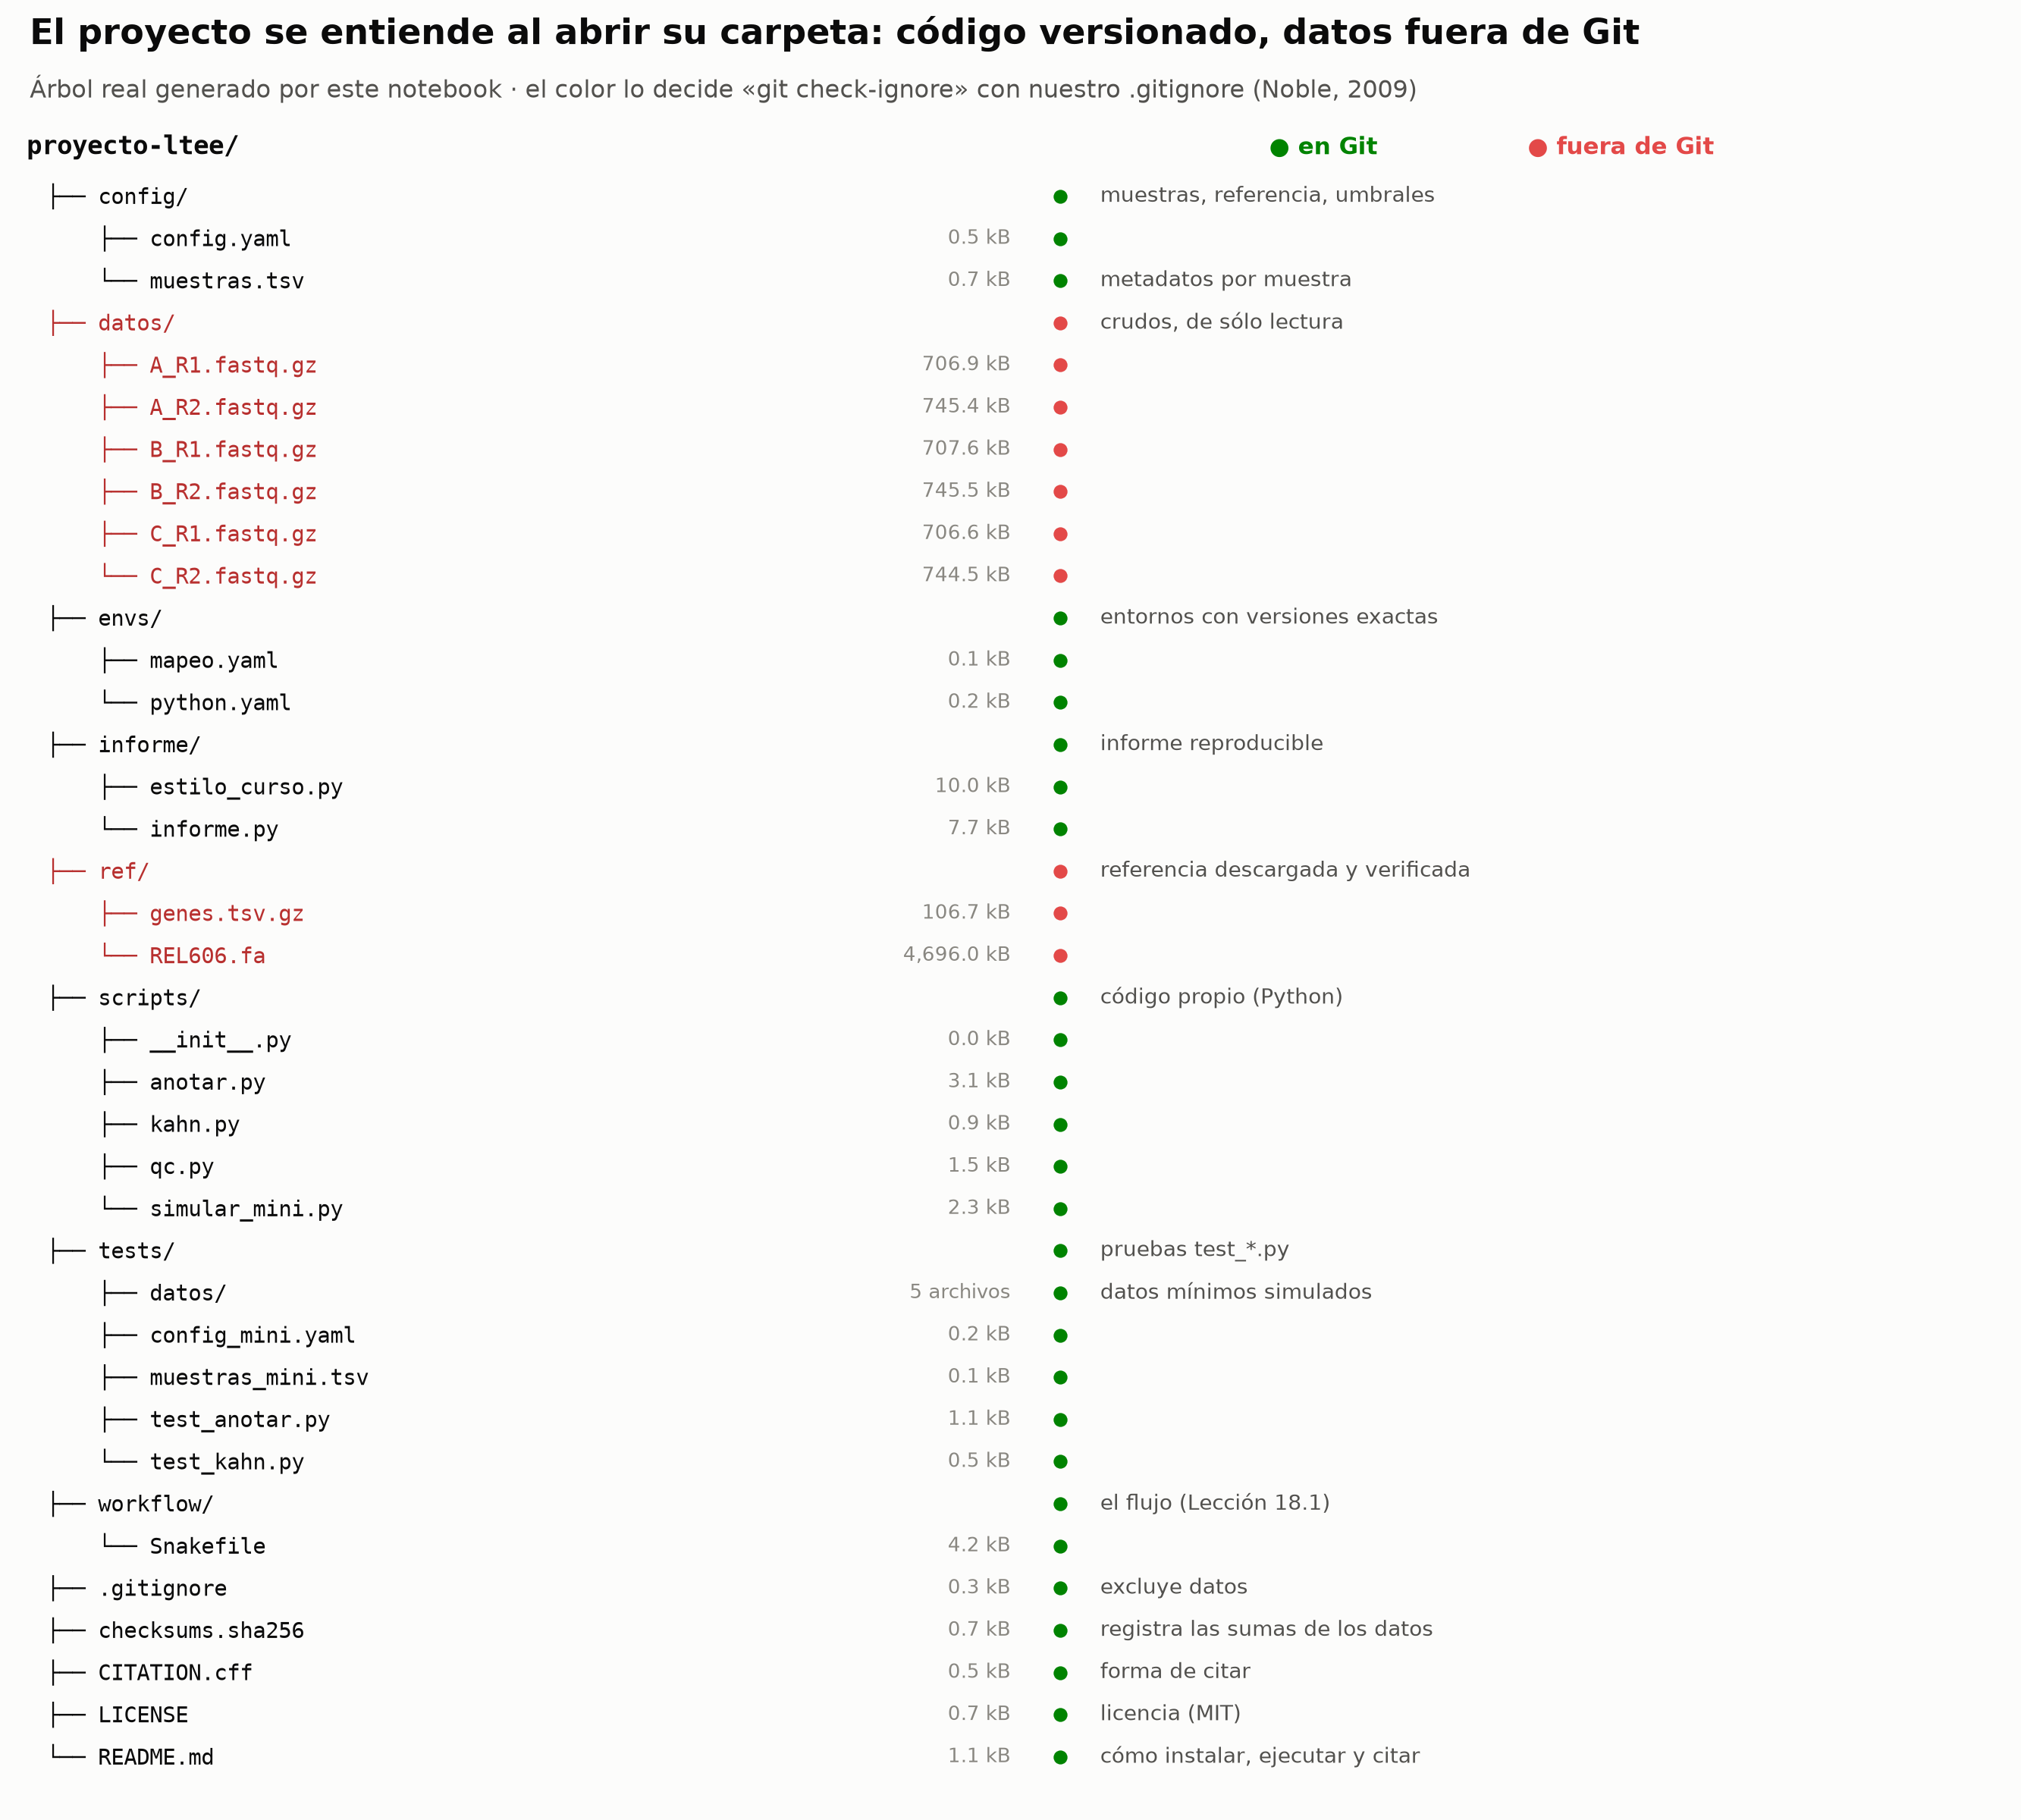

In [27]:
NOTES = {"README.md": "cómo instalar, ejecutar y citar", "LICENSE": "licencia (MIT)", "CITATION.cff": "forma de citar",
         "workflow": "el flujo (Lección 18.1)", "config": "muestras, referencia, umbrales",
         "config/muestras.tsv": "metadatos por muestra", "envs": "entornos con versiones exactas",
         "scripts": "código propio (Python)", "tests": "pruebas test_*.py", "tests/datos": "datos mínimos simulados",
         "informe": "informe reproducible", "datos": "crudos, de sólo lectura", "ref": "referencia descargada y verificada",
         ".gitignore": "excluye datos", "checksums.sha256": "registra las sumas de los datos"}

def ignored(rel):
    if HAS_GIT:
        return subprocess.run(["git", "check-ignore", "-q", rel], cwd=PROJ).returncode == 0
    return rel.split("/")[0] in ("datos", "ref", "resultados", "logs")

def tree_lines(root, rel="", depth=0, max_depth=2):
    items = sorted(e for e in os.listdir(os.path.join(root, rel)) if e not in (".git", "__pycache__", ".snakemake"))
    items.sort(key=lambda e: (not os.path.isdir(os.path.join(root, rel, e)), e.lower()))
    out = []
    for k, e in enumerate(items):
        path = os.path.join(rel, e) if rel else e
        full = os.path.join(root, path)
        is_dir = os.path.isdir(full)
        last = k == len(items) - 1
        size = "" if is_dir else f"{os.path.getsize(full) / 1e3:,.1f} kB"
        if is_dir and depth + 1 >= max_depth:
            n = sum(len(fs) for _, _, fs in os.walk(full))
            size = f"{n} archivos"
        out.append((depth, last, e + ("/" if is_dir else ""), size, ignored(path), NOTES.get(path, "")))
        if is_dir and depth + 1 < max_depth:
            out += tree_lines(root, path, depth + 1, max_depth)
    return out

def draw_tree(fig, ax, lines, title_main, title_sub):
    ax.set_xlim(0, 10); ax.set_ylim(len(lines) + 0.5, -1.2)
    ax.axis("off")
    ax.text(0.05, -0.6, "proyecto-ltee/", family="monospace", fontsize=11, fontweight="bold")
    for y, (depth, last, name, size, ign, note) in enumerate(lines):
        col = ec.RED if ign else ec.GREEN
        prefix = "    " * depth + ("└── " if last else "├── ")
        ax.text(0.15, y + 0.4, prefix + name, family="monospace", fontsize=9.5, va="center",
                color=ec.INK if not ign else "#b8302f")
        ax.text(5.0, y + 0.4, size, fontsize=8.5, va="center", ha="right", color=ec.MUTED)
        ax.scatter(5.25, y + 0.4, s=36, color=col)
        if note:
            ax.text(5.45, y + 0.4, note, fontsize=9, va="center", color=ec.INK_2)
    ax.text(6.3, -0.6, "● en Git", color=ec.GREEN, fontsize=10, fontweight="bold")
    ax.text(7.6, -0.6, "● fuera de Git", color=ec.RED, fontsize=10, fontweight="bold")
    ec.fig_title(fig, title_main, title_sub)

TREE = tree_lines(PROJ)
fig, ax = plt.subplots(figsize=(12, 0.24 * len(TREE) + 1.0))
draw_tree(fig, ax, TREE, "El proyecto se entiende al abrir su carpeta: código versionado, datos fuera de Git",
          "Árbol real generado por este notebook · el color lo decide «git check-ignore» con nuestro .gitignore (Noble, 2009)")
plt.show()

> 🔎 **Qué observamos.** Lo verde es texto ligero que cambia con el código (flujo, configuración, entornos, *scripts*,
> pruebas, documentación) y sí va en Git; lo rojo (`datos/`, `ref/`) son los datos pesados que se descargan por su
> accesión y se verifican con `checksums.sha256`. `tests/datos/` es verde: los datos **diminutos** de las pruebas sí se
> versionan, porque sin ellos nadie podría ejecutar las pruebas en un clon limpio. Cuando el flujo corra aparecerán
> `resultados/`, `logs/`, `mapeo/`…, todos rojos.

## 4. Las capas de la reproducibilidad

Conviene precisar el vocabulario. Llamaremos **reproducible** a un análisis que, con los mismos datos y el mismo código,
produce los mismos resultados; **replicable**, a un hallazgo que se sostiene cuando se repite el experimento con datos
nuevos. La reproducibilidad es el requisito **mínimo**: si ni siquiera el propio análisis puede repetirse, no hay forma de
saber si un resultado sorprendente es biología o un error. Peng (2011) la describió como un espectro que va desde la
publicación sin nada más hasta el estándar de oro de código y datos enlazados y ejecutables.

Formalmente, el resultado $R$ de un análisis es una función de **todo** lo que lo determina:

$$
R = f\big(\,\underbrace{C}_{\text{código}},\;\underbrace{\mathcal{E}}_{\text{entorno}},\;\underbrace{D}_{\text{datos}},\;
\underbrace{\theta}_{\text{parámetros}},\;\underbrace{\omega}_{\text{semilla}}\,\big).
$$

| Símbolo | Significado | Cómo se fija | En nuestro proyecto |
|---|---|---|---|
| $C$ | código propio y del flujo | identificador de un *commit* de Git | `workflow/`, `scripts/`, `informe/` + `git tag v1.0` |
| $\mathcal{E}$ | entorno de *software* (paquetes, bibliotecas, sistema) | entornos bloqueados o contenedores con *digest* | `envs/*.yaml` + versiones registradas en `procedencia.json` |
| $D$ | datos de entrada | accesiones públicas y sumas de verificación | SRR2584863, NC_012967.1 + `checksums.sha256` |
| $\theta$ | parámetros y umbrales | archivo de configuración versionado | `config/config.yaml` |
| $\omega$ | estado inicial de los generadores aleatorios | semilla en la configuración | `semilla: 2026` (datos simulados de las pruebas) |

La ecuación es trivial de escribir y exigente de cumplir: **cada** argumento que no se fije es una fuente de discrepancia.
La figura muestra las capas y la herramienta que fija cada una (adaptada de Grüning *et al.*, 2018).

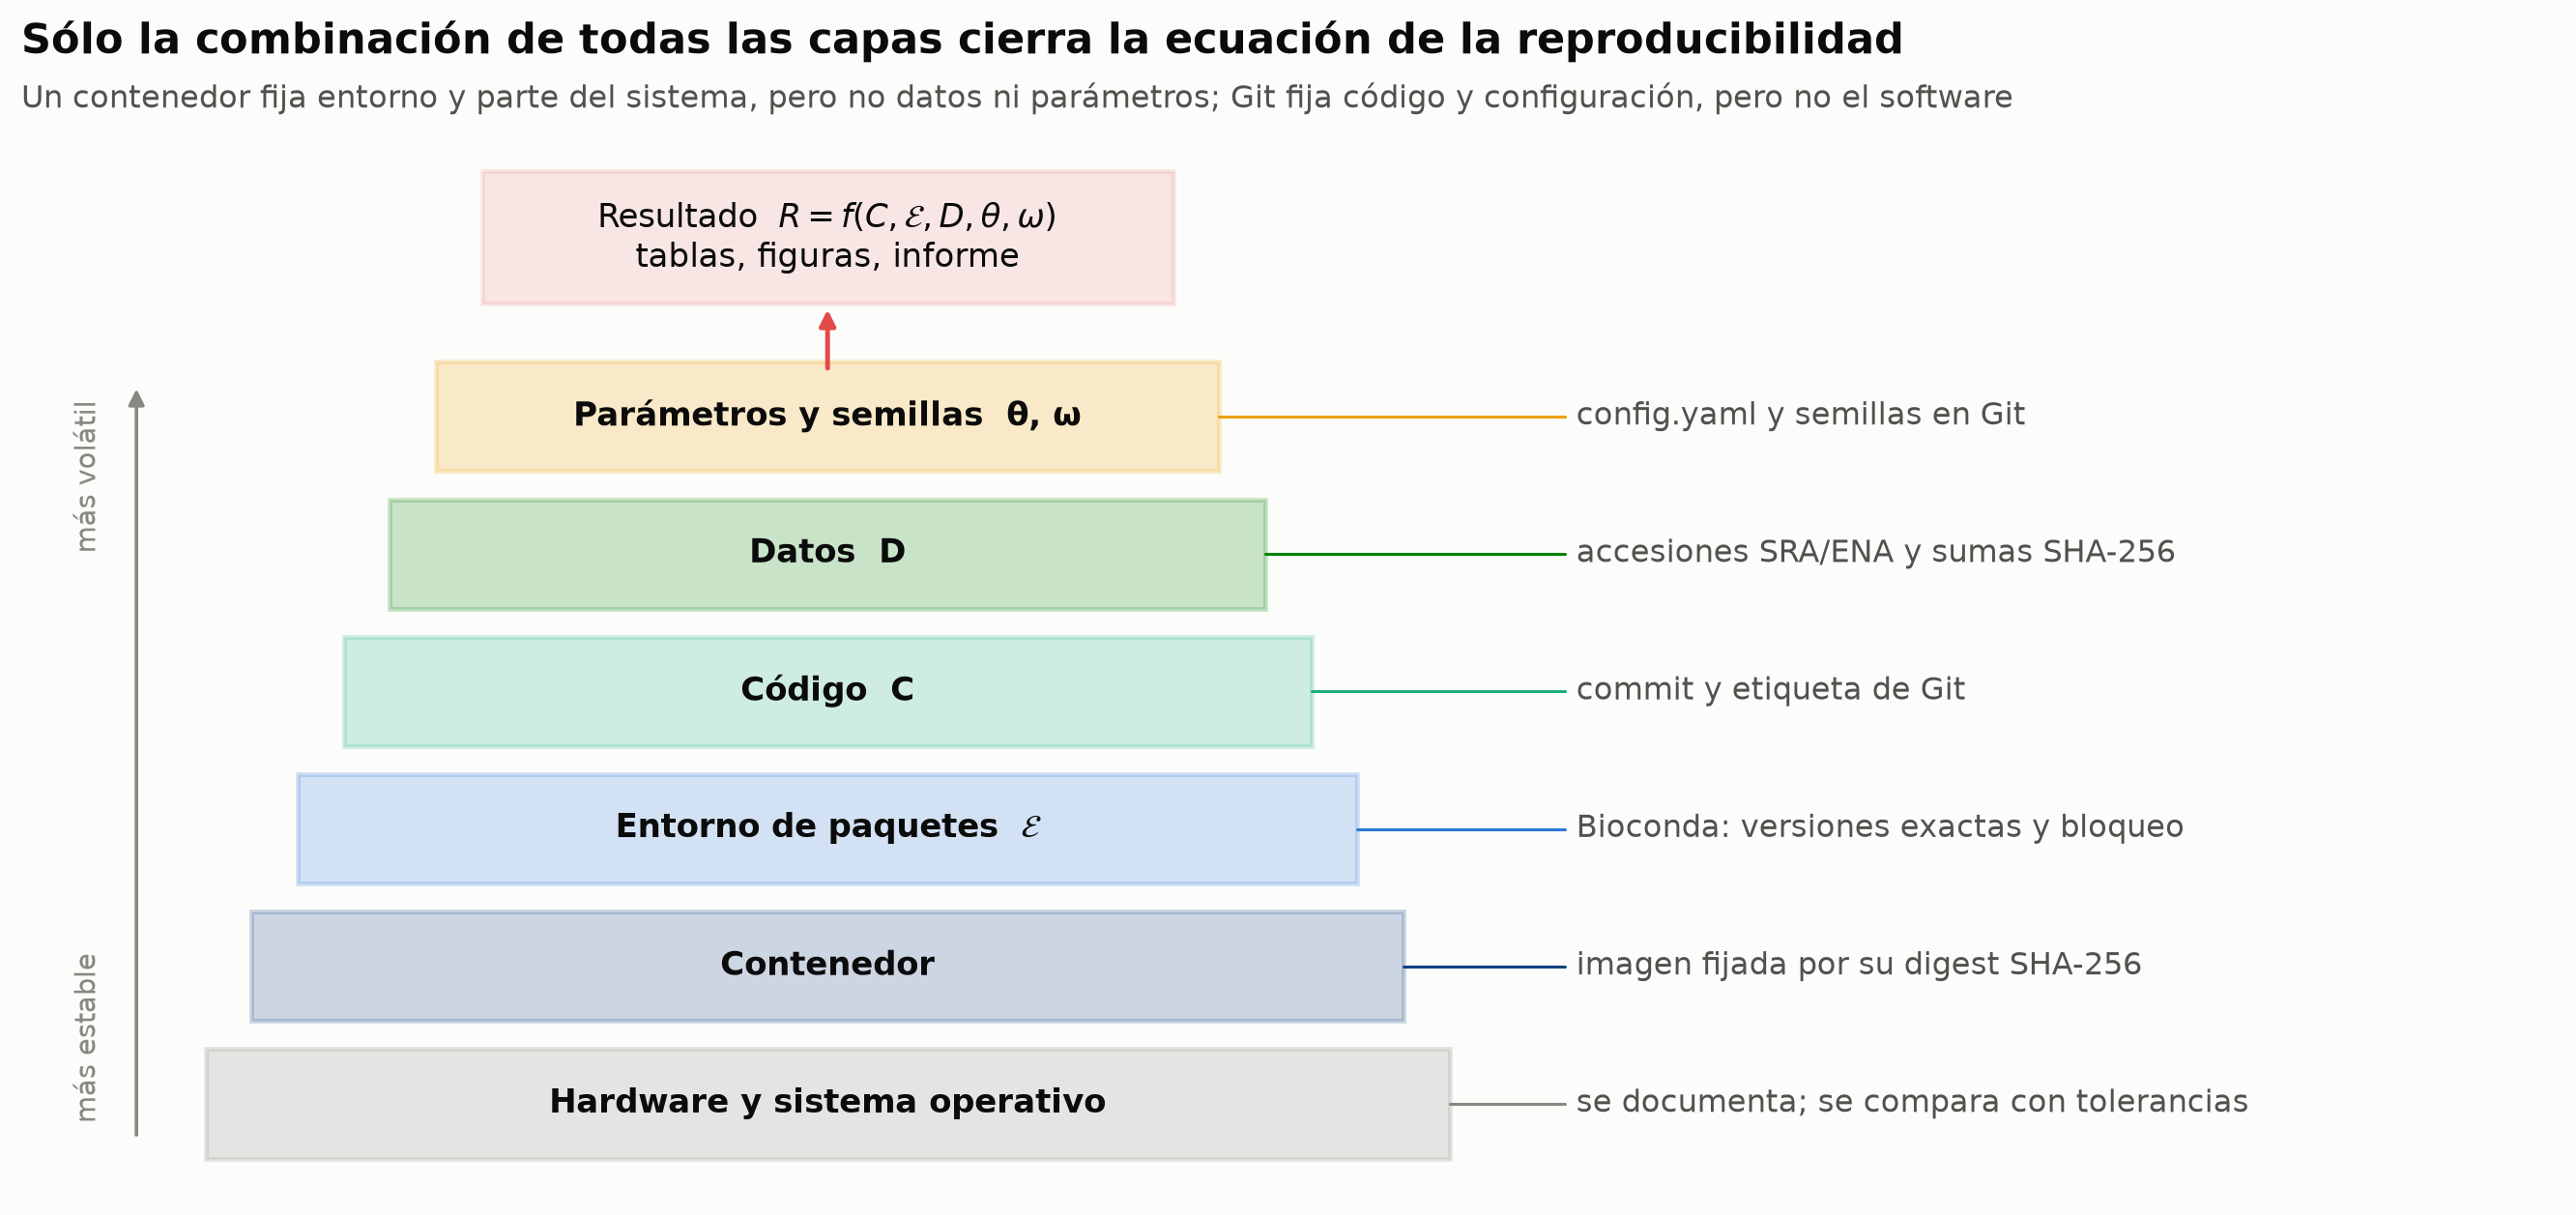

In [28]:
layers = [("Hardware y sistema operativo", "se documenta; se compara con tolerancias", "#898781"),
          ("Contenedor", "imagen fijada por su digest SHA-256", "#104281"),
          (r"Entorno de paquetes  $\mathcal{E}$", "Bioconda: versiones exactas y bloqueo", ec.BLUE),
          ("Código  C", "commit y etiqueta de Git", ec.AQUA),
          ("Datos  D", "accesiones SRA/ENA y sumas SHA-256", ec.GREEN),
          ("Parámetros y semillas  θ, ω", "config.yaml y semillas en Git", ec.YELLOW)]
fig, ax = plt.subplots(figsize=(12, 5.6))
for i, (name, how, col) in enumerate(layers):
    x0, x1 = 0.2 * i, 5.4 - 0.2 * i
    ax.add_patch(plt.Rectangle((x0, 0.78 * i), x1 - x0, 0.62, facecolor=col, alpha=0.2, edgecolor=col, lw=1.6))
    ax.text(2.7, 0.78 * i + 0.31, name, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.plot([x1, 5.9], [0.78 * i + 0.31] * 2, color=col, lw=1)
    ax.text(5.95, 0.78 * i + 0.31, how, va="center", fontsize=10.5, color=ec.INK_2)
ax.add_patch(plt.Rectangle((1.2, 4.85), 3.0, 0.75, facecolor=ec.RED, alpha=0.12, edgecolor=ec.RED, lw=1.6))
ax.text(2.7, 5.22, "Resultado  $R = f(C, \\mathcal{E}, D, \\theta, \\omega)$\ntablas, figuras, informe", ha="center", va="center", fontsize=11)
ax.annotate("", (2.7, 4.85), (2.7, 4.45), arrowprops=dict(arrowstyle="-|>", color=ec.RED, lw=1.6))
ax.annotate("", (-0.3, 4.4), (-0.3, 0.1), arrowprops=dict(arrowstyle="-|>", color=ec.MUTED, lw=1.2))
ax.text(-0.45, 0.2, "más estable", rotation=90, va="bottom", ha="right", fontsize=9.5, color=ec.MUTED)
ax.text(-0.45, 4.3, "más volátil", rotation=90, va="top", ha="right", fontsize=9.5, color=ec.MUTED)
ax.set_xlim(-0.8, 10.2); ax.set_ylim(-0.2, 5.8); ax.axis("off")
ec.title(ax, "Sólo la combinación de todas las capas cierra la ecuación de la reproducibilidad",
         "Un contenedor fija entorno y parte del sistema, pero no datos ni parámetros; Git fija código y configuración, pero no el software")
plt.show()

> 🔎 **Qué observamos.** Las capas inferiores cambian con menos frecuencia pero son las más difíciles de reconstruir años
> después (¿qué versión de `samtools` usó en 2019?); las superiores cambian en cada análisis y son las más fáciles de
> olvidar (¿con qué umbral filtró?).

### La fuente residual: la coma flotante

Hay una fuente de discrepancia que ninguna herramienta elimina del todo: la aritmética de **coma flotante no es asociativa**.
Es como pesar harina en una balanza que redondea al gramo: el total depende del orden en que se añaden las cucharadas.

> 🤔 **Antes de ejecutar, prediga.** ¿Da lo mismo `(0.1 + 0.2) + 0.3` que `0.1 + (0.2 + 0.3)`? ¿Y sumar un millón de
> números en otro orden?

In [29]:
print("(0.1 + 0.2) + 0.3 =", (0.1 + 0.2) + 0.3)
print("0.1 + (0.2 + 0.3) =", 0.1 + (0.2 + 0.3))
rng = np.random.default_rng(2026)
x = rng.lognormal(0, 3, 1_000_000)                  # magnitudes muy dispares, como coberturas o expresiones
s_sorted, s_rev, s_shuf = sum(sorted(x)), sum(sorted(x, reverse=True)), sum(rng.permutation(x))
print(f"\nsuma ascendente  = {s_sorted!r}\nsuma descendente = {s_rev!r}\nsuma barajada    = {s_shuf!r}")
print(f"diferencia relativa máx. = {(max(s_sorted, s_rev, s_shuf) - min(s_sorted, s_rev, s_shuf)) / s_sorted:.1e}")
print("¿iguales bit a bit?", s_sorted == s_rev, "· ¿iguales con tolerancia (np.isclose)?", np.isclose(s_sorted, s_rev))

(0.1 + 0.2) + 0.3 = 0.6000000000000001
0.1 + (0.2 + 0.3) = 0.6



suma ascendente  = np.float64(86574217.70295106)
suma descendente = np.float64(86574217.70294952)
suma barajada    = np.float64(86574217.70295173)
diferencia relativa máx. = 2.5e-14
¿iguales bit a bit? False · ¿iguales con tolerancia (np.isclose)? True


> 🔎 **Qué observamos.** `0.6000000000000001` frente a `0.6`, y sumas de un millón de valores que difieren en el último
> decimal según el orden. Un programa que suma en paralelo en un orden que depende de qué hilo termina antes puede producir
> resultados distintos entre ejecuciones. Lo sensato: **documentarlo y comparar resultados con tolerancias**, no bit a bit.
> Por eso nuestro informe hashea **tablas de texto** (con números redondeados) y no los BAM, cuyas cabeceras incluyen
> además la línea de órdenes y la versión del programa.

### Sumas de verificación: ¿cuánto podemos confiar en una huella?

La capa de datos se fija con sumas de verificación: el flujo descarga las lecturas por su accesión y comprueba que su
huella SHA-256 coincide con la registrada. Primero, veamos que funcionan: copiamos un archivo de lecturas, cambiamos **un
solo byte** y verificamos la lista como lo haría `sha256sum -c`.

In [30]:
def verify(checksum_file, root):
    """Equivalente en Python de 'sha256sum -c': devuelve {ruta: 'OK' | 'FAILED' | 'FALTA'}."""
    res = {}
    for line in open(checksum_file):
        digest, path = line.rstrip("\n").split("  ", 1)
        full = os.path.join(root, path)
        res[path] = "FALTA" if not os.path.exists(full) else ("OK" if sha256(full) == digest else "FAILED")
    return res

n_ok = sum(v == "OK" for v in verify(f"{PROJ}/checksums.sha256", PROJ).values())
print(f"verificación del proyecto: {n_ok} de {len(RAW_INPUTS)} archivos OK")

# una copia corrupta: un byte cambiado en medio de datos/A_R1.fastq.gz
bad_root = os.path.join(TMP, "proyecto-ltee-corrupto")
shutil.rmtree(bad_root, ignore_errors=True)
shutil.copytree(PROJ, bad_root, ignore=shutil.ignore_patterns(".git"))
raw = bytearray(open(f"{bad_root}/datos/A_R1.fastq.gz", "rb").read())
raw[len(raw) // 2] ^= 0x01                          # invertimos un solo bit
open(f"{bad_root}/datos/A_R1.fastq.gz", "wb").write(raw)
res = verify(f"{bad_root}/checksums.sha256", bad_root)
for p, v in res.items():
    print(f"  {p:24s} {v}")
h_ok, h_bad = sha256(f"{PROJ}/datos/A_R1.fastq.gz"), sha256(f"{bad_root}/datos/A_R1.fastq.gz")
print(f"\nhuella original: {h_ok}\nhuella corrupta: {h_bad}")
print(f"dígitos hexadecimales distintos: {sum(a != b for a, b in zip(h_ok, h_bad))} de 64 (efecto avalancha)")
shutil.rmtree(bad_root, ignore_errors=True)

verificación del proyecto: 8 de 8 archivos OK
  datos/A_R1.fastq.gz      FAILED
  datos/A_R2.fastq.gz      OK
  datos/B_R1.fastq.gz      OK
  datos/B_R2.fastq.gz      OK
  datos/C_R1.fastq.gz      OK
  datos/C_R2.fastq.gz      OK
  ref/REL606.fa            OK
  ref/genes.tsv.gz         OK

huella original: d32de76fe99ae8407b8d7dc785358d4f21c50046ba8564a7229cd47e631f8ca8
huella corrupta: 801510cfc840a2bd8c070eb35a15a7385f8fc0a213150c53bc57f2d175728593
dígitos hexadecimales distintos: 59 de 64 (efecto avalancha)


> 🔎 **Qué observamos.** Un solo bit cambiado en 700 kB basta para que la verificación diga `FAILED`, y la huella nueva no
> se parece en nada a la original (unos 60 de 64 dígitos distintos: el **efecto avalancha**). El SRA y el ENA publican el
> MD5 de cada archivo; para nuestra corrida, el ENA declara `4a1529a4…` para `SRR2584863_1.fastq.gz` (183 MB). Un flujo
> que descargue el archivo completo debería comprobar esa huella antes de mapear una sola lectura.

¿Qué tan seguras son? Si una función *hash* de $b$ bits se comporta como una asignación aleatoria uniforme, la probabilidad
de que entre $n$ archivos distintos haya **dos con la misma huella** es, por el argumento del cumpleaños (el mismo que
dice que en un aula de 23 personas es más probable que no que dos cumplan años el mismo día),

$$
P(\text{colisión}) = 1 - \prod_{i=1}^{n-1}\left(1-\frac{i}{2^b}\right) \;\approx\; 1 - \exp\!\left(-\frac{n(n-1)}{2^{b+1}}\right).
$$

| Símbolo | Significado |
|---|---|
| $b$ | longitud de la huella en bits (32 para CRC32, 128 para MD5, 256 para SHA-256) |
| $n$ | número de archivos distintos comparados |

La aproximación se obtiene tomando logaritmos, usando $\ln(1-x)\approx -x$ para $x$ pequeño y sumando
$\sum_{i=1}^{n-1} i = n(n-1)/2$. **A mano, para el cumpleaños:** con $2^b=365$ días y $n=23$,
$1-\exp(-23\cdot22/730) = 1-e^{-0{,}693} \approx 0{,}50$.

In [31]:
def p_collision(n, b):
    """Aproximación del cumpleaños; -expm1 conserva la precisión cuando la probabilidad es diminuta."""
    return -np.expm1(-n * (n - 1) / 2 ** (b + 1))

tab = pd.DataFrame({f"n = {n:.0e}": [p_collision(n, b) for b in (32, 128, 256)] for n in (1e5, 1e6, 1e9)},
                   index=["CRC32 (b = 32)", "MD5 (b = 128)", "SHA-256 (b = 256)"])
display(tab.map(lambda v: f"{v:.3g}"))

,n = 1e+05,n = 1e+06,n = 1e+09
CRC32 (b = 32),0.688,1,1
MD5 (b = 128),1.47e-29,1.47e-27,1.47e-21
SHA-256 (b = 256),4.32e-68,4.32e-66,4.32e-60


> 🔎 **Qué observamos.** Las cifras del libro: con una suma de 32 bits y $n=10^5$ archivos la probabilidad de colisión ya es
> **0,69**: las sumas cortas sirven para detectar errores de transmisión, no para identificar contenidos. Con MD5 y mil
> millones de archivos, $1{,}5\times10^{-21}$; con SHA-256, $4\times10^{-60}$. MD5 sigue siendo útil contra la corrupción
> accidental, pero hoy se pueden **fabricar** colisiones deliberadas; para garantías frente a manipulaciones se prefiere
> SHA-256.

¿Es creíble la fórmula? Pongámosla a prueba con huellas **reales**: truncamos SHA-256 a $b=16$ bits (65 536 valores
posibles) y contamos cuántas veces aparecen colisiones entre $n$ «archivos» distintos.

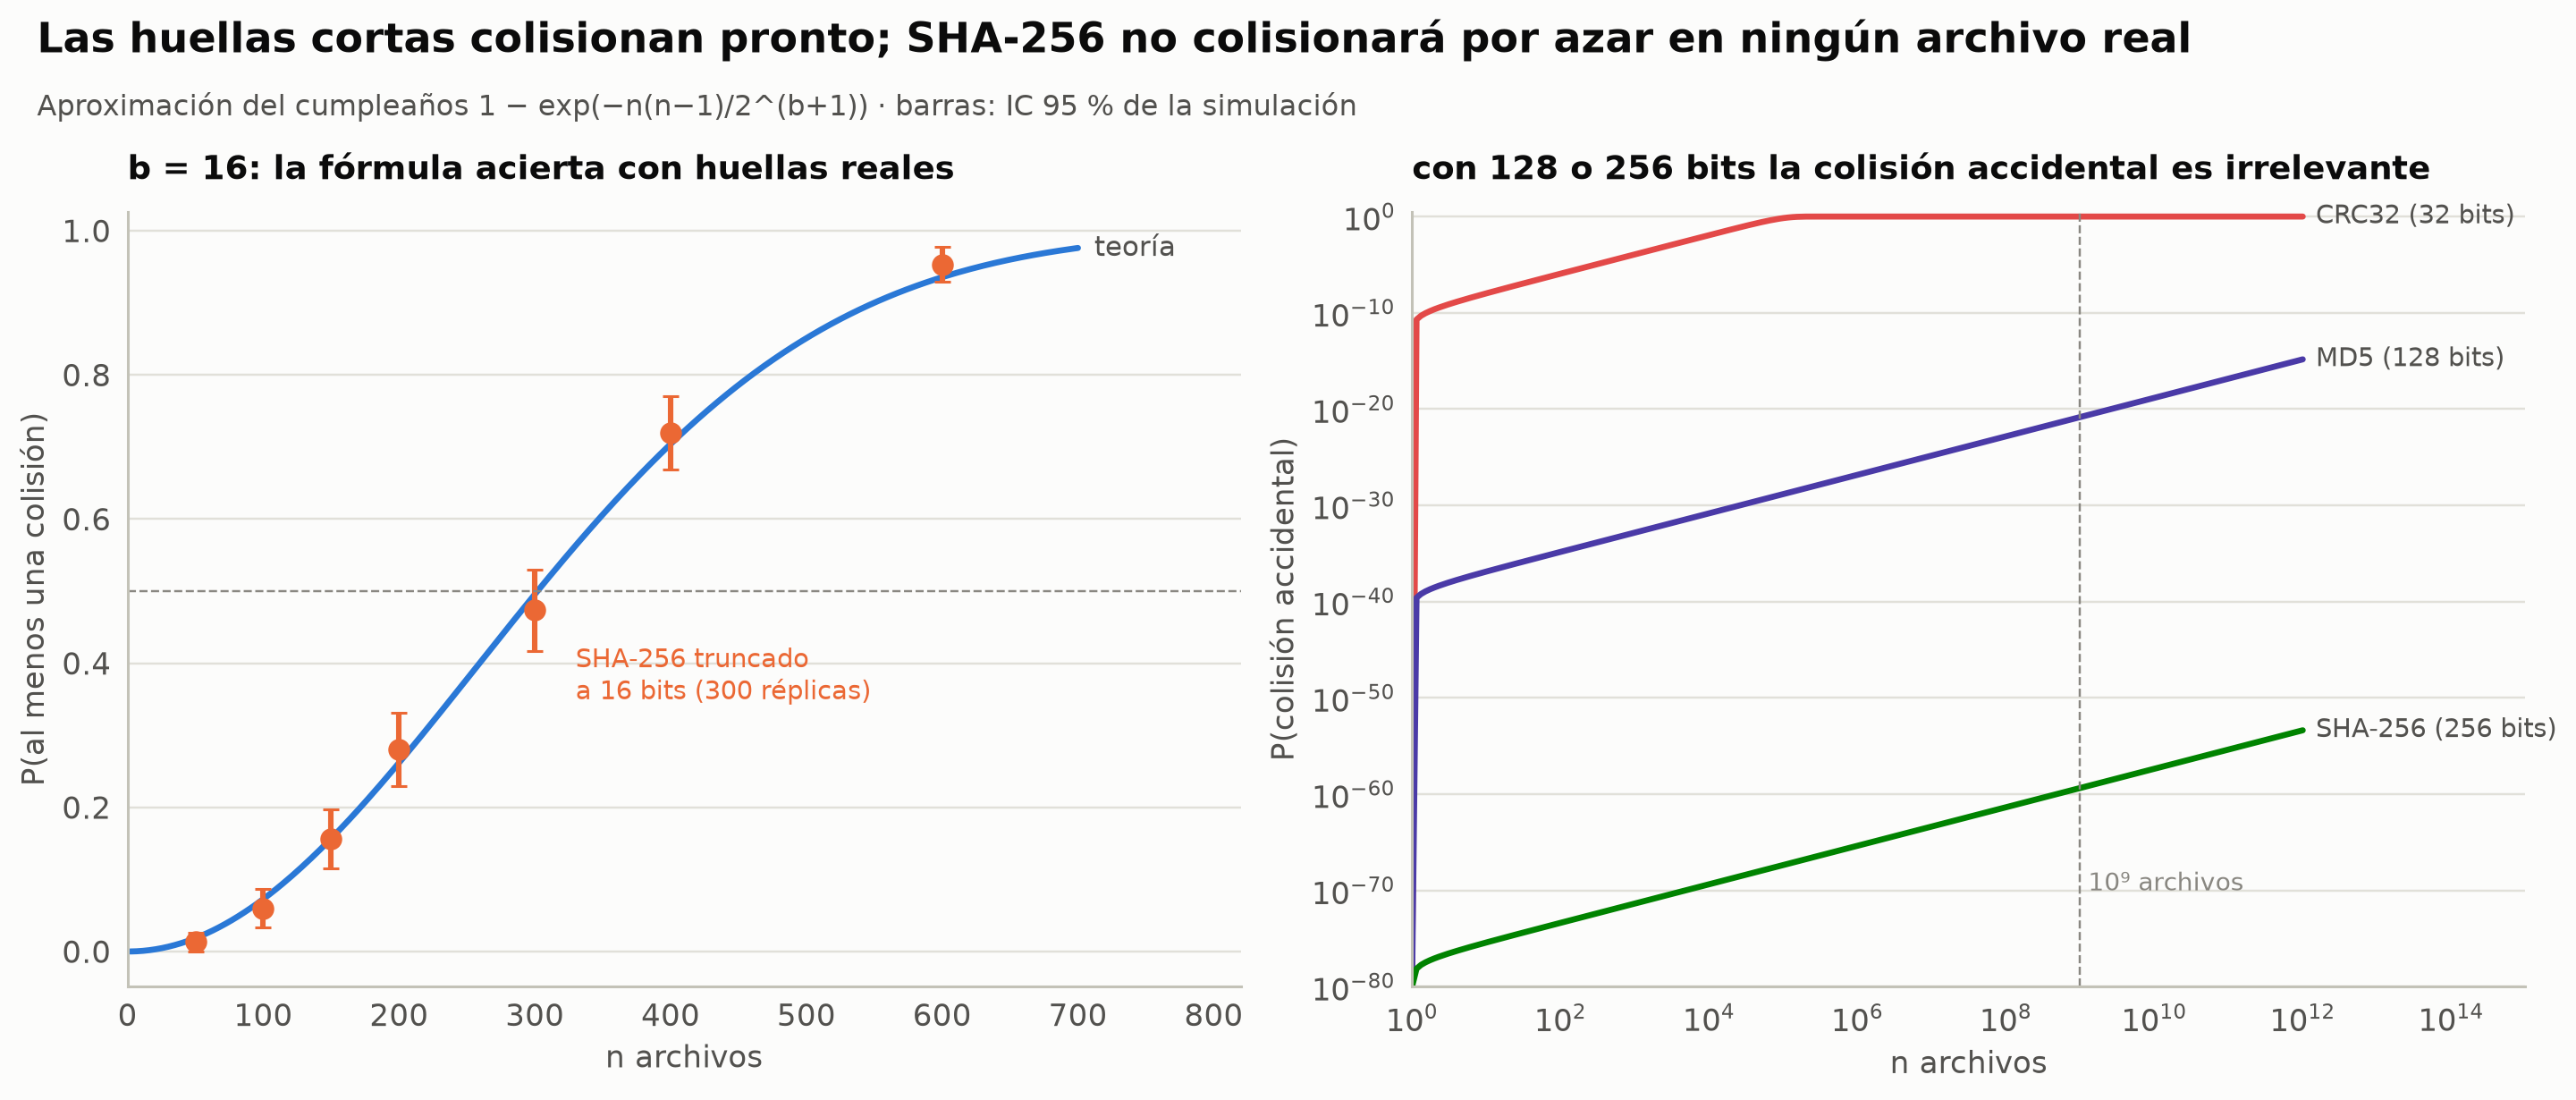

In [32]:
b_small, reps = 16, 300
ns_mc = [50, 100, 150, 200, 300, 400, 600]
emp = []
for n in ns_mc:
    hits = 0
    for r in range(reps):
        seen = set()
        for j in range(n):
            h = int(hashlib.sha256(f"archivo-{n}-{r}-{j}".encode()).hexdigest()[:4], 16)   # 16 bits
            if h in seen:
                hits += 1
                break
            seen.add(h)
    emp.append(hits / reps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
nn = np.linspace(2, 700, 300)
ax1.plot(nn, p_collision(nn, b_small), color=ec.BLUE, lw=2.2)
ax1.errorbar(ns_mc, emp, yerr=[1.96 * np.sqrt(p * (1 - p) / reps) for p in emp], fmt="o", color=ec.ORANGE, capsize=3)
ec.label_end(ax1, 700, p_collision(700, b_small), "teoría")
ax1.text(330, 0.35, "SHA-256 truncado\na 16 bits (300 réplicas)", color=ec.ORANGE, fontsize=9.5)
ax1.axhline(0.5, color=ec.MUTED, lw=0.8, ls="--")
ax1.set_xlabel("n archivos"); ax1.set_ylabel("P(al menos una colisión)")
ax1.set_xlim(0, 820)
ax1.set_title("b = 16: la fórmula acierta con huellas reales", loc="left", fontsize=12)
nlog = np.logspace(0, 12, 200)
for b, col, lab in [(32, ec.RED, "CRC32 (32 bits)"), (128, ec.VIOLET, "MD5 (128 bits)"), (256, ec.GREEN, "SHA-256 (256 bits)")]:
    y = np.maximum(p_collision(nlog, b), 1e-80)
    ax2.loglog(nlog, y, color=col, lw=2.2)
    ax2.text(1.5e12, y[-1], lab, color=ec.INK_2, fontsize=9.5, va="center")
ax2.axvline(1e9, color=ec.MUTED, lw=0.8, ls="--")
ax2.text(1e9, 1e-70, " 10⁹ archivos", color=ec.MUTED, fontsize=9)
ax2.set_ylim(1e-80, 3); ax2.set_xlim(1, 1e15)
ax2.set_xlabel("n archivos"); ax2.set_ylabel("P(colisión accidental)")
ax2.set_title("con 128 o 256 bits la colisión accidental es irrelevante", loc="left", fontsize=12)
ec.fig_title(fig, "Las huellas cortas colisionan pronto; SHA-256 no colisionará por azar en ningún archivo real",
             "Aproximación del cumpleaños 1 − exp(−n(n−1)/2^(b+1)) · barras: IC 95 % de la simulación")
plt.show()

> 🔎 **Qué observamos.** Con 16 bits basta con ~300 archivos para que la colisión sea más probable que no ($\approx
> \sqrt{2\ln2\cdot2^{16}}\approx301$), y la simulación con huellas reales cae sobre la curva teórica. Con 256 bits, ni
> todos los archivos que la humanidad ha escrito se acercarían a una colisión accidental.

> ✅ **Compruebe su comprensión.** ¿Por qué `checksums.sha256` **sí** va en Git aunque los datos no? *(Respuesta: porque es
> texto ligero que fija la capa $D$: quien clone el repositorio descargará los datos por su accesión y podrá comprobar que
> son exactamente los mismos bytes que usted analizó.)*

## 5. Control de versiones y pruebas

El código del proyecto vive en un repositorio Git desde el primer día (Lección 0.3). Las reglas de Perez-Riverol *et al.*
(2016) resumen los hábitos que más rinden: ***commits* pequeños** con mensajes que expliquen el **porqué**, ramas para cada
cambio sustancial, **etiquetas** (`v1.0`) para las versiones que producen resultados reportados y un repositorio público
enlazado desde la publicación. Los datos y resultados no van en Git, pero sí la lista de sus accesiones y sumas.

Primero, las herramientas. En Colab se instalan `snakemake` y `pytest` con `pip` y `bwa`, `samtools` y `bcftools` con
`apt-get`. Las reglas llaman a `python`, que en Colab ya es el intérprete de este cuaderno. Sólo fuera de Colab, si
`snakemake` se instaló en otro entorno, la celda añade al `PATH` un enlace `python` hacia este intérprete (con `pandas` y
`matplotlib`); es un detalle de instalación local, no parte del proyecto.

In [33]:
try:
    import pytest  # noqa: F401
except ImportError:
    %pip install -q pytest
if not shutil.which("snakemake"):
    %pip install -q snakemake
if IN_COLAB and not all(shutil.which(t) for t in ("bwa", "samtools", "bcftools")):
    !apt-get -qq update > /dev/null
    !apt-get -qq install -y bwa samtools bcftools > /dev/null
if not IN_COLAB:   # sólo en ejecuciones locales: 'python' dentro de las reglas = el intérprete de este cuaderno
    SHIM = os.path.join(tempfile.gettempdir(), "bin-curso-182")
    os.makedirs(SHIM, exist_ok=True)
    if os.path.lexists(f"{SHIM}/python"):          # reemplazamos siempre el enlace (podría apuntar a otro entorno)
        os.remove(f"{SHIM}/python")
    os.symlink(sys.executable, f"{SHIM}/python")
    if SHIM not in os.environ["PATH"].split(os.pathsep):
        os.environ["PATH"] = SHIM + os.pathsep + os.environ["PATH"]

def first_line(cmd):
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    txt = (p.stdout + p.stderr).strip().splitlines()
    return next((l.strip() for l in txt if re.search(r"\d+\.\d+", l)), "no encontrado")

VERSIONS = {"snakemake": first_line("snakemake --version"), "bwa": first_line("bwa 2>&1 | grep -i version"),
            "samtools": first_line("samtools --version | head -1"), "bcftools": first_line("bcftools --version | head -1"),
            "pytest": first_line(f"{sys.executable} -m pytest --version"), "git": first_line("git --version")}
for k, v in VERSIONS.items():
    print(f"{k:9s} {v}")
HAS_TOOLS = all(shutil.which(t) for t in ("snakemake", "bwa", "samtools", "bcftools"))
print("\n¿herramientas completas?", HAS_TOOLS, "" if HAS_TOOLS else "→ se usarán los resultados precalculados del curso")

snakemake 9.27.0
bwa       Version: 0.7.19-r1273
samtools  samtools 1.24
bcftools  bcftools 1.24
pytest    pytest 9.1.1
git       git version 2.50.1 (Apple Git-155)

¿herramientas completas? True 


El primer *commit*: el esqueleto. Observe qué entra (el `git status` corto) y qué no.

In [34]:
def git(args, quiet=True):
    return sh(f"git {args}", cwd=PROJ, quiet=quiet)[0].strip() if HAS_GIT else "(sin git)"

if HAS_GIT:
    git("add -A")
    print(git("status --short"))
    git("commit -q -m 'Esqueleto del proyecto: flujo, configuración, entornos, pruebas e informe'")
    print("\n" + git("log --oneline"))
    print("archivos versionados:", len(git("ls-files").splitlines()), "· tamaño del repositorio:",
          f"{sum(os.path.getsize(os.path.join(PROJ, f)) for f in git('ls-files').splitlines()) / 1e3:.0f} kB")
    dir_mb = lambda d: sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(f"{PROJ}/{d}") for f in fs) / 1e6
    print(f"fuera de Git: datos/ {dir_mb('datos'):.2f} MB · ref/ {dir_mb('ref'):.2f} MB")

A  .gitignore
A  CITATION.cff
A  LICENSE
A  README.md
A  checksums.sha256
A  config/config.yaml
A  config/muestras.tsv
A  envs/mapeo.yaml
A  envs/python.yaml
A  informe/estilo_curso.py
A  informe/informe.py
A  scripts/__init__.py
A  scripts/anotar.py
A  scripts/kahn.py
A  scripts/qc.py
A  scripts/simular_mini.py
A  tests/config_mini.yaml
A  tests/datos/genes_mini.tsv.gz
A  tests/datos/mini_R1.fastq.gz
A  tests/datos/mini_R2.fastq.gz
A  tests/datos/ref_mini.fa
A  tests/datos/verdad.json
A  tests/muestras_mini.tsv
A  tests/test_anotar.py
A  tests/test_kahn.py
A  workflow/Snakefile

11a5869 Esqueleto del proyecto: flujo, configuración, entornos, pruebas e informe
archivos versionados: 26 · tamaño del repositorio: 139 kB
fuera de Git: datos/ 4.36 MB · ref/ 4.80 MB


> 🔎 **Qué observamos.** Entraron los archivos de texto y los datos diminutos de las pruebas: unos 140 kB. Los
> 4,4 MB de lecturas de `datos/` y los 4,8 MB de `ref/` (la referencia de 4,6 MB y su anotación) se quedaron fuera, como
> indica el `.gitignore`.

### Tres niveles de pruebas

Las **pruebas** son la parte más descuidada de los análisis académicos, y la que más ahorra. Distinguimos tres niveles:

1. **Pruebas unitarias** de las funciones propias (en `scripts/`), con casos pequeños cuyo resultado se conoce de antemano,
   ejecutadas con `pytest`.
2. **Pruebas de integración** del flujo completo sobre un conjunto de datos **diminuto** (unos miles de lecturas simuladas
   sobre un fragmento de la referencia), que debe correr en segundos; es la idea de los perfiles `test` de nf-core (Ewels
   *et al.*, 2020).
3. **Comprobaciones de cordura** sobre los resultados reales: la proporción de lecturas mapeadas, la razón Ti/Tv de las
   variantes (Lección 9.2), el número de genes detectados, la correlación entre réplicas.

La consola del libro, que ejecutaremos casi entera:

```bash
pytest -q tests/                                         # pruebas unitarias
snakemake --lint                                         # buenas prácticas del flujo
snakemake -n --configfile tests/config_mini.yaml         # ensayo en seco
snakemake --cores 2 --sdm conda --configfile tests/config_mini.yaml
```

> 🤔 **Antes de ejecutar, prediga.** ¿Cuántas pruebas encontrará `pytest`? ¿Alguna debería fallar?

In [35]:
def run_pytest():
    p = subprocess.run([sys.executable, "-m", "pytest", "-q", "-rf", "--color=no", "-p", "no:cacheprovider", "tests/"],
                       cwd=PROJ, capture_output=True, text=True)
    return p.returncode, p.stdout.strip()

code, out = run_pytest()
print(out)

......                                                                   [100%]
6 passed in 0.01s


> 🔎 **Qué observamos.** Seis pruebas, seis puntos, `6 passed`. Una prueba que siempre pasa no enseña nada; su valor está en
> el día en que **deja** de pasar. Simulemos un error típico: alguien «simplifica» `consecuencia` y olvida complementar la
> base alternativa en los genes de la hebra $-$.

In [36]:
src_path = f"{PROJ}/scripts/anotar.py"
original = open(src_path).read()
buggy = original.replace("gen, k, alt = revcomp(gen), e - pos, alt.translate(COMP)", "gen, k = revcomp(gen), e - pos")
assert buggy != original
open(src_path, "w").write(buggy)
code, out = run_pytest()
print("\n".join(l for l in out.splitlines() if l.startswith(("FAILED", "E ")) or "passed" in l or "failed" in l))
open(src_path, "w").write(original)           # restauramos
print("\nrestaurado →", run_pytest()[1].splitlines()[-1])

E       AssertionError: assert ('de sentido erróneo' == 'sinónima'
E         
E         - sinónima
E         + de sentido erróneo)
FAILED tests/test_anotar.py::test_hebra_menos - AssertionError: assert ('de s...
1 failed, 5 passed in 0.01s



restaurado → 6 passed in 0.01s


> 🔎 **Qué observamos.** `test_hebra_menos` falla y señala la línea exacta. Sin esa prueba, el error habría pasado
> inadvertido: el flujo seguiría corriendo y produciendo tablas **plausibles**, con la mitad de los efectos mal calculados
> (la mitad de los genes de *E. coli* están en la hebra $-$). Es el tipo de error que sólo se descubre semanas después,
> cuando un resultado no cuadra con la literatura.

Ahora el flujo: el *linter* de Snakemake revisa buenas prácticas y el ensayo en seco con la configuración mínima comprueba
que el grafo se construye.

In [37]:
def smk(args, root=None, quiet=False, check=True):
    """Ejecuta snakemake en la raíz del proyecto; devuelve (registro, segundos)."""
    out, err, secs = sh(f"snakemake {args}", cwd=root or PROJ, quiet=quiet, check=check)
    return out + err, secs

def job_stats(log):
    """Tabla 'Job stats' del registro de Snakemake: {regla: número de trabajos}."""
    m = re.search(r"Job stats:\n.*?\n-+\s+-+\n(.*?)\ntotal\s+(\d+)", log, re.S)
    return {a: int(b) for a, b in (l.split() for l in m.group(1).strip().splitlines())} if m else {}

if HAS_TOOLS:
    lint, _ = smk("--lint", check=False)
    tips = [l.strip() for l in lint.splitlines() if l.strip().startswith("* ")]
    print(f"snakemake --lint: {len(tips)} sugerencias; las primeras:\n  " + "\n  ".join(tips[:8]))
    log, _ = smk("-n --cores 2 --configfile tests/config_mini.yaml", quiet=True)
    print("\nensayo en seco con los datos mínimos:", job_stats(log))
else:
    print("(sin herramientas: se omiten --lint y el ensayo en seco)")

$ snakemake --lint


snakemake --lint: 5 sugerencias; las primeras:
  * No log directive defined:
  * No log directive defined:
  * No log directive defined:
  * No log directive defined:
  * No log directive defined:



ensayo en seco con los datos mínimos: {'bwa_index': 1, 'qc': 1, 'mapear': 1, 'dedup': 1, 'flagstat': 1, 'llamar': 1, 'filtrar': 1, 'anotar': 1, 'informe': 1, 'all': 1}


> 🔎 **Qué observamos.** El *linter* sugiere mejoras (por ejemplo, declarar un `log:` en cada regla que escribe mensajes o
> fijar la versión mínima de Snakemake): no son errores, sino buenas prácticas que conviene ir atendiendo. El ensayo en seco
> planea los trabajos de una sola muestra (`mini`) sin ejecutar nada.

### La prueba de integración, en un clon limpio

La prueba de integración debe correr **donde no está usted**: en un clon recién descargado del repositorio, sin datos
reales, sin archivos olvidados en su carpeta. Es exactamente lo que hace un servicio de integración continua (por ejemplo,
GitHub Actions) en cada *commit*. Lo simulamos con `git clone` en otra carpeta y ejecutamos el flujo con los datos
simulados; la prueba **pasa** si el flujo encuentra la SNV plantada, y sólo ésa.

In [38]:
CI = os.path.join(TMP, "proyecto-ltee-ci")
shutil.rmtree(CI, ignore_errors=True)
if HAS_TOOLS and HAS_GIT:
    sh(f"git clone -q {PROJ} {CI}")
    print("en el clon hay datos/?", os.path.exists(f"{CI}/datos"), "· ref/?", os.path.exists(f"{CI}/ref"),
          "· tests/datos/?", os.path.exists(f"{CI}/tests/datos"))
    log, secs_ci = smk("--cores 2 --configfile tests/config_mini.yaml", root=CI, quiet=True)
    found = pd.read_csv(f"{CI}/resultados/anotado.tsv", sep="\t", keep_default_na=False)
    display(found[["POS", "REF", "ALT", "QUAL", "gen", "efecto", "cambio", "codon"]])
    ok = (len(found) == 1 and found.POS[0] == TRUTH["POS"] and found.ALT[0] == TRUTH["ALT"] and found.gen[0] == "topA")
    print(f"prueba de integración en {secs_ci:.1f} s:", "✅ PASA: el flujo encuentra exactamente la SNV plantada" if ok
          else "❌ FALLA")
else:
    print("(sin herramientas o sin git: se omite la prueba de integración)")

$ git clone -q /tmp/proyecto-ltee /tmp/proyecto-ltee-ci
en el clon hay datos/? False · ref/? False · tests/datos/? True


,POS,REF,ALT,QUAL,gen,efecto,cambio,codon
0,3721,A,G,225.4,topA,de sentido erróneo,E101G,GAA>GGA


prueba de integración en 3.7 s: ✅ PASA: el flujo encuentra exactamente la SNV plantada


> 🔎 **Qué observamos.** En el clon no hay `datos/` ni `ref/` (Git no los trae), pero sí `tests/datos/`, y con eso basta:
> el flujo completo (control de calidad, índice, mapeo, duplicados, llamado, filtro, anotación e **informe**) corre en unos
> segundos y encuentra una sola SNV, en la posición plantada, en *topA*, **de sentido erróneo** (la segunda base de un
> codón). Si mañana alguien rompe una regla, esta prueba lo dirá en segundos, no semanas después.

Registramos este estado con una **etiqueta**: `v1.0` será la versión que produzca los resultados del informe.

In [39]:
if HAS_GIT:
    git("tag -a v1.0 -m 'Versión que produce los resultados del informe'")
    print(git("log --oneline --decorate"))

11a5869 (HEAD -> main, tag: v1.0) Esqueleto del proyecto: flujo, configuración, entornos, pruebas e informe


## 6. Documentación e informe reproducible: el mini-proyecto de principio a fin

La documentación mínima ya está: un `README` que responde qué, cómo instalar, cómo ejecutar y cómo citar; una licencia (sin
licencia, legalmente nadie puede reutilizar el código); un `CITATION.cff`. Para el código publicado se añade un DOI de
archivo permanente (por ejemplo, depositando la etiqueta `v1.0` en Zenodo).

El **informe** es el último eslabón del flujo, no un documento aparte. Rule *et al.* (2019) dan diez reglas para que un
cuaderno sea legible y reutilizable: contar una historia para una audiencia concreta, documentar el proceso y no sólo los
resultados, dividir el código en celdas con un propósito claro, registrar las dependencias y construir el cuaderno como
parte de un flujo. MultiQC (Ewels *et al.*, 2016) reúne en un solo informe HTML las métricas de calidad de todas las
herramientas, y Snakemake puede generar un informe con la procedencia de cada resultado (`snakemake --report`).

Ahora, **una sola orden** con los datos reales:

> 🤔 **Antes de ejecutar, prediga.** ¿Cuántos trabajos ejecutará Snakemake con tres muestras? Cuente: `qc`, `mapear`,
> `dedup` y `flagstat` por muestra; `bwa_index`, `llamar`, `filtrar`, `anotar`, `informe` y `all` una vez.

In [40]:
if HAS_TOOLS:
    log, secs_full = smk("--cores 2")
    stats = job_stats(log)
    print(f"flujo completo en {secs_full:.1f} s · {sum(stats.values())} trabajos")
    display(pd.Series(stats, name="trabajos").to_frame().T)
else:
    # Sin herramientas: colocamos las salidas precalculadas del curso (mismo flujo, bwa 0.7.19, samtools/bcftools 1.24)
    pre = json.load(open(course_file("182_resultados_precalculados.json")))
    for rel, text in pre["archivos"].items():
        os.makedirs(os.path.dirname(f"{PROJ}/{rel}"), exist_ok=True)
        open(f"{PROJ}/{rel}", "w").write(text)
    sh(f"{sys.executable} informe/informe.py --ref ref/REL606.fa --genes ref/genes.tsv.gz --datos datos "
       f"--muestras A B C", cwd=PROJ)
    print("resultados precalculados colocados e informe generado")

$ snakemake --cores 2


flujo completo en 7.8 s · 18 trabajos


,bwa_index,qc,mapear,dedup,flagstat,llamar,filtrar,anotar,informe,all
trabajos,1,3,3,3,3,1,1,1,1,1


> 🔎 **Qué observamos.** 18 trabajos: $4\times3$ por muestra, 5 conjuntos y la regla `all` (que no ejecuta nada). Todo
> en unos segundos: las lecturas son pocas. Con 24 aislados reales, el mismo *Snakefile* lanzaría $4\times24+5+1=102$
> trabajos y el presupuesto de la sección 2 diría cuánto tardan.

Veamos el informe tal como lo escribió la regla `informe`: Markdown con tablas y una figura, sin un solo número copiado a
mano.


*commit* `11a586906062` (v1.0) · cambios sin *commit*: no

## 1. Calidad y mapeo

| muestra | pares | conservados | % conservados | % mapeadas | % duplicados |
|---|---|---|---|---|---|
| A | 5970 | 5085 | 85.2 | 99.99 | 0.36 |
| B | 5970 | 5103 | 85.5 | 100.0 | 0.29 |
| C | 5970 | 5101 | 85.4 | 100.0 | 0.31 |

## 2. Variantes

20 SNV pasan el filtro; transiciones/transversiones = 5/15; efectos: de sentido erróneo (13), CDS irregular (pseudogén) (4), intergénica (3).

| POS | REF | ALT | QUAL | gen | efecto | cambio |
|---|---|---|---|---|---|---|
| 9972 | T | G | 737.2 | satP | de sentido erróneo | N174T |
| 263235 | G | T | 616.1 | ECB_RS01240 | CDS irregular (pseudogén) |  |
| 281923 | G | T | 737.2 | intergénica | intergénica |  |
| 377000 | T | G | 712.1 | ECB_RS01790 | CDS irregular (pseudogén) |  |
| 648692 | C | T | 737.2 | mrdB | de sentido erróneo | R69H |
| 1331794 | C | A | 737.2 | topA | de sentido erróneo | T792K |
| 1733343 | G | A | 737.2 | pykF | de sentido erróneo | D127N |
| 2407766 | A | C | 543.0 | ECB_RS23940 | CDS irregular (pseudogén) |  |
| 2446984 | A | C | 737.2 | ECB_RS26305 | de sentido erróneo | I6M |
| 2618472 | G | T | 682.1 | ECB_RS12910 | CDS irregular (pseudogén) |  |
| 2665639 | A | T | 737.2 | rplS | de sentido erróneo | L100Q |
| 2999330 | G | A | 737.2 | intergénica | intergénica |  |
| 3339313 | A | C | 740.2 | fis | de sentido erróneo | Y51S |
| 3401754 | C | A | 737.2 | rpsG | de sentido erróneo | R78L |
| 3481820 | A | G | 737.2 | malT | de sentido erróneo | T46A |
| 3488669 | A | C | 737.2 | ECB_RS17315 | de sentido erróneo | S180A |
| 3909807 | G | T | 737.2 | intergénica | intergénica |  |
| 4100183 | A | G | 737.2 | hslU | de sentido erróneo | S350P |
| 4201958 | A | C | 737.2 | iclR | de sentido erróneo | L201R |
| 4616538 | A | C | 740.2 | nadR | de sentido erróneo | Y337S |


## 3. Procedencia

| programa | versión |
|---|---|
| bwa | Version: 0.7.19-r1273 |
| samtools | samtools 1.24 |
| bcftools | bcftools 1.24 |
| snakemake | 9.27.0 |
| pandas | 2.3.3 |
| matplotlib | 3.9.0 |

Sumas SHA-256 de 18 entradas en `resultados/procedencia.json`.

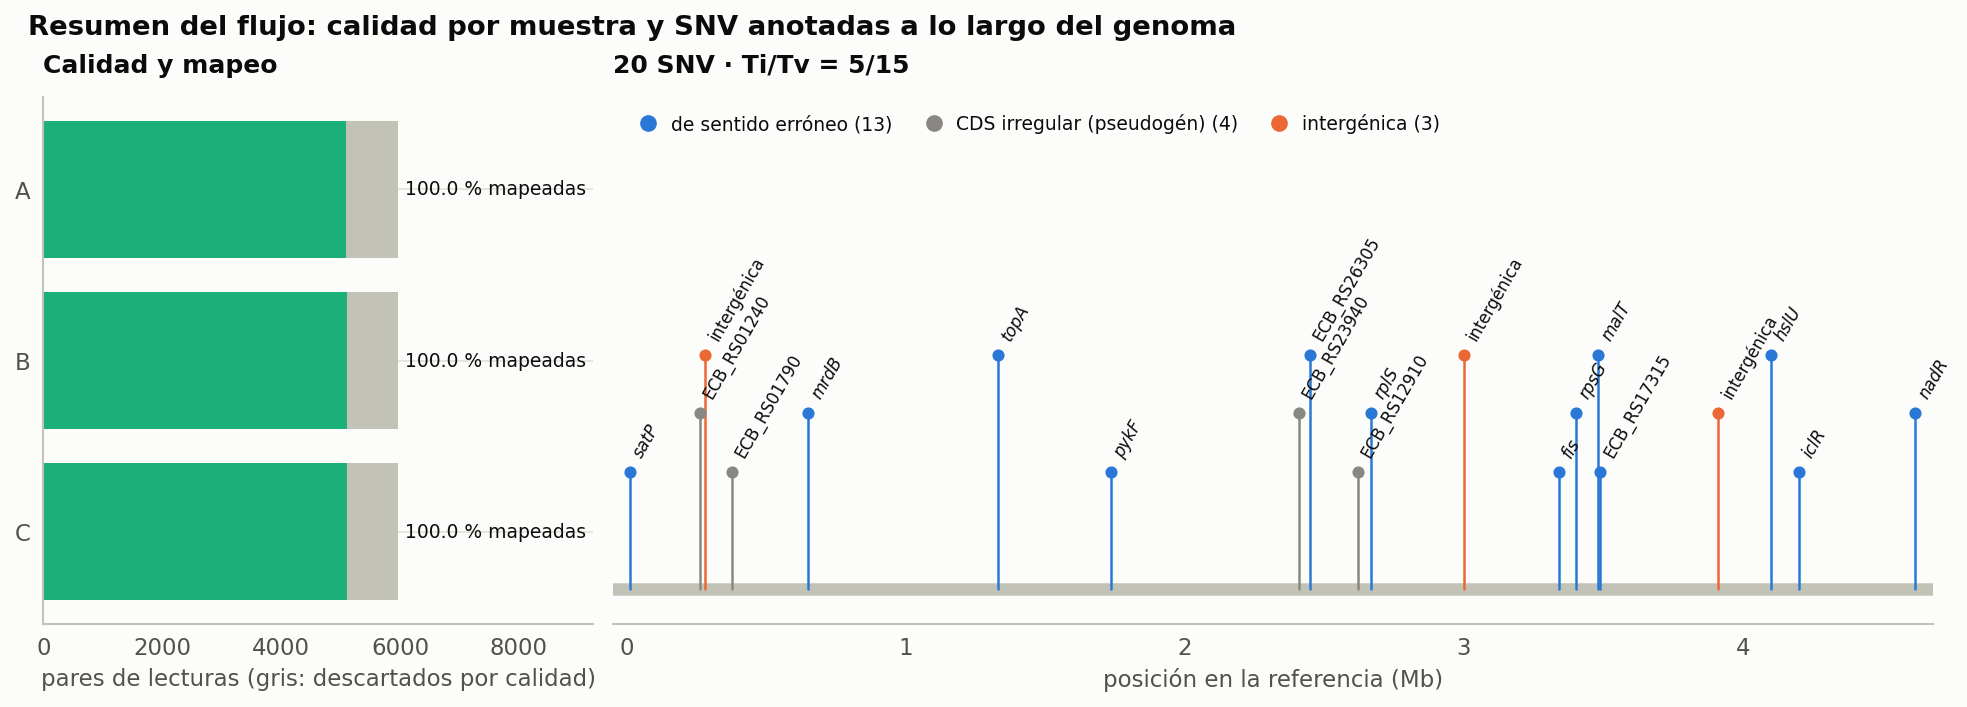

In [41]:
md = open(f"{PROJ}/resultados/informe.md").read()
display(Markdown("\n".join(l for l in md.splitlines() if not l.startswith("![") and not l.startswith("# "))))
display(Image(f"{PROJ}/resultados/figuras/resumen.png", width=1000))

> 🔎 **Qué observamos.** El flujo reproduce el resultado de la Lección 18.1 (las mismas opciones dan las mismas 20 SNV) y
> añade el efecto de cada una: *topA*, *pykF*, *malT*, *iclR*, *nadR*… son genes que el LTEE ha hecho famosos por acumular
> mutaciones beneficiosas en muchas poblaciones independientes (Tenaillon *et al.*, 2016). La mayoría de las SNV dentro de
> genes son **de sentido erróneo** (y ninguna sinónima), como se espera si la selección favorece cambios en esas
> proteínas; las marcadas como «CDS irregular» caen en copias del elemento IS1, cuyo CDS anotado no es múltiplo de 3. Comprobémoslo contra
> la 18.1 y hagamos las **comprobaciones de cordura** del tercer nivel.

In [42]:
var = pd.read_csv(f"{PROJ}/resultados/anotado.tsv", sep="\t", keep_default_na=False)
qcs = pd.read_csv(f"{PROJ}/resultados/qc_resumen.tsv", sep="\t")
LTEE_18_1 = {"topA", "pykF", "malT", "iclR", "nadR", "fis", "hslU", "mrdB"}      # genes destacados en la Lección 18.1
ts = sum((r + a) in ("AG", "GA", "CT", "TC") for r, a in zip(var.REF, var.ALT))
checks = [
    ("número de SNV como en la Lección 18.1 (20; otra versión de bcftools puede variar)", len(var), len(var) == 20),
    ("genes clásicos del LTEE presentes", ", ".join(sorted(LTEE_18_1 & set(var.gen))), LTEE_18_1 <= set(var.gen)),
    ("% de pares conservados por el QC ≥ 90 en todas las muestras", qcs["% conservados"].min(), (qcs["% conservados"] >= 90).all()),
    ("% de lecturas mapeadas ≥ 95 en todas las muestras", qcs["% mapeadas"].min(), (qcs["% mapeadas"] >= 95).all()),
    ("muestras con número de pares similar (máx/mín < 1,1)", round(qcs.pares.max() / qcs.pares.min(), 3),
     qcs.pares.max() / qcs.pares.min() < 1.1),
    ("Ti/Tv calculable (≥ 1 transversión)", f"{ts}/{len(var) - ts}", len(var) - ts > 0),
]
display(pd.DataFrame(checks, columns=["comprobación de cordura", "valor", "¿pasa?"])
        .assign(**{"¿pasa?": lambda d: d["¿pasa?"].map({True: "✅", False: "⚠️"})}))

,comprobación de cordura,valor,¿pasa?
0,número de SNV como en la Lección 18.1 (20; otr...,20,✅
1,genes clásicos del LTEE presentes,"fis, hslU, iclR, malT, mrdB, nadR, pykF, topA",✅
2,% de pares conservados por el QC ≥ 90 en todas...,85.2,⚠️
3,% de lecturas mapeadas ≥ 95 en todas las muestras,99.99,✅
4,muestras con número de pares similar (máx/mín ...,1.0,✅
5,Ti/Tv calculable (≥ 1 transversión),5/15,✅


> 🔎 **Qué observamos.** Todas pasan salvo una: el control de calidad descarta ~15 % de los pares, más de lo que fijamos
> como aceptable. No es un error del flujo sino una **decisión de diseño mejorable**: nuestro `qc.py` descarta el par entero
> si la calidad media de una lectura baja de Q20, y en las lecturas HiSeq de $2\times150$ pb la calidad cae hacia el
> extremo 3′ (Lección 6.2). Lo razonable sería **recortar** los extremos en lugar de descartar (ejercicio 3). Así funciona
> una comprobación de cordura: no detiene el flujo, obliga a explicar. Y mire el **Ti/Tv**: en genomas humanos esperamos ~2,0–2,1 y
> un valor bajo alertaría de falsos positivos (Lección 9.2); aquí es menor que 1. ¿Error? No necesariamente: son 20 SNV,
> seleccionadas de ventanas concretas, en una bacteria cuyo espectro mutacional no es el humano, y varias caen en copias
> del elemento IS1 (repeticiones donde el mapeo es dudoso). Una comprobación de cordura no es un veredicto automático: es
> una **pregunta** que el informe debe responder por escrito.

### La procedencia: qué produjo exactamente estos números

El archivo `procedencia.json` es la ecuación $R=f(C,\mathcal{E},D,\theta,\omega)$ hecha registro: *commit* y etiqueta
($C$), versiones ($\mathcal{E}$), sumas de las entradas ($D$ y también $\theta$, porque la configuración es una entrada
más).

In [43]:
prov = json.load(open(f"{PROJ}/resultados/procedencia.json"))
print(f"commit: {prov['commit'][:12]}  ·  etiqueta: {prov['etiqueta']}  ·  cambios sin commit: {prov['cambios_sin_commit']}")
print(f"python {prov['python']}  ·  {prov['plataforma']}")
display(pd.Series(prov["versiones"], name="versión").to_frame())
display(pd.DataFrame([(k, v[:16] + "…") for k, v in list(prov["sha256_entradas"].items())],
                     columns=["entrada", "SHA-256 (16 primeros dígitos)"]).head(12))

commit: 11a586906062  ·  etiqueta: v1.0  ·  cambios sin commit: False
python 3.12.2  ·  macOS-26.6.2-arm64-i386-64bit


,versión
bwa,Version: 0.7.19-r1273
samtools,samtools 1.24
bcftools,bcftools 1.24
snakemake,9.27.0
pandas,2.3.3
matplotlib,3.9.0


,entrada,SHA-256 (16 primeros dígitos)
0,datos/A_R1.fastq.gz,d32de76fe99ae840…
1,datos/A_R2.fastq.gz,e8f9884e18c0de28…
2,datos/B_R1.fastq.gz,0d92dea4856b0ceb…
3,datos/B_R2.fastq.gz,76af0d72450ce6d4…
4,datos/C_R1.fastq.gz,d3cc5cd023878bbe…
5,datos/C_R2.fastq.gz,e60c7035791ccaa3…
6,ref/REL606.fa,8c5a838b7b0d5061…
7,ref/genes.tsv.gz,f70586096e0eab1b…
8,config/config.yaml,dd95f890d218cd77…
9,workflow/Snakefile,c0b6264150925d89…


> 🔎 **Qué observamos.** El informe sabe con qué *commit* (`v1.0`), con qué versiones de cada programa y con qué bytes
> exactos de cada entrada se produjo. Compare las versiones con las de `envs/mapeo.yaml` y `envs/python.yaml`: aquí
> **no** coinciden, porque la tabla muestra el entorno con el que se ejecutó este cuaderno (en Colab, `apt-get` instala
> versiones más antiguas que las fijadas; la corrida guardada del curso usó otras más recientes), no el entorno conda del
> proyecto. La procedencia lo delata, y **ése** es el tipo de discrepancia que explica por qué dos personas obtienen
> resultados distintos «con el mismo código». La plataforma también es procedencia: la corrida guardada se hizo en macOS;
> en Colab verá Linux.

### La prueba de fuego: un compañero reproduce el análisis

El hito H4 del cronograma: otra persona, con el repositorio, las accesiones y una orden, obtiene lo mismo. Simulémoslo:
clonamos el repositorio en otra carpeta, «descargamos» los datos por su accesión (aquí, con la misma función del curso),
**verificamos las sumas** antes de nada, ejecutamos y comparamos las huellas de las tablas de resultados.

In [44]:
PEER = os.path.join(TMP, "proyecto-ltee-par")
shutil.rmtree(PEER, ignore_errors=True)
if HAS_TOOLS and HAS_GIT:
    sh(f"git clone -q {PROJ} {PEER}")
    fetch_inputs(PEER)                                     # descarga por accesión (simulada)
    status = verify(f"{PEER}/checksums.sha256", PEER)
    print("verificación de datos en la máquina del par:",
          {k: sum(v == k for v in status.values()) for k in ("OK", "FAILED", "FALTA")})
    log, secs_peer = smk("--cores 2", root=PEER, quiet=True)
    prov_peer = json.load(open(f"{PEER}/resultados/procedencia.json"))
    comp = pd.DataFrame({"yo": prov["sha256_salidas"], "par": prov_peer["sha256_salidas"]})
    comp["¿idénticas?"] = np.where(comp.yo == comp.par, "✅", "❌")
    comp[["yo", "par"]] = comp[["yo", "par"]].apply(lambda c: c.str[:20] + "…")
    print(f"reproducción completa en {secs_peer:.1f} s")
    display(comp)
else:
    print("(sin herramientas o sin git: se omite la reproducción)")

$ git clone -q /tmp/proyecto-ltee /tmp/proyecto-ltee-par


verificación de datos en la máquina del par: {'OK': 8, 'FAILED': 0, 'FALTA': 0}


reproducción completa en 7.6 s


,yo,par,¿idénticas?
resultados/anotado.tsv,bcaa0c7e18f66de80291…,bcaa0c7e18f66de80291…,✅
resultados/qc_resumen.tsv,1d7fdaaf16d786e93eb6…,1d7fdaaf16d786e93eb6…,✅


> 🔎 **Qué observamos.** Las tablas de resultados del par son **idénticas bit a bit** a las nuestras: mismas huellas SHA-256.
> Es posible porque el flujo es determinista (mismas versiones, un solo hilo por paso sensible, sin aleatoriedad sin
> semilla) y porque hasheamos tablas de texto, no archivos binarios con fechas dentro. Si el par tuviera otra versión de
> `bcftools`, lo sensato sería comparar las tablas **con tolerancias** (mismas SNV, calidades parecidas), y la procedencia
> explicaría la diferencia. Éste es, literalmente, el criterio de «proyecto terminado» del libro.

### ¿Y la opción B?

La estructura es la misma; cambian las reglas y las comprobaciones de cordura. Un *Snakefile* de RNA-seq tendría `fastp`
por muestra, `salmon_index` una vez, `salmon_quant` por muestra (Lección 11.1), una regla `tximport` que junte las
cuantificaciones en una matriz de conteos, `deseq2` (Lecciones 11.2 y 11.3) y `enriquecimiento` (Lección 11.4). La
comprobación de cordura más valiosa es la **correlación entre muestras**: las réplicas deben parecerse. Hagámosla con los
conteos reales del experimento *airway*.

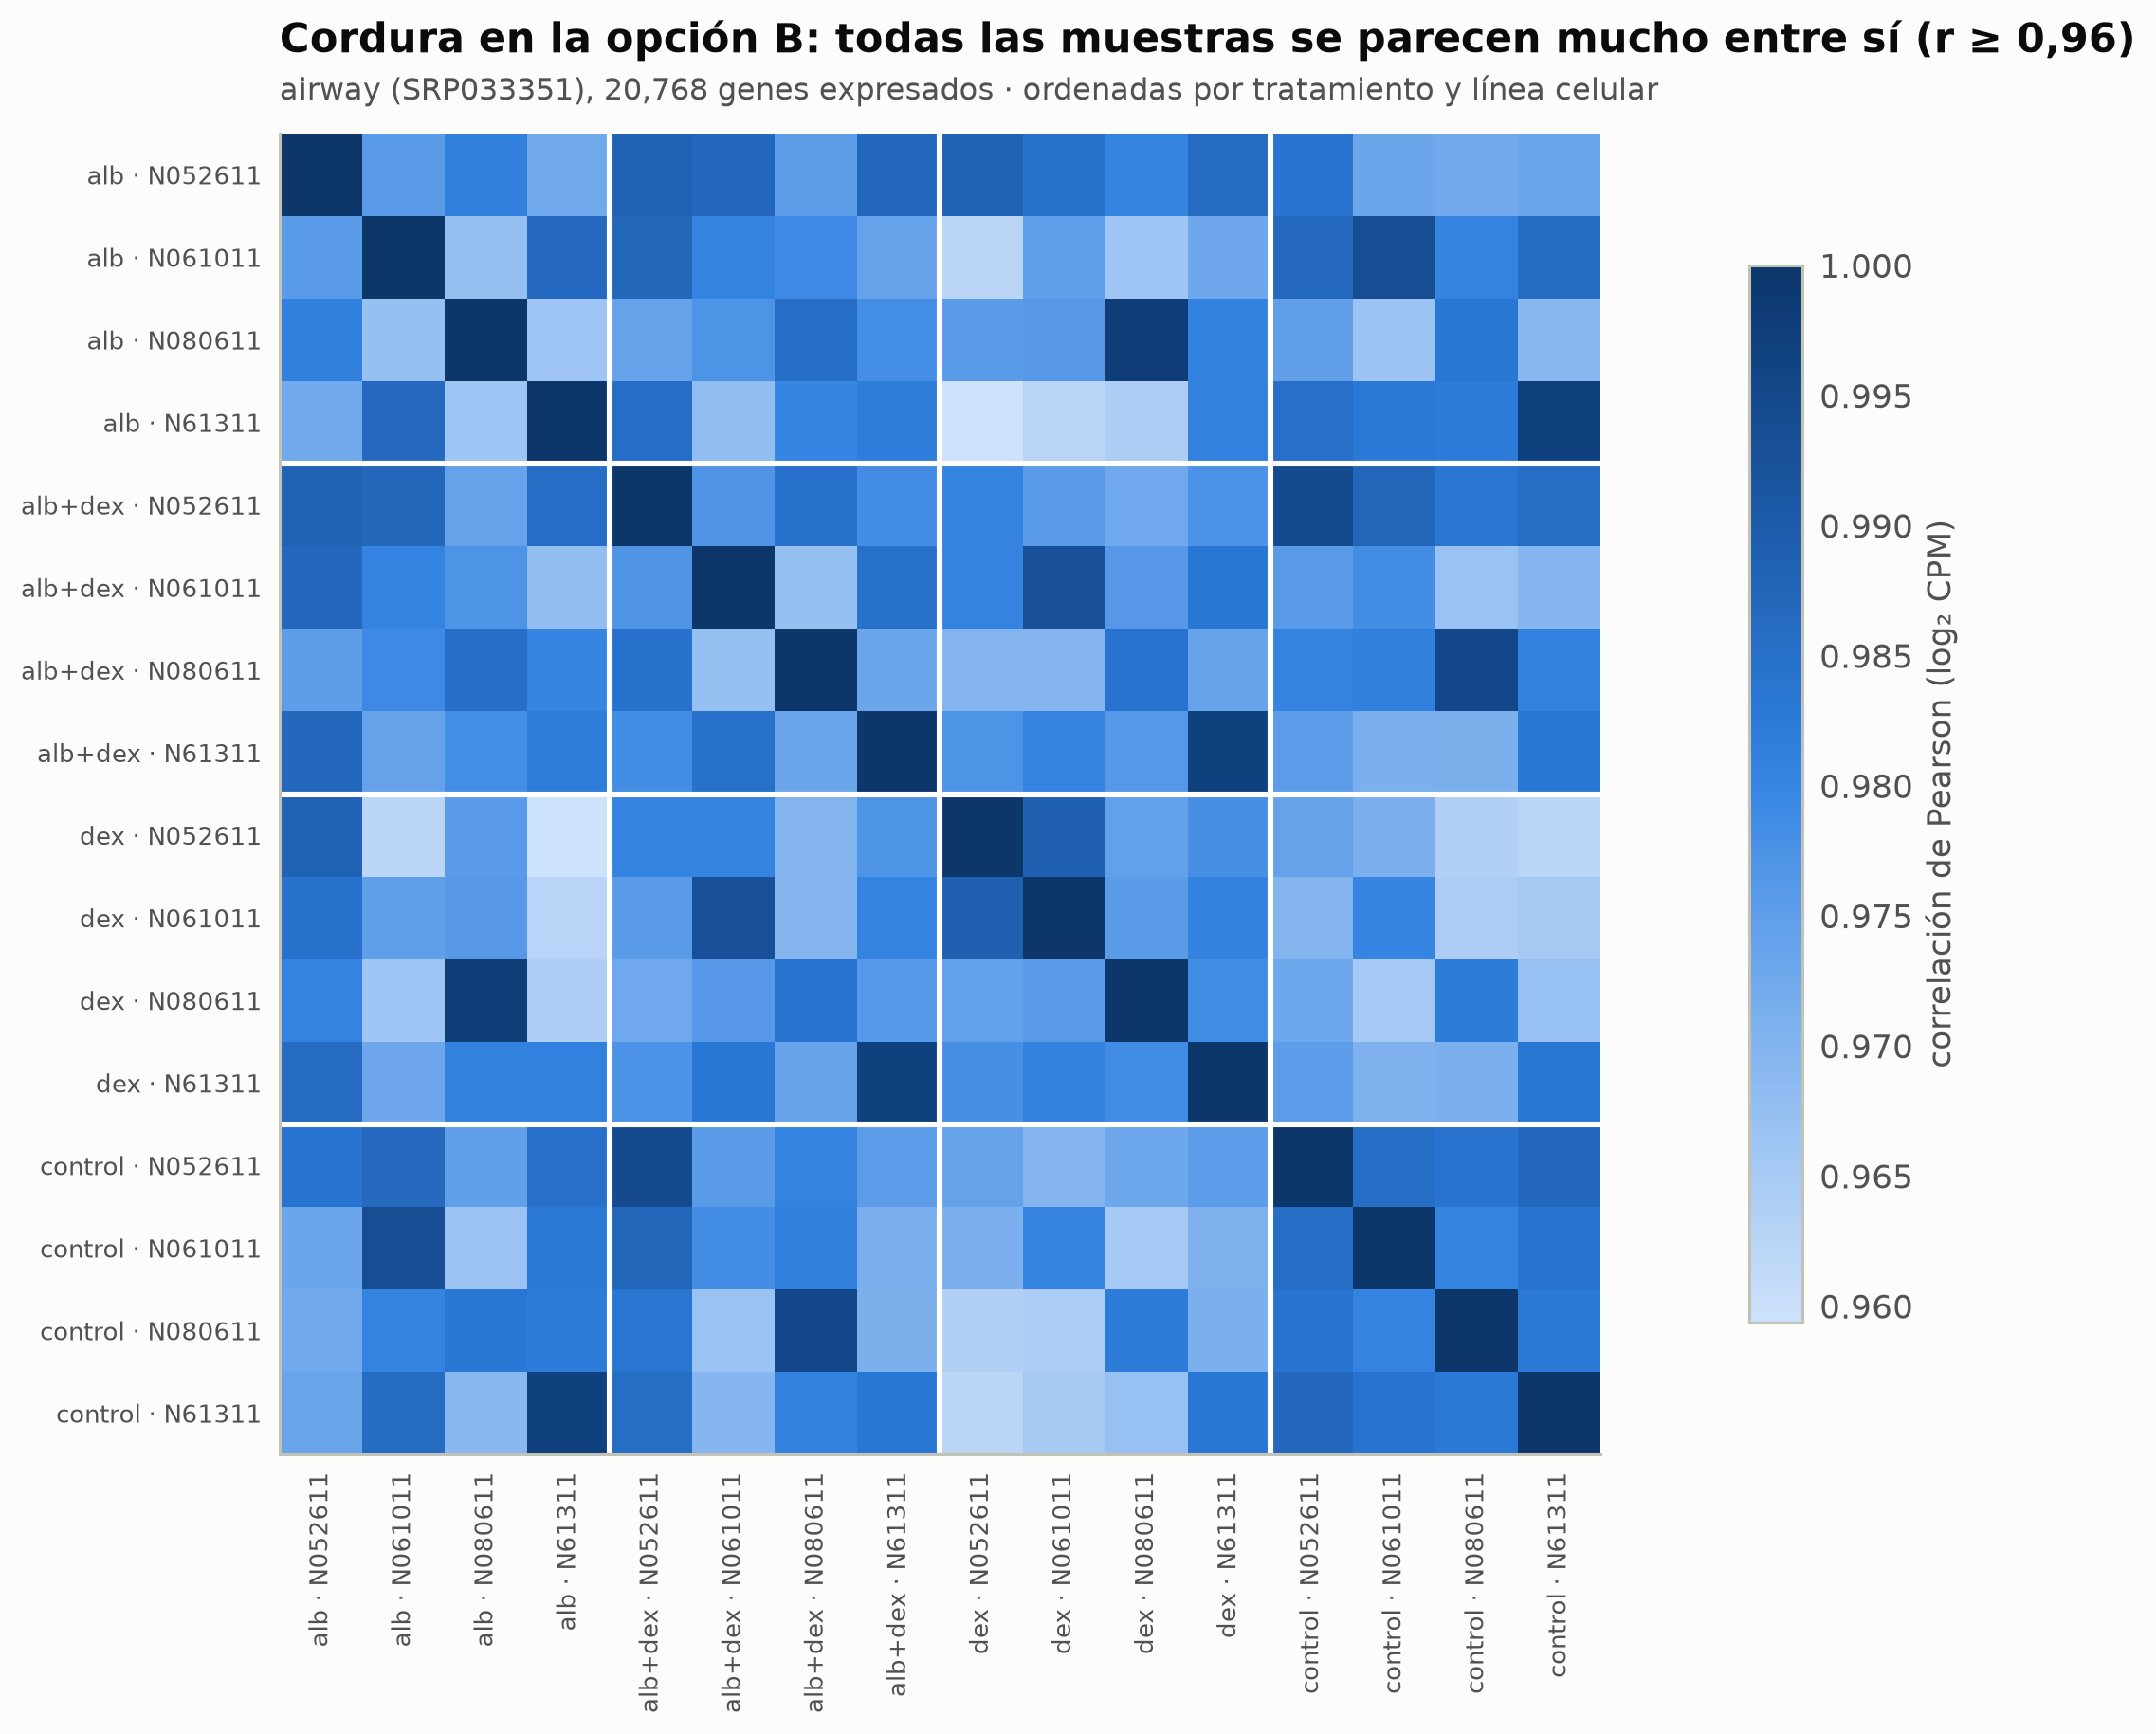

In [45]:
cnt = pd.read_csv(course_file("airway_SRP033351_counts.tsv.gz"), sep="\t")
X = cnt.iloc[:, 5:]
X = X[(X >= 10).sum(axis=1) >= 4]                             # genes con expresión apreciable
logcpm = np.log2(X / X.sum() * 1e6 + 1)
corr = np.corrcoef(logcpm.T.values)
meta = air.set_index("run").loc[X.columns]
order = meta.sort_values(["treatment", "cell"]).index
idx = [list(X.columns).index(r) for r in order]
C = corr[np.ix_(idx, idx)]
short = {"Untreated": "control", "Dexamethasone": "dex", "Albuterol": "alb", "Albuterol_Dexamethasone": "alb+dex"}
labels = [f"{short[meta.loc[r, 'treatment']]} · {meta.loc[r, 'cell']}" for r in order]
fig, ax = plt.subplots(figsize=(10.5, 8.2))
im = ax.imshow(C, cmap="curso_seq", vmin=C.min(), vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(labels, rotation=90, fontsize=8.5)
ax.set_yticks(range(len(order))); ax.set_yticklabels(labels, fontsize=8.5)
ax.grid(False)
for k in range(4, 16, 4):
    ax.axhline(k - 0.5, color="white", lw=2); ax.axvline(k - 0.5, color="white", lw=2)
cb = fig.colorbar(im, ax=ax, shrink=0.8); cb.set_label("correlación de Pearson (log₂ CPM)")
ec.title(ax, f"Cordura en la opción B: todas las muestras se parecen mucho entre sí (r ≥ {C.min():.2f})".replace(".", ","),
         f"airway (SRP033351), {len(X):,} genes expresados · ordenadas por tratamiento y línea celular")
plt.show()

> 🔎 **Qué observamos.** Las correlaciones son todas altísimas, como corresponde a un mismo tipo celular: el efecto de la
> dexametasona afecta a unos cientos de genes, no a todo el transcriptoma. Por eso la correlación global sirve para
> detectar **muestras rotas** (una biblioteca fallida tendría $r$ claramente menor), pero no para ver el tratamiento: para
> eso hace falta el PCA o el análisis diferencial de las Lecciones 11.2 y 11.3 (donde, recuerde, encontramos un probable
> intercambio de etiquetas). Una comprobación de cordura contesta una pregunta precisa; elija la adecuada para cada etapa.

## 7. Metadatos y publicación de datos

Las lecturas crudas de cualquier estudio publicado deben depositarse en un archivo público del consorcio INSDC: el
***Sequence Read Archive*** (SRA) del NCBI (Leinonen, Sugawara y Shumway, 2011) o el ***European Nucleotide Archive***
(ENA) del EMBL-EBI (Leinonen *et al.*, 2011), que se replican entre sí. Ya los consultamos en la Lección 2.2; ahora nos toca
**depositar**. Ambos organizan los metadatos en una jerarquía que refleja la estructura de un experimento: un **proyecto**
agrupa **muestras** biológicas; de cada muestra se preparan uno o varios **experimentos** (bibliotecas secuenciadas con una
tecnología); cada experimento produce una o varias **corridas**, que contienen los archivos.

Veámoslo con la corrida de nuestro clon, tal como la describe el ENA (respuesta del portal guardada en el repositorio del
curso; la celda intenta primero la consulta en vivo).

In [46]:
ENA_URL = ("https://www.ebi.ac.uk/ena/portal/api/filereport?accession=SRR2584863&result=read_run&format=tsv&fields="
           "run_accession,experiment_accession,sample_accession,secondary_sample_accession,study_accession,"
           "secondary_study_accession,sample_alias,sample_title,experiment_title,study_title,scientific_name,strain,"
           "instrument_platform,instrument_model,library_name,library_layout,library_strategy,library_source,"
           "library_selection,nominal_length,read_count,base_count,first_public,collection_date,country,host,"
           "fastq_bytes,fastq_md5")
try:
    ena = pd.read_csv(course_file("182_ena_SRR2584863_metadatos.tsv"), sep="\t", dtype=str, keep_default_na=False)
    origin = "copia del curso"
except Exception:
    ena = pd.read_csv(ENA_URL, sep="\t", dtype=str, keep_default_na=False)
    origin = "ENA en vivo"
E = ena.iloc[0]
print("origen:", origin)
display(E.to_frame("valor"))

origen: copia del curso


,valor
run_accession,SRR2584863
experiment_accession,SRX1317390
sample_accession,SAMN04096083
secondary_sample_accession,SRS1108291
study_accession,PRJNA295606
secondary_study_accession,SRP064605
sample_alias,REL7179B
sample_title,Microbe sample from Escherichia coli B str. RE...
experiment_title,Illumina HiSeq 2500 sequencing: REL7179B
study_title,"E. coli genome evolution over 50,000 generations"


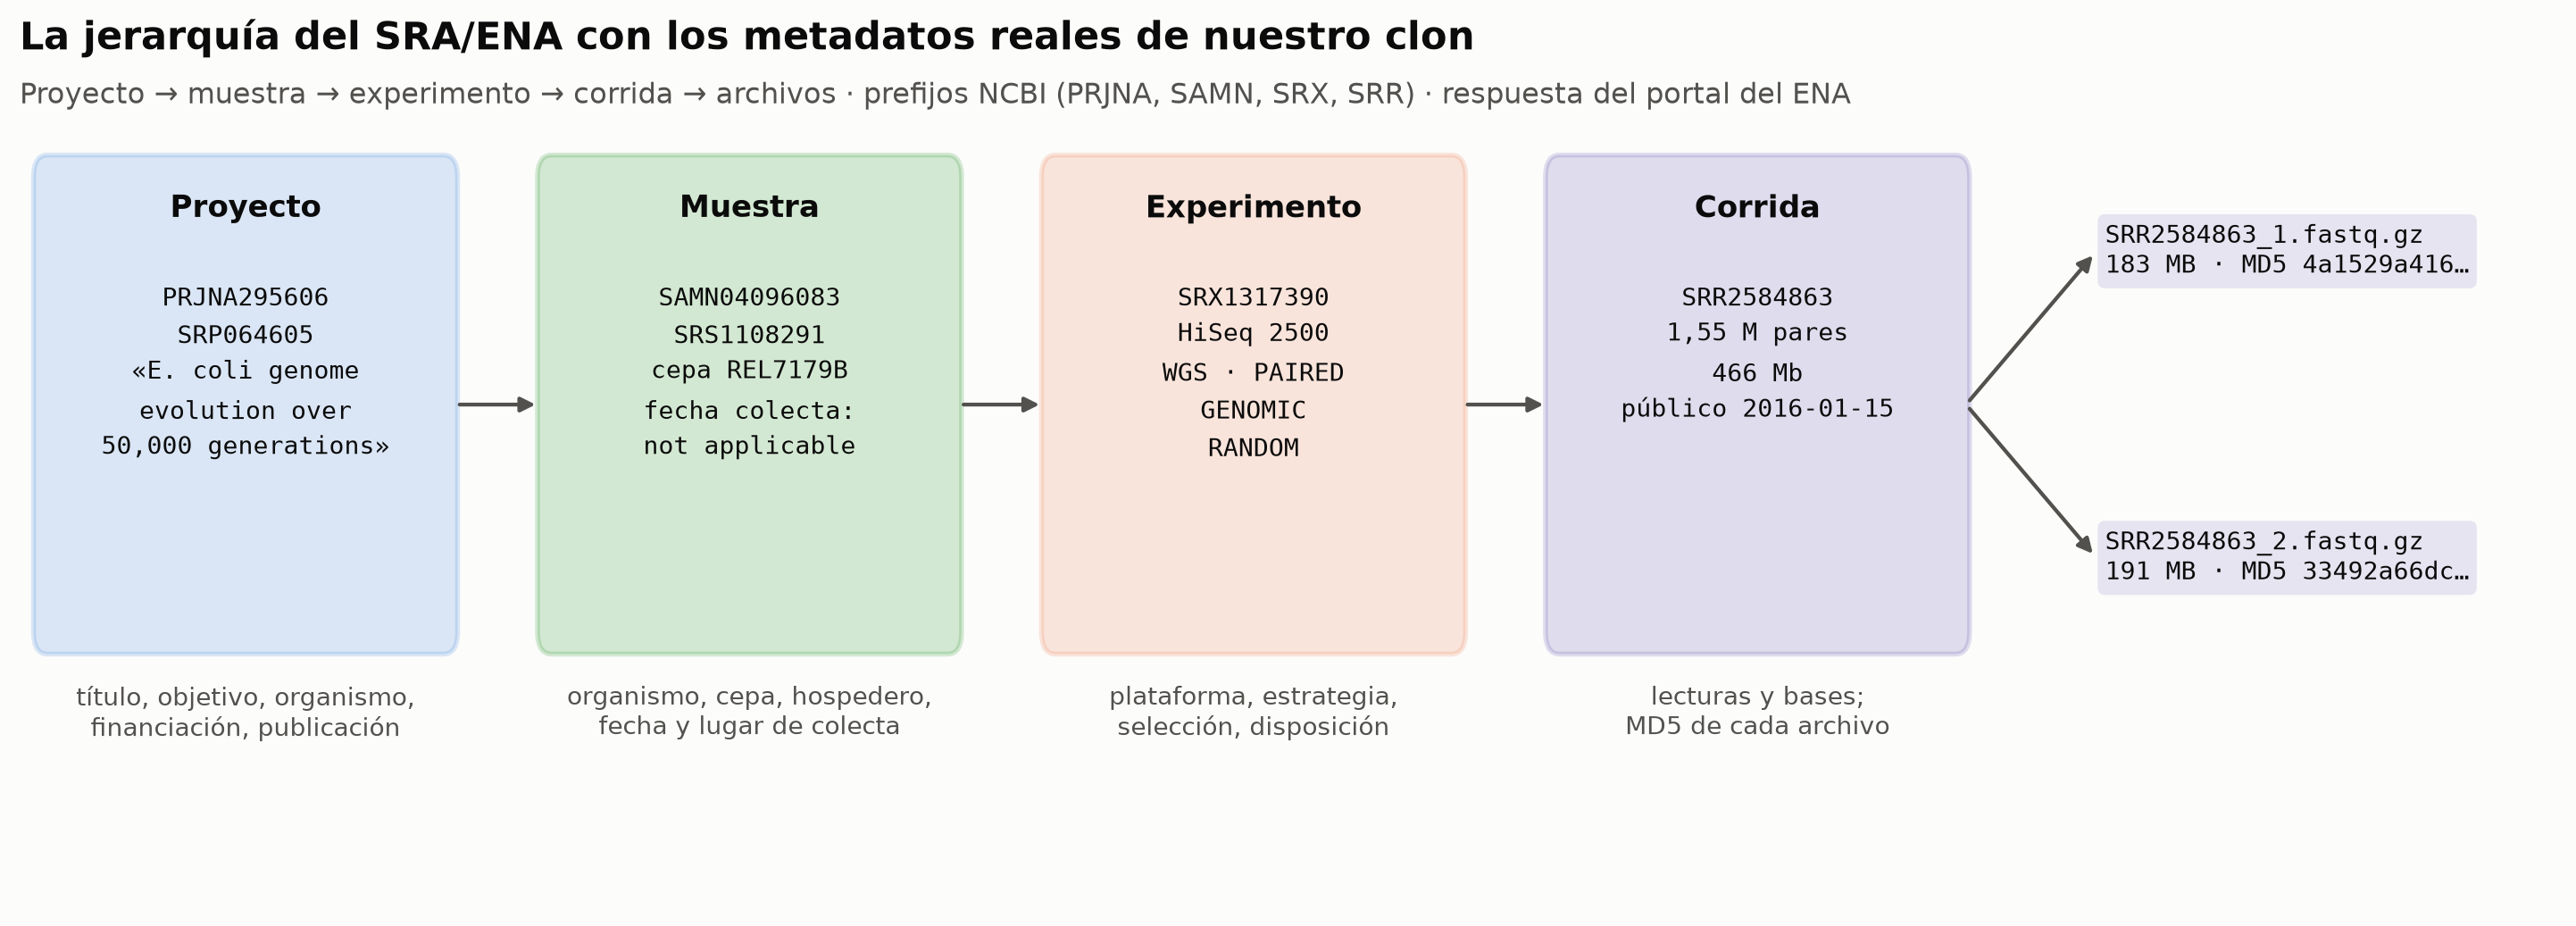

In [47]:
from matplotlib.patches import FancyBboxPatch
def box(ax, x, y, w, h, title, lines, col):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=col, alpha=0.16, edgecolor=col, lw=1.8))
    ax.text(x, y + h / 2 - 0.12, title, ha="center", va="top", fontsize=11, fontweight="bold")
    ax.text(x, y + h / 2 - 0.42, "\n".join(lines), ha="center", va="top", fontsize=9.2, family="monospace",
            color=ec.INK, linespacing=1.5)

def arrow(ax, a, b_):
    ax.annotate("", b_, a, arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.4))

md5 = E.fastq_md5.split(";"); size = E.fastq_bytes.split(";")
fig, ax = plt.subplots(figsize=(13, 4.6))
box(ax, 1.3, 2.0, 2.4, 1.75, "Proyecto", [E.study_accession, E.secondary_study_accession, "«E. coli genome", "evolution over", "50,000 generations»"], ec.BLUE)
box(ax, 4.2, 2.0, 2.4, 1.75, "Muestra", [E.sample_accession, E.secondary_sample_accession, f"cepa {E.strain}", "fecha colecta:", E.collection_date], ec.GREEN)
box(ax, 7.1, 2.0, 2.4, 1.75, "Experimento", [E.experiment_accession, E.instrument_model.replace("Illumina ", ""),
                                            f"{E.library_strategy} · {E.library_layout}", E.library_source, E.library_selection], ec.ORANGE)
box(ax, 10.0, 2.0, 2.4, 1.75, "Corrida", [E.run_accession, f"{int(E.read_count) / 1e6:.2f} M pares".replace(".", ","), f"{int(E.base_count) / 1e6:.0f} Mb",
                                         f"público {E.first_public}"], ec.VIOLET)
for a, b_ in [((2.5, 2.0), (3.0, 2.0)), ((5.4, 2.0), (5.9, 2.0)), ((8.3, 2.0), (8.8, 2.0))]:
    arrow(ax, a, b_)
for k in (0, 1):
    ax.text(12.0, 2.55 - 1.1 * k, f"SRR2584863_{k + 1}.fastq.gz\n{int(size[k]) / 1e6:.0f} MB · MD5 {md5[k][:10]}…",
            fontsize=9, family="monospace", va="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor=ec.VIOLET, alpha=0.12, edgecolor=ec.VIOLET))
    arrow(ax, (11.2, 2.0), (11.95, 2.55 - 1.1 * k))
for x, txt in [(1.3, "título, objetivo, organismo,\nfinanciación, publicación"), (4.2, "organismo, cepa, hospedero,\nfecha y lugar de colecta"),
               (7.1, "plataforma, estrategia,\nselección, disposición"), (10.0, "lecturas y bases;\nMD5 de cada archivo")]:
    ax.text(x, 1.0, txt, ha="center", va="top", fontsize=9, color=ec.INK_2)
ax.set_xlim(0, 14.6); ax.set_ylim(0.2, 3.0); ax.axis("off")
ec.title(ax, "La jerarquía del SRA/ENA con los metadatos reales de nuestro clon",
         "Proyecto → muestra → experimento → corrida → archivos · prefijos NCBI (PRJNA, SAMN, SRX, SRR) · respuesta del portal del ENA")
plt.show()

> 🔎 **Qué observamos.** Cada nivel tiene su accesión y sus metadatos. El artículo debe citar la accesión del **proyecto**
> (PRJNA295606) y el flujo debe descargar las lecturas por la de la **corrida** (SRR2584863). Mire la muestra: la fecha de
> colecta dice `not applicable` (es un clon de laboratorio congelado, no un aislado clínico) y el país y el hospedero están
> vacíos. Para un clon del LTEE es razonable; para la opción A sería **inaceptable**: la fecha y el país de colecta, el
> hospedero y el tipo de muestra son imprescindibles para cualquier análisis epidemiológico posterior. Para la opción B, lo
> son la condición, la réplica, el tejido y el lote de preparación de bibliotecas.

Los depósitos exigen **listas de verificación** (*checklists*) con campos obligatorios y vocabularios controlados,
precisamente para que los principios **FAIR** (encontrables, accesibles, interoperables y reutilizables; Wilkinson *et al.*,
2016) se cumplan en la práctica. Nuestro `config/muestras.tsv` ya contiene esas columnas: la misma tabla alimenta el flujo y
el depósito. Escribamos un **validador**.

### Las hojas de cálculo reescriben sus datos

Antes, una advertencia del libro. Abrir una tabla de metadatos o de genes en una hoja de cálculo es arriesgado: los
programas convierten silenciosamente nombres como *SEPT2* o *MARCH1* en fechas, e identificadores largos en notación
científica. Ziemann, Eren y El-Osta (2016) encontraron este tipo de error en aproximadamente **una de cada cinco**
publicaciones que incluían listas de genes en archivos de Excel como material suplementario. Edite los metadatos como texto
plano (TSV), valídelos con un *script* y nunca guarde una tabla «pasada» por una hoja de cálculo como fuente de verdad.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué errores debería encontrar el validador en la versión «pasada por Excel» de la
> tabla de la celda siguiente?

In [48]:
REQUIRED = ["muestra", "run_accession", "sample_accession", "organismo", "cepa", "fecha_colecta", "pais",
            "hospedero", "tipo_muestra", "plataforma", "estrategia", "disposicion"]
VOCAB = {"estrategia": {"WGS", "RNA-Seq", "AMPLICON", "ChIP-Seq", "ATAC-seq", "Bisulfite-Seq"},
         "plataforma": {"ILLUMINA", "OXFORD_NANOPORE", "PACBIO_SMRT", "ION_TORRENT"},
         "disposicion": {"PAIRED", "SINGLE"}}
MISSING = {"not applicable", "not collected", "not provided", "restricted access", "missing"}   # valores INSDC
PATTERNS = {"run_accession": r"^[SED]RR\d{6,}$", "sample_accession": r"^SAM[NED][A-Z]?\d+$"}
EXCEL_DATE = re.compile(r"^\d{1,2}-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)$|^\d{4}-\d{2}-\d{2} 00:00:00$")
SCI = re.compile(r"^\d(\.\d+)?E\+\d+$", re.I)

def validate(df):
    """Devuelve una lista de (fila, columna, problema). Lista vacía = tabla válida."""
    errs = [("—", c, "columna obligatoria ausente") for c in REQUIRED if c not in df.columns]
    if df["muestra"].duplicated().any():
        errs.append(("—", "muestra", "identificadores repetidos"))
    for i, r in df.iterrows():
        for c in df.columns:
            v = str(r[c]).strip()
            if v == "" and c in REQUIRED:
                errs.append((i, c, "vacío: use un valor INSDC como 'not collected'"))
            if EXCEL_DATE.match(v):
                errs.append((i, c, f"'{v}' parece un gen convertido en fecha por una hoja de cálculo"))
            if SCI.match(v):
                errs.append((i, c, f"'{v}' parece un identificador convertido a notación científica"))
        for c, voc in VOCAB.items():
            if c in df and r[c] not in voc:
                errs.append((i, c, f"'{r[c]}' fuera del vocabulario controlado"))
        for c, pat in PATTERNS.items():
            if c in df and not re.match(pat, str(r[c])):
                errs.append((i, c, f"'{r[c]}' no tiene formato de accesión"))
        if "fecha_colecta" in df and r["fecha_colecta"] not in MISSING and \
                not re.match(r"^\d{4}(-\d{2}(-\d{2})?)?$", str(r["fecha_colecta"])):
            errs.append((i, "fecha_colecta", f"'{r['fecha_colecta']}' no es ISO 8601 (AAAA-MM-DD)"))
    return errs

meta_ok = pd.read_csv(f"{PROJ}/config/muestras.tsv", sep="\t", dtype=str, keep_default_na=False)
print("config/muestras.tsv →", validate(meta_ok) or "✅ sin problemas")

# La misma idea para la opción A... después de pasar por una hoja de cálculo
excel = pd.DataFrame({
    "muestra": ["TB01", "TB02", "TB02"], "run_accession": ["ERR1234567", "1.23457E+06", "ERR1234569"],
    "sample_accession": ["SAMEA1234567", "SAMEA1234568", "SAMEA1234569"],
    "organismo": ["Mycobacterium tuberculosis"] * 3, "cepa": ["H37Rv-like", "", "Beijing"],
    "fecha_colecta": ["2024-03-17", "17/03/2024", "2024-03"], "pais": ["Colombia"] * 3,
    "hospedero": ["Homo sapiens"] * 3, "tipo_muestra": ["esputo"] * 3, "plataforma": ["ILLUMINA", "Illumina", "ILLUMINA"],
    "estrategia": ["WGS"] * 3, "disposicion": ["PAIRED"] * 3, "gen_diana": ["katG", "2-Sep", "1-Mar"]})
display(pd.DataFrame(validate(excel), columns=["fila", "columna", "problema"]))

config/muestras.tsv → ✅ sin problemas


,fila,columna,problema
0,—,muestra,identificadores repetidos
1,1,run_accession,'1.23457E+06' parece un identificador converti...
2,1,cepa,vacío: use un valor INSDC como 'not collected'
3,1,gen_diana,'2-Sep' parece un gen convertido en fecha por ...
4,1,plataforma,'Illumina' fuera del vocabulario controlado
5,1,run_accession,'1.23457E+06' no tiene formato de accesión
6,1,fecha_colecta,'17/03/2024' no es ISO 8601 (AAAA-MM-DD)
7,2,gen_diana,'1-Mar' parece un gen convertido en fecha por ...


> 🔎 **Qué observamos.** Nuestra tabla pasa. La tabla ficticia de un brote de tuberculosis acumula los errores clásicos: un
> identificador repetido, una accesión convertida a notación científica, una fecha en formato local, un campo obligatorio
> vacío, una plataforma fuera del vocabulario (`Illumina` en lugar de `ILLUMINA`) y dos genes convertidos en fechas
> (`2-Sep` era *SEPT2*, hoy *SEPTIN2*, y `1-Mar` era *MARCH1*, hoy *MARCHF1*: el propio comité de nomenclatura HGNC renombró
> esos genes en 2020 para evitar el problema). El validador es una regla más del flujo: si falla, el flujo no empieza.

## 8. Ética y datos humanos

La opción A trabaja con genomas de bacterias, pero las muestras vienen de **pacientes**; la opción B puede usar ARN humano.
En ambos casos entran en juego obligaciones éticas y legales que deben **planificarse desde el diseño**, no resolverse en el
momento de publicar.

| Tema | Qué exige | Cómo se refleja en el proyecto |
|---|---|---|
| **Consentimiento y aprobación ética** | aprobación de un comité de ética y consentimiento cuyo alcance cubra el uso previsto (incluido el depósito) | número de aprobación en el `README`; reutilizar datos públicos no exime de respetar sus condiciones |
| **La anonimización genómica es frágil** | Gymrek *et al.* (2013) infirieron apellidos de participantes «anónimos» a partir de STR del cromosoma Y cruzados con bases genealógicas, y con edad y lugar los reidentificaron | datos humanos individuales sólo en archivos de **acceso controlado** (dbGaP, EGA) |
| **Protección de datos** | el GDPR europeo (desde mayo de 2018) trata los datos genéticos como **categoría especial**; los seudonimizados siguen siendo personales (Shabani y Borry, 2018); en Colombia rige la Ley 1581 de 2012 | compruebe qué ley se aplica a sus datos y a su institución |
| **Lecturas del hospedero** | las lecturas de un patógeno de una muestra clínica contienen a menudo lecturas humanas | una regla que mapee contra la referencia humana y descarte lo que coincida, **antes** del depósito |
| **Metadatos identificadores** | fecha exacta, hospital y edad pueden identificar a un paciente en una comunidad pequeña | reducir la resolución (mes en lugar de día, región en lugar de dirección) si no afecta a la pregunta |

El último punto se puede **medir**. Llamamos *cuasi-identificadores* a las columnas que, combinadas, pueden señalar a una
persona (fecha, lugar, edad, sexo). Una tabla es **$k$-anónima** si cada combinación de cuasi-identificadores aparece al
menos $k$ veces: con $k=1$ hay personas únicas, potencialmente reidentificables. Probémoslo con metadatos **ficticios** de
un brote hospitalario de 60 pacientes, antes y después de reducir la resolución.

In [49]:
rng = np.random.default_rng(18)
n_pat = 60
clin = pd.DataFrame({
    "fecha": pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 150, n_pat), unit="D"),
    "municipio": rng.choice(["Chía", "Cajicá", "Zipaquirá", "Sopó", "Tocancipá", "Cota"], n_pat),
    "edad": rng.integers(18, 85, n_pat), "sexo": rng.choice(["F", "M"], n_pat)})

def coarsen(df):
    """Reduce la resolución de los cuasi-identificadores: mes, región y decenio de edad."""
    return pd.DataFrame({"fecha": df.fecha.dt.to_period("M").astype(str), "municipio": "Sabana Centro",
                         "edad": (df.edad // 10 * 10).astype(str) + "–" + (df.edad // 10 * 10 + 9).astype(str),
                         "sexo": df.sexo})

def k_of_each_row(df, cols):
    return df.groupby(cols)[cols[0]].transform("size")

QI = ["fecha", "municipio", "edad", "sexo"]
k_raw, k_coarse = k_of_each_row(clin, QI), k_of_each_row(coarsen(clin), QI)
k_date_only = k_of_each_row(coarsen(clin)[["fecha", "municipio"]], ["fecha", "municipio"])
print(f"datos originales : k mínimo = {k_raw.min()} · pacientes únicos (k = 1): {(k_raw == 1).sum()} de {n_pat}")
print(f"mes+región+decenio: k mínimo = {k_coarse.min()} · pacientes únicos: {(k_coarse == 1).sum()} de {n_pat}")
print(f"sólo mes y región : k mínimo = {k_date_only.min()} · pacientes únicos: {(k_date_only == 1).sum()} de {n_pat}")
display(pd.concat([clin.head(4).assign(fecha=lambda d: d.fecha.dt.date), coarsen(clin).head(4)], axis=1,
                  keys=["original", "resolución reducida"]))

datos originales : k mínimo = 1 · pacientes únicos (k = 1): 60 de 60
mes+región+decenio: k mínimo = 1 · pacientes únicos: 26 de 60
sólo mes y región : k mínimo = 8 · pacientes únicos: 0 de 60


original                      resolución reducida                        \
        fecha  municipio edad sexo               fecha      municipio   edad   
0  2024-05-14       Chía   49    F             2024-05  Sabana Centro  40–49   
1  2024-02-29  Zipaquirá   61    M             2024-02  Sabana Centro  60–69   
2  2024-02-01       Cota   24    M             2024-02  Sabana Centro  20–29   
3  2024-04-17       Cota   56    F             2024-04  Sabana Centro  50–59   

        
  sexo  
0    F  
1    M  
2    M  
3    F

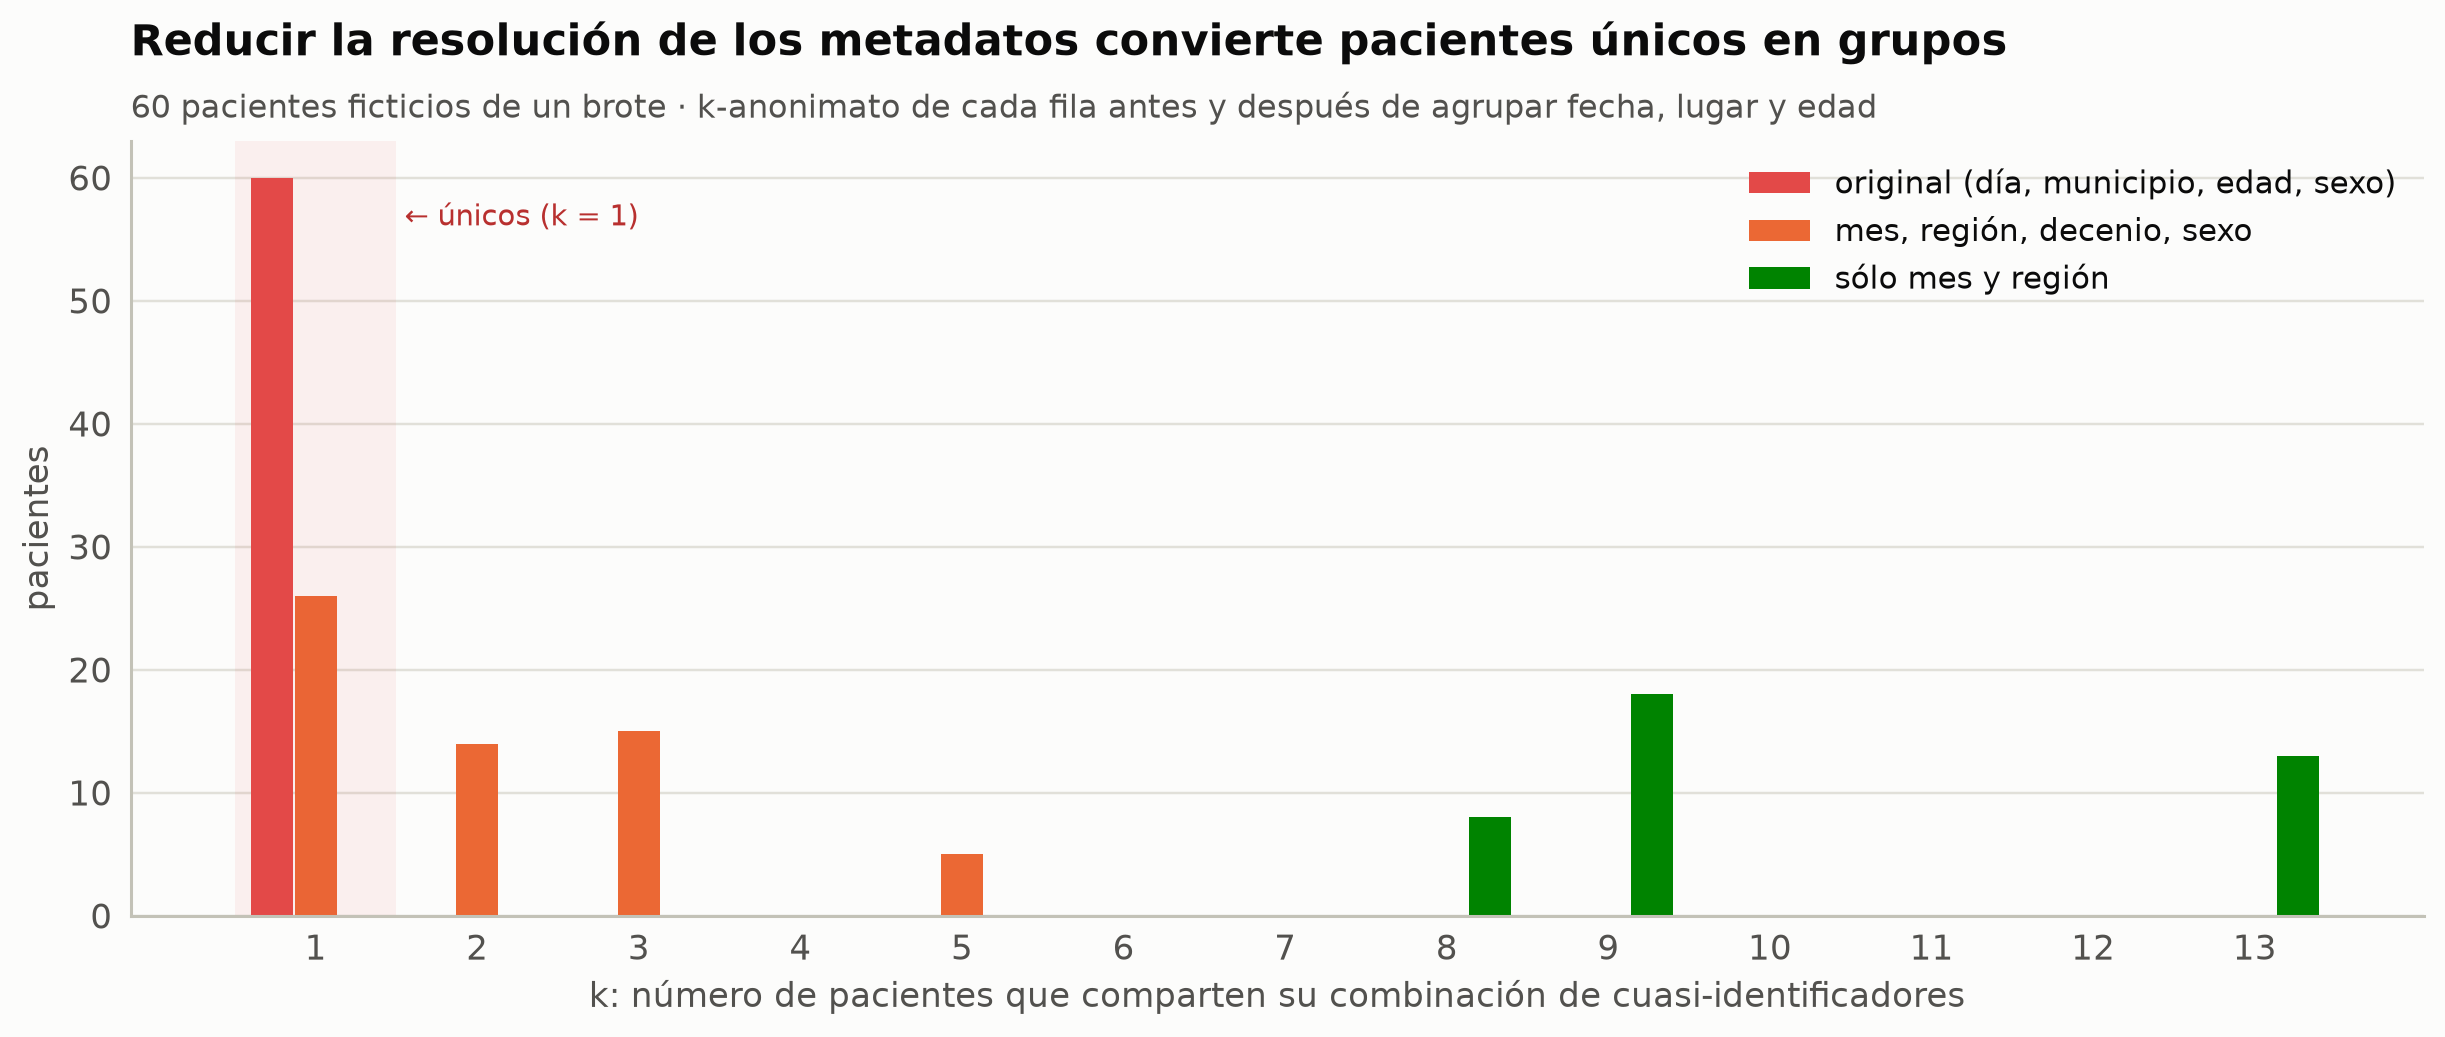

In [50]:
fig, ax = plt.subplots(figsize=(11, 4.6))
bins = np.arange(0.5, 14.5, 1)
for vals, col, lab, off in [(k_raw, ec.RED, "original (día, municipio, edad, sexo)", -0.27),
                            (k_coarse, ec.ORANGE, "mes, región, decenio, sexo", 0.0),
                            (k_date_only, ec.GREEN, "sólo mes y región", 0.27)]:
    cnt = np.bincount(vals, minlength=14)[1:14]
    ax.bar(np.arange(1, 14) + off, cnt, width=0.26, color=col, label=lab)
ax.axvspan(0.5, 1.5, color=ec.RED, alpha=0.07)
ax.text(1.55, 58, "← únicos (k = 1)", ha="left", va="top", fontsize=9.5, color="#b8302f")
ax.set_xticks(range(1, 14))
ax.set_xlabel("k: número de pacientes que comparten su combinación de cuasi-identificadores")
ax.set_ylabel("pacientes")
ax.legend(loc="upper right")
ec.title(ax, "Reducir la resolución de los metadatos convierte pacientes únicos en grupos",
         "60 pacientes ficticios de un brote · k-anonimato de cada fila antes y después de agrupar fecha, lugar y edad")
plt.show()

> 🔎 **Qué observamos.** Con fecha exacta, municipio, edad y sexo, **todos** los pacientes son únicos ($k=1$): quien sepa
> que su vecina de 47 años estuvo hospitalizada el 3 de marzo la encuentra en la tabla (y, con ella, el genoma del
> patógeno que la infectó). Al pasar a mes, región y decenio siguen quedando pacientes únicos; sólo con mes y región todos
> quedan en grupos. El precio es resolución: para reconstruir cadenas de transmisión dentro de un hospital quizá necesite
> la fecha exacta, y entonces la tabla completa irá a un archivo de acceso controlado, y la pública, reducida. Es una
> decisión de diseño que debe justificarse en la propuesta (hito H1), no improvisarse al publicar.

## 9. Cronograma

Un proyecto de este tamaño cabe en un semestre si se planifica con cuidado. Un cronograma es, de nuevo, un **grafo acíclico
dirigido** de tareas con duraciones: las mismas redes PERT que Kahn (1962) quería ordenar. Su **camino crítico** indica qué
retrasos retrasan la entrega final y cuáles tienen **holgura**. El libro propone 14 semanas con cinco hitos verificables:

| Hito | Semana | Qué se verifica |
|---|---|---|
| H1 | 2 | propuesta aprobada: pregunta, datos, rúbrica |
| H2 | 5 | el flujo corre de principio a fin sobre los datos mínimos de prueba |
| H3 | 9 | resultados preliminares con todas las muestras |
| H4 | 13 | un compañero reproduce el análisis desde el repositorio |
| H5 | 14 | entrega: informe, repositorio etiquetado y presentación |

Las tareas se **solapan** porque no todas dependen del final de la anterior: el esqueleto del flujo se escribe mientras se
descargan los datos, y el informe se empieza a redactar en cuanto hay resultados preliminares. Para calcular el camino
crítico modelamos cada dependencia $u\to v$ con un **desfase** $\ell_{uv}$ en semanas: la tarea $v$ puede empezar en la
semana $b_u+\ell_{uv}$, donde $b_u$ es la última semana de $u$ ($\ell=1$: empezar justo después; $\ell=0$: solapar la
última semana; $\ell=-1$: solapar dos). Con $d_v$ semanas de duración, el cálculo hacia delante es

$$
a_v = \max\Big(1,\;\max_{u\to v}\,(b_u+\ell_{uv})\Big), \qquad b_v = a_v + d_v - 1,
$$

y el cálculo hacia atrás desde la entrega da el inicio más tardío $\bar a_v$ que no retrasa el final; la **holgura** es
$h_v=\bar a_v-a_v$ y el camino crítico lo forman las tareas con $h_v=0$.

| Símbolo | Significado |
|---|---|
| $a_v,\ b_v$ | primera y última semana de la tarea $v$ (inicio más temprano) |
| $d_v$ | duración en semanas |
| $\ell_{uv}$ | desfase de la dependencia $u\to v$ (negativo = solapamiento) |
| $\bar a_v$ | inicio más tardío compatible con la fecha de entrega |
| $h_v$ | holgura: semanas que $v$ puede retrasarse sin mover la entrega |

Los desfases son **nuestro modelo** del cronograma del libro: elegidos para que el cálculo reproduzca exactamente sus barras
y el camino crítico de su pie de figura (diseño → esqueleto → mapeo → variantes → filogenia → informe).

In [51]:
TASKS = {  # tarea: (duración en semanas, color, hito que cierra)
    "Pregunta y diseño": (2, ec.BLUE, "H1"), "Datos y metadatos": (3, ec.GREEN, None),
    "Esqueleto del flujo y pruebas": (3, ec.AQUA, "H2"), "Calidad y mapeo": (3, ec.AQUA, None),
    "Variantes y anotación": (3, ec.ORANGE, "H3"), "Filogenia e interpretación": (3, ec.RED, None),
    "Informe reproducible": (4, ec.VIOLET, None), "Reproducción por un par": (2, ec.MAGENTA, "H4"),
    "Presentación y depósito": (2, ec.YELLOW, "H5")}
DEPS = [("Pregunta y diseño", "Datos y metadatos", 0), ("Pregunta y diseño", "Esqueleto del flujo y pruebas", 1),
        ("Esqueleto del flujo y pruebas", "Calidad y mapeo", 0), ("Calidad y mapeo", "Variantes y anotación", 0),
        ("Datos y metadatos", "Variantes y anotación", 1), ("Variantes y anotación", "Filogenia e interpretación", 0),
        ("Filogenia e interpretación", "Informe reproducible", -1), ("Informe reproducible", "Reproducción por un par", -1),
        ("Informe reproducible", "Presentación y depósito", 0), ("Reproducción por un par", "Presentación y depósito", 0)]

def cpm(tasks=TASKS, deps=DEPS, extra=None):
    """Método del camino crítico con desfases. extra: {tarea: semanas de retraso añadidas a su duración}."""
    d = {t: v[0] + (extra or {}).get(t, 0) for t, v in tasks.items()}
    succ = {t: [] for t in tasks}
    for u, v, l in deps:
        succ[u].append((v, l))
    order = topo_order({t: [v for v, _ in succ[t]] for t in tasks})
    a, b = {}, {}
    for v in order:
        a[v] = max([1] + [b[u] + l for u, w, l in deps if w == v])
        b[v] = a[v] + d[v] - 1
    end = max(b.values())
    lb, la = {}, {}
    for v in reversed(order):
        lb[v] = min([end] + [la[w] - l for w, l in succ[v]])
        la[v] = lb[v] - d[v] + 1
    return pd.DataFrame({"inicio a": a, "fin b": b, "duración d": d, "inicio tardío": la,
                         "holgura h": {v: la[v] - a[v] for v in tasks}}).loc[list(tasks)], end

plan, end = cpm()
plan["crítica"] = np.where(plan["holgura h"] == 0, "sí", "")
display(plan)
print("entrega en la semana", end)

,inicio a,fin b,duración d,inicio tardío,holgura h,crítica
Pregunta y diseño,1,2,2,1,0,sí
Datos y metadatos,2,4,3,4,2,
Esqueleto del flujo y pruebas,3,5,3,3,0,sí
Calidad y mapeo,5,7,3,5,0,sí
Variantes y anotación,7,9,3,7,0,sí
Filogenia e interpretación,9,11,3,9,0,sí
Informe reproducible,10,13,4,10,0,sí
Reproducción por un par,12,13,2,12,0,sí
Presentación y depósito,13,14,2,13,0,sí


entrega en la semana 14


> 🔎 **Qué observamos.** El cálculo reproduce las barras del libro (diseño 1–2, datos 2–4, esqueleto 3–5, mapeo 5–7,
> variantes 7–9, filogenia 9–11, informe 10–13, reproducción 12–13, presentación 13–14) y la entrega en la semana 14. Todas
> las tareas son críticas salvo **«Datos y metadatos»**, con 2 semanas de holgura: el esqueleto del flujo se desarrolla con
> datos simulados, así que un retraso moderado en la descarga no mueve la entrega. Explore el cronograma: el hover indica
> fechas, holgura e hitos.

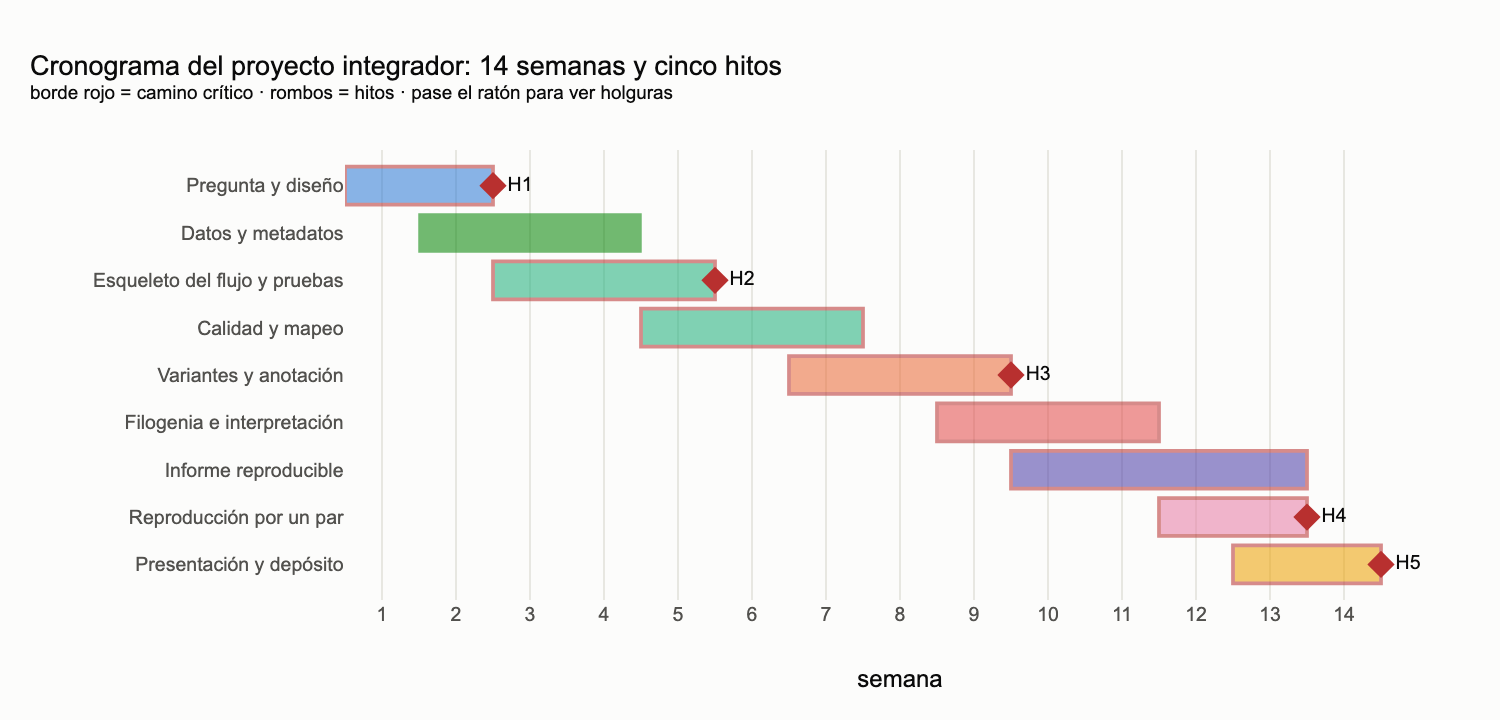

In [52]:
fig = go.Figure()
names = list(TASKS)[::-1]
for t in names:
    r = plan.loc[t]
    dur, col, ms = TASKS[t]
    crit = r["holgura h"] == 0
    fig.add_trace(go.Bar(
        y=[t], x=[r["duración d"]], base=[r["inicio a"] - 1], orientation="h", marker=dict(color=col, opacity=0.55,
        line=dict(color="#b8302f" if crit else col, width=2.5 if crit else 1)), showlegend=False,
        hovertemplate=(f"<b>{t}</b><br>semanas {r['inicio a']}–{r['fin b']} (d = {r['duración d']})<br>"
                       f"holgura: {r['holgura h']} semana(s)" + ("<br><b>en el camino crítico</b>: un retraso aquí retrasa la entrega"
                       if crit else "<br>puede retrasarse sin mover la entrega") +
                       (f"<br>cierra el hito {ms}" if ms else "") + "<extra></extra>")))
MS = [("H1", 2, "propuesta aprobada"), ("H2", 5, "el flujo corre con datos de prueba"), ("H3", 9, "resultados preliminares"),
      ("H4", 13, "un par reproduce el análisis"), ("H5", 14, "entrega final")]
task_of = {v[2]: t for t, v in TASKS.items() if v[2]}
fig.add_trace(go.Scatter(x=[w for _, w, _ in MS], y=[task_of[h] for h, _, _ in MS], mode="markers+text",
                         marker=dict(symbol="diamond", size=14, color="#b8302f"), text=[h for h, _, _ in MS],
                         textposition="middle right", showlegend=False,
                         customdata=[[h, txt] for h, _, txt in MS],
                         hovertemplate="<b>%{customdata[0]}</b> · semana %{x}<br>%{customdata[1]}<extra></extra>"))
fig.update_layout(title="Cronograma del proyecto integrador: 14 semanas y cinco hitos<br>"
                        "<sup>borde rojo = camino crítico · rombos = hitos · pase el ratón para ver holguras</sup>",
                  barmode="overlay", xaxis=dict(title="semana", tickmode="array", tickvals=[k - 0.5 for k in range(1, 15)],
                                                ticktext=[str(k) for k in range(1, 15)], range=[0, 15], showgrid=True,
                                                gridcolor=ec.GRID),
                  height=480, margin=dict(l=230, t=100, r=30))
fig.show()

Y ahora en movimiento: el semestre semana a semana, con la parte ya ejecutada de cada tarea en color sólido y los hitos
encendiéndose al cumplirse.

![El semestre del proyecto semana a semana: las tareas avanzan en paralelo, los hitos se encienden al cumplirse y el borde rojo marca el camino crítico.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-18-flujos-proyecto/18.2_cronograma.gif)

*El semestre del proyecto semana a semana: las tareas avanzan en paralelo, los hitos se encienden al cumplirse y el borde rojo marca el camino crítico.*

In [53]:
fig, ax = plt.subplots(figsize=(12, 5.2), layout=None)
order_t = list(TASKS)
steps = np.arange(0, 14.01, 0.5)

def update(k):
    ax.clear()
    now = steps[k]
    for y, t in enumerate(order_t):
        r = plan.loc[t]
        col = TASKS[t][1]
        a0, b1 = r["inicio a"] - 1, r["fin b"]
        crit = r["holgura h"] == 0
        ax.barh(y, b1 - a0, left=a0, height=0.56, color=col, alpha=0.18,
                edgecolor="#b8302f" if crit else col, lw=1.8 if crit else 0.8)
        done = min(max(now - a0, 0), b1 - a0)
        if done > 0:
            ax.barh(y, done, left=a0, height=0.56, color=col, alpha=0.9)
        ax.text(-0.2, y, t, ha="right", va="center", fontsize=9.5)
    for h, w, txt in MS:
        y = order_t.index(task_of[h])
        on = now >= w
        ax.scatter(w, y, marker="D", s=90, color="#b8302f" if on else "white", edgecolor="#b8302f", zorder=5, lw=1.5)
        ax.text(w + 0.18, y - 0.33, h, fontsize=9, fontweight="bold", color="#b8302f" if on else ec.MUTED)
    ax.axvline(now, color=ec.INK, lw=1.2)
    ax.set_xlim(0, 14.6); ax.set_ylim(len(order_t) - 0.4, -0.7)
    ax.set_yticks([])
    ax.set_xticks(np.arange(0.5, 14, 1)); ax.set_xticklabels([str(k) for k in range(1, 15)])
    ax.set_xlabel("semana")
    active = [t for t in order_t if plan.loc[t, "inicio a"] - 1 < now <= plan.loc[t, "fin b"]]
    done_ms = [h for h, w, _ in MS if now >= w]
    ec.title(ax, f"Semana {now:.1f} · hitos cumplidos: {', '.join(done_ms) if done_ms else 'ninguno'}".replace(".0 ", " ").replace(".5", ",5"),
             "en curso: " + (", ".join(active) if active else "—"))

fig.subplots_adjust(left=0.25, right=0.98, top=0.86, bottom=0.12)
ec.animate(fig, update, frames=len(steps), interval=350, name="18.2_cronograma")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En la semana 3 conviven tres tareas (diseño cerrándose, datos y esqueleto), y hacia la semana 12
> otras tres (filogenia terminada, informe y reproducción). El hito H2 llega **antes** de tener los datos reales
> completos: la prueba de integración de la sección 5 es lo que lo hace posible.

> 🤔 **Antes de ejecutar, prediga.** Si la descarga y curación de datos se retrasa **2** semanas, ¿se mueve la entrega?
> ¿Y si el mapeo se retrasa **1**?

In [54]:
scen = [("sin retrasos", {}), ("datos +2 semanas", {"Datos y metadatos": 2}), ("datos +3 semanas", {"Datos y metadatos": 3}),
        ("mapeo +1 semana", {"Calidad y mapeo": 1}), ("informe +1 semana", {"Informe reproducible": 1}),
        ("reproducción +1 semana", {"Reproducción por un par": 1})]
display(pd.DataFrame([(name, cpm(extra=ex)[1]) for name, ex in scen], columns=["escenario", "entrega (semana)"]))

,escenario,entrega (semana)
0,sin retrasos,14
1,datos +2 semanas,14
2,datos +3 semanas,15
3,mapeo +1 semana,15
4,informe +1 semana,15
5,reproducción +1 semana,15


> 🔎 **Qué observamos.** Dos semanas de retraso en los datos se absorben (es exactamente su holgura); la tercera ya mueve la
> entrega. Una sola semana de retraso en el mapeo, en cambio, la mueve de inmediato. Moraleja práctica: proteja las tareas
> críticas (empiece el esqueleto pronto, con datos simulados) y no se preocupe en exceso por las que tienen holgura. El
> hito H4, en el que otra persona reproduce su análisis, es la prueba de fuego del proyecto: resérvele tiempo.

> ✅ **Compruebe su comprensión.** ¿Por qué un desfase negativo ($\ell=-1$) entre filogenia e informe es razonable, pero
> sería peligroso entre mapeo y variantes? *(Respuesta: el informe puede empezar a escribirse con resultados preliminares y
> actualizarse solo, porque es una regla del flujo; llamar variantes sobre mapeos a medio terminar produciría resultados
> incompletos que habría que rehacer.)*

## 10. Rúbrica de evaluación

La rúbrica hace explícito lo que se espera y permite que la **autoevaluación coincida con la evaluación**. Seis criterios,
cada uno puntuado de 1 (insuficiente) a 4 (excelente), con pesos $w_i$ que suman 1. La nota final es la media ponderada

$$
N = \sum_{i=1}^{6} w_i\,x_i, \qquad \sum_{i=1}^{6} w_i = 1,\quad x_i\in\{1,2,3,4\},
$$

que se reescala a la escala de la institución.

| Símbolo | Significado |
|---|---|
| $w_i$ | peso del criterio $i$ en la nota final |
| $x_i$ | nivel alcanzado en el criterio $i$ |
| $N$ | nota ponderada, entre 1 y 4 |

| Criterio | $w_i$ | Nivel 4 (excelente) | Nivel 1 (insuficiente) |
|---|---|---|---|
| Pregunta y diseño | 0,20 | pregunta precisa; datos adecuados y justificados; limitaciones reconocidas | pregunta vaga; datos elegidos por conveniencia |
| Corrección del análisis | 0,20 | métodos apropiados, parámetros justificados, controles de calidad interpretados | errores metodológicos; salidas sin inspeccionar |
| Reproducibilidad | 0,15 | un par reproduce todo con una orden; entornos y datos fijados | pasos manuales; versiones desconocidas |
| Calidad del código y pruebas | 0,15 | flujo legible, modular, con pruebas unitarias y de integración | *script* monolítico, sin pruebas |
| Datos, metadatos y ética | 0,15 | metadatos completos; depósito o plan de depósito; ética atendida | metadatos ausentes; ética ignorada |
| Informe y comunicación | 0,15 | figuras claras generadas por el flujo; conclusiones apoyadas en resultados | figuras copiadas a mano; conclusiones sin sustento |

### 🧮 Ejemplo resuelto (libro): «Aplicar la rúbrica»

Un proyecto obtiene los niveles $x=(4,3,3,4,2,3)$ en los seis criterios, en el orden de la tabla. Su nota es

$$
\begin{aligned}
N &= 0{,}20\cdot4 + 0{,}20\cdot3 + 0{,}15\cdot3 + 0{,}15\cdot4 + 0{,}15\cdot2 + 0{,}15\cdot3\\
  &= 0{,}80+0{,}60+0{,}45+0{,}60+0{,}30+0{,}45 = 3{,}20,
\end{aligned}
$$

es decir, un **80 %** de la nota máxima (**4,0 sobre 5**). El punto débil está en datos, metadatos y ética ($x_5=2$):
subirlo a 4, completando la tabla de metadatos y el plan de depósito, añadiría $0{,}15\times2=0{,}30$ puntos y llevaría la
nota a **3,50 (87,5 %)**. La rúbrica no sólo califica: indica dónde rinde más el esfuerzo que queda.

In [55]:
CRITERIA = ["Pregunta y diseño", "Corrección del análisis", "Reproducibilidad", "Calidad del código y pruebas",
            "Datos, metadatos y ética", "Informe y comunicación"]
W_RUB = np.array([0.20, 0.20, 0.15, 0.15, 0.15, 0.15])

def grade(x, w=W_RUB, scale=5):
    """Nota ponderada N (1-4), porcentaje del máximo, nota en la escala dada y ganancia de subir cada criterio a 4."""
    x = np.asarray(x, float)
    assert np.isclose(w.sum(), 1) and np.all((x >= 1) & (x <= 4))
    N = float(w @ x)
    return {"N": N, "%": 100 * N / 4, f"sobre {scale}": N / 4 * scale,
            "ganancia si sube a 4": {c: round(float(v), 2) for c, v in zip(CRITERIA, w * (4 - x))}}

x_book = [4, 3, 3, 4, 2, 3]
g = grade(x_book)
print(f"x = {x_book}:  N = {g['N']:.2f} / 4  →  {g['%']:.1f} %  →  {g['sobre 5']:.2f} / 5")
print("contribuciones w_i·x_i:", np.round(W_RUB * x_book, 2))
print("ganancia de subir cada criterio a 4:", g["ganancia si sube a 4"])
x_better = [4, 3, 3, 4, 4, 3]
print(f"subiendo x₅ a 4: N = {grade(x_better)['N']:.2f}  ({grade(x_better)['%']:.1f} %)")

x = [4, 3, 3, 4, 2, 3]:  N = 3.20 / 4  →  80.0 %  →  4.00 / 5
contribuciones w_i·x_i: [0.8  0.6  0.45 0.6  0.3  0.45]
ganancia de subir cada criterio a 4: {'Pregunta y diseño': 0.0, 'Corrección del análisis': 0.2, 'Reproducibilidad': 0.15, 'Calidad del código y pruebas': 0.0, 'Datos, metadatos y ética': 0.3, 'Informe y comunicación': 0.15}
subiendo x₅ a 4: N = 3.50  (87.5 %)


> 🔎 **Qué observamos.** $N=3{,}20$, 80 % y 4,0 sobre 5: las cifras del libro. La mayor ganancia posible (0,30) está en
> datos, metadatos y ética; subir un criterio de peso 0,20 de 3 a 4 sólo aporta 0,20. La calculadora interactiva muestra
> esa contabilidad: mueva el deslizador para ver cómo cambia la nota al mejorar el criterio más débil.

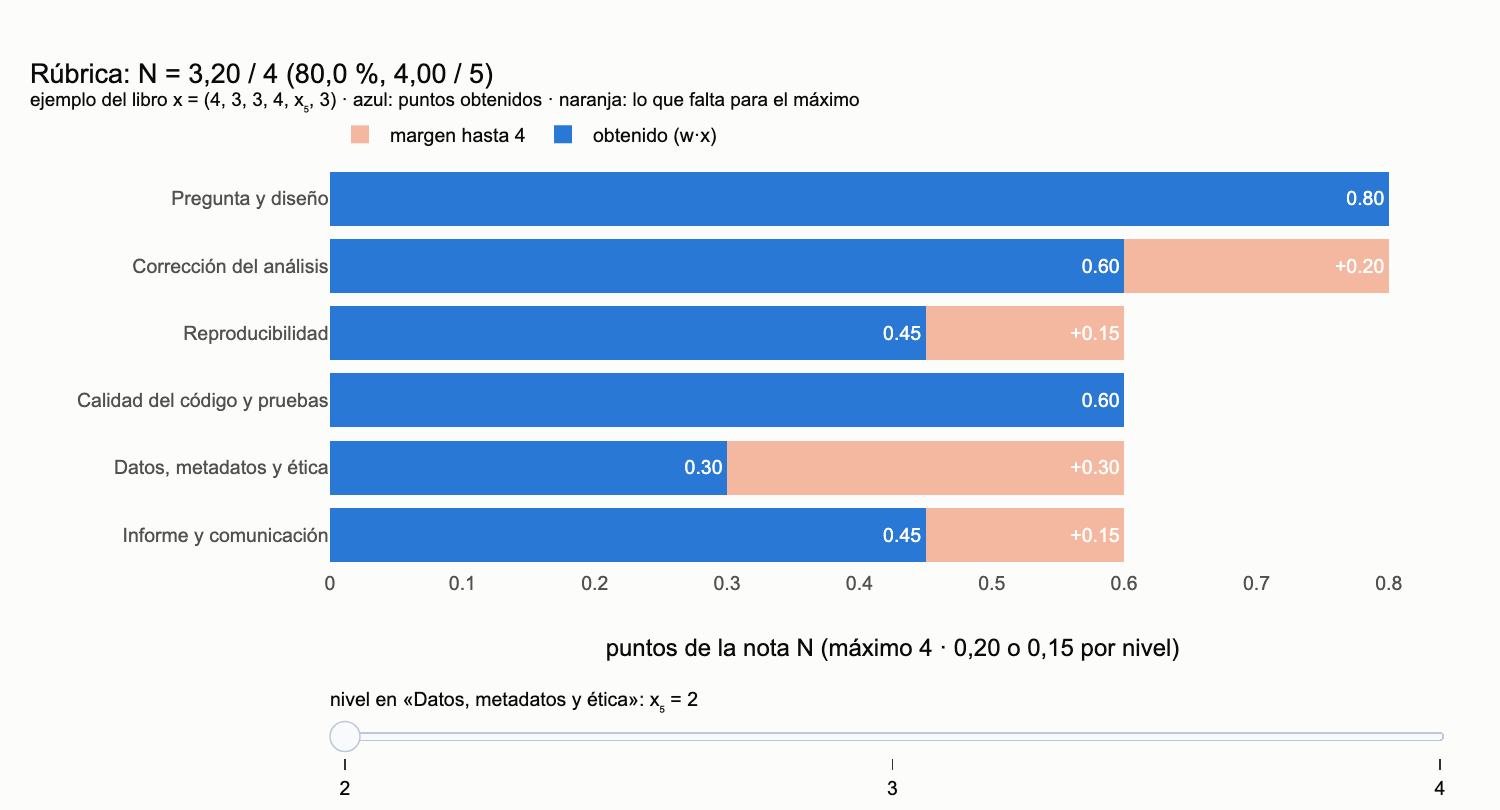

In [56]:
def rubric_traces(x):
    x = np.asarray(x)
    got, gain = W_RUB * x, W_RUB * (4 - x)
    hover_got = [f"<b>{c}</b><br>nivel x = {xi} · peso w = {wi:.2f}<br>aporta w·x = {v:.2f} puntos"
                 for c, xi, wi, v in zip(CRITERIA, x, W_RUB, got)]
    hover_gain = [f"<b>{c}</b><br>subir de {xi} a 4 añadiría {v:.2f} puntos" if v > 0 else f"<b>{c}</b><br>ya en el máximo"
                  for c, xi, v in zip(CRITERIA, x, gain)]
    return [go.Bar(y=CRITERIA, x=got, orientation="h", name="obtenido (w·x)", marker_color=ec.BLUE,
                   text=[f"{v:.2f}" for v in got], textposition="inside", hovertext=hover_got, hoverinfo="text"),
            go.Bar(y=CRITERIA, x=gain, orientation="h", name="margen hasta 4", marker_color=ec.ORANGE, opacity=0.45,
                   text=[f"+{v:.2f}" if v > 0 else "" for v in gain], textposition="inside",
                   hovertext=hover_gain, hoverinfo="text")]

levels = [2, 3, 4]
frames = []
for lv in levels:
    x = [4, 3, 3, 4, lv, 3]
    gg = grade(x)
    frames.append(go.Frame(data=rubric_traces(x), name=str(lv),
                           layout=dict(title_text=f"Rúbrica: N = {gg['N']:.2f} / 4 ({gg['%']:.1f} %, {gg['sobre 5']:.2f} / 5)"
                                       "<br><sup>ejemplo del libro x = (4, 3, 3, 4, x₅, 3) · azul: puntos obtenidos · naranja: "
                                       "lo que falta para el máximo</sup>".replace(".", ",", 3))))
fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
fig.update_layout(barmode="stack", height=540, margin=dict(l=220, t=110, r=30, b=150),
                  xaxis=dict(title="puntos de la nota N (máximo 4 · 0,20 o 0,15 por nivel)", range=[0, 0.85]),
                  yaxis=dict(autorange="reversed"), legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
                  sliders=[dict(active=0, currentvalue=dict(prefix="nivel en «Datos, metadatos y ética»: x₅ = "),
                                pad=dict(t=75), steps=[dict(label=str(lv), method="animate",
                                                            args=[[str(lv)], dict(mode="immediate", frame=dict(duration=300, redraw=True))])
                                                       for lv in levels])])
fig.show()

> 🔎 **Qué observamos.** La longitud total de cada barra (azul + naranja) es $4w_i$: el máximo que cada criterio puede
> aportar. El naranja es el **margen** que queda, y el deslizador muestra el ejemplo del libro: con $x_5=4$ la nota llega a
> 3,50 (87,5 %). En Colab, además, la calculadora siguiente (con `ipywidgets`) permite mover los seis niveles a la vez;
> fuera de Colab basta con llamar a `grade([...])`.

In [57]:
try:
    import ipywidgets as widgets
    sliders = [widgets.IntSlider(value=v, min=1, max=4, description=c[:22], style={"description_width": "170px"},
                                 layout=widgets.Layout(width="420px")) for c, v in zip(CRITERIA, x_book)]
    out = widgets.Output()
    def on_change(_=None):
        with out:
            out.clear_output()
            gg = grade([s.value for s in sliders])
            best = max(gg["ganancia si sube a 4"].items(), key=lambda kv: kv[1])
            print(f"N = {gg['N']:.2f} / 4 · {gg['%']:.1f} % · {gg['sobre 5']:.2f} / 5")
            print(f"donde más rinde el esfuerzo: «{best[0]}» (+{best[1]:.2f})" if best[1] > 0 else "¡nota máxima!")
    for s in sliders:
        s.observe(on_change, names="value")
    on_change()
    if IN_COLAB:
        display(widgets.VBox(sliders + [out]))
    else:
        print("(calculadora interactiva: se muestra en Colab)"); display(out)
except ImportError:
    print("ipywidgets no disponible: use grade([x1, ..., x6])")

ipywidgets no disponible: use grade([x1, ..., x6])


## 11. Ejercicios

**Ejercicio 1 (★).** Rehaga el presupuesto de la opción A para 48 aislados a $30\times$ con lecturas de $2\times150$ pb.
¿Cuánto disco comprimido necesita? ¿Cambia el trabajo $W$ del modelo del libro al pasar de 24 a 48 muestras? Calcule $W$ y
$T_{16}$ con `compute_budget`.

**Ejercicio 2 (★★).** Con la aproximación del cumpleaños, ¿cuántos archivos harían falta para que la probabilidad de una
colisión accidental de SHA-256 alcanzara $10^{-6}$? Compárelo con el orden de magnitud del número de átomos de la Tierra
($\sim10^{50}$).

**Ejercicio 3 (★★).** Mejore `scripts/qc.py`: en lugar de descartar el par cuando una lectura tiene calidad media < 20,
**recorte** su extremo 3′ desde la última base con calidad ≥ 20 (descartando sólo si quedan menos de 50 bases). Escriba
primero una prueba unitaria en `tests/test_anotar.py` (o un archivo nuevo) y después la función. ¿Cuántos pares conserva
ahora la muestra A?

**Ejercicio 4 (★★).** Con `cpm`, ¿cuántas semanas de retraso en «Datos y metadatos» y en «Informe reproducible» tolera el
cronograma sin mover la entrega? Cambie el desfase entre «Filogenia» e «Informe» a $\ell=+1$: ¿en qué semana se entrega?

**Ejercicio 5 (★★).** Con la rúbrica y $x=(4,3,3,4,2,3)$, encuentre **todas** las mejoras de **un solo nivel** en un
criterio y ordénelas por ganancia. ¿Qué combinación mínima de mejoras de un nivel lleva la nota a $N\ge3{,}5$?

**Ejercicio 6 (★★).** Opción B: construya la tabla `muestras.tsv` del experimento *airway* (columnas `muestra`,
`run_accession`, `organismo`, `linea_celular`, `tratamiento`, `estrategia`, `disposicion`, `plataforma`…) a partir de
`airway_SRP033351_samples.tsv` y pásela por `validate`. ¿Qué columnas obligatorias faltan para un depósito y qué valores
INSDC usaría para ellas?

**Ejercicio 7 (★★★).** Diseñe su propio proyecto integrador: escriba la pregunta, elija las accesiones de los datos,
dibuje el grafo de trabajos, estime el presupuesto de disco y cómputo como en el ejemplo «Presupuesto de la opción A»,
redacte la sección de ética y autoevalúe el diseño con la rúbrica. Genere el esqueleto con el código de la sección 3.

In [58]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
b48 = budget(c=30, n=48)
print(f"N = {b48['pares por muestra N']:.3g} pares/muestra · {b48['FASTQ.gz por muestra (GB)']:.3f} GB.gz por muestra "
      f"· total {b48['total gz, n=48 (GB)']:.1f} GB")
for n in (24, 48):
    W, T = compute_budget(n, 16)
    print(f"n = {n}: W = {W:.0f} min = {W / 60:.1f} h-núcleo · T_16 = {T / 60:.2f} h")
print("W crece más que linealmente porque 'llamar' (6+3n) y 'filogenia' (4+2n) crecen con n; el disco no depende del modelo de duraciones.")

N = 4.41e+05 pares/muestra · 0.080 GB.gz por muestra · total 3.8 GB
n = 24: W = 616 min = 10.3 h-núcleo · T_16 = 2.77 h
n = 48: W = 1216 min = 20.3 h-núcleo · T_16 = 5.22 h
W crece más que linealmente porque 'llamar' (6+3n) y 'filogenia' (4+2n) crecen con n; el disco no depende del modelo de duraciones.


In [59]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
# 1 - exp(-n^2 / 2^(b+1)) = p  →  n ≈ sqrt(2^(b+1) · (-ln(1-p))) ≈ sqrt(2^(b+1) · p) para p pequeño
p, b = 1e-6, 256
n_needed = math.sqrt(2 ** (b + 1) * -math.log1p(-p))
print(f"n ≈ {n_needed:.2e} archivos (≈ 10^{math.log10(n_needed):.1f})")
print("Del orden de 10^35: unos catorce órdenes de magnitud menos que los átomos de la Tierra, pero inalcanzable para cualquier archivo real.")

n ≈ 4.81e+35 archivos (≈ 10^35.7)
Del orden de 10^35: unos catorce órdenes de magnitud menos que los átomos de la Tierra, pero inalcanzable para cualquier archivo real.


In [60]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
test_src = """
from scripts.qc import recortar_3p

def test_recorta_cola_de_baja_calidad():
    seq, qual = "ACGTACGTAC", "IIIIIII###"          # I = Q40, # = Q2
    assert recortar_3p(seq, qual, qmin=20, lmin=5) == ("ACGTACG", "IIIIIII")

def test_descarta_si_queda_corta():
    assert recortar_3p("ACGT", "I###", qmin=20, lmin=3) is None
"""
func_src = """

def recortar_3p(seq, qual, qmin=20, lmin=50, offset=33):
    # Recorta el extremo 3' desde la última base con calidad >= qmin; None si quedan menos de lmin bases.
    seq, qual = seq.strip(), qual.strip()
    k = len(qual)
    while k > 0 and ord(qual[k - 1]) - offset < qmin:
        k -= 1
    return (seq[:k], qual[:k]) if k >= lmin else None
"""
sol = os.path.join(TMP, "proyecto-ltee-ej3")
shutil.rmtree(sol, ignore_errors=True)
shutil.copytree(PROJ, sol, ignore=shutil.ignore_patterns(".git", "datos", "ref", "mapeo", "resultados", ".snakemake"))
open(f"{sol}/scripts/qc.py", "a").write(func_src)
open(f"{sol}/tests/test_recorte.py", "w").write(test_src)
p = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider", "tests/"],
                   cwd=sol, capture_output=True, text=True)
print(p.stdout.strip().splitlines()[-1])
# efecto en la muestra A: pares conservados si se recorta en vez de descartar
sys.path.insert(0, sol)
import importlib, scripts.qc as qcmod
importlib.reload(qcmod)
kept = total = 0
with gzip.open(f"{PROJ}/datos/A_R1.fastq.gz", "rt") as f1, gzip.open(f"{PROJ}/datos/A_R2.fastq.gz", "rt") as f2:
    while True:
        a = [f1.readline() for _ in range(4)]; b_ = [f2.readline() for _ in range(4)]
        if not a[0]:
            break
        total += 1
        kept += qcmod.recortar_3p(a[1], a[3]) is not None and qcmod.recortar_3p(b_[1], b_[3]) is not None
sys.path.remove(sol)
print(f"muestra A: {kept} de {total} pares conservados con recorte ({100 * kept / total:.1f} %)")

8 passed in 0.01s
muestra A: 5488 de 5970 pares conservados con recorte (91.9 %)


In [61]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for t in ("Datos y metadatos", "Informe reproducible"):
    tol = max(k for k in range(0, 8) if cpm(extra={t: k})[1] == 14)
    print(f"{t}: tolera {tol} semana(s) de retraso (holgura h = {plan.loc[t, 'holgura h']})")
deps2 = [(u, v, 1 if (u, v) == ("Filogenia e interpretación", "Informe reproducible") else l) for u, v, l in DEPS]
print("con ℓ(filogenia→informe) = +1 la entrega pasa a la semana", cpm(deps=deps2)[1])

Datos y metadatos: tolera 2 semana(s) de retraso (holgura h = 2)
Informe reproducible: tolera 0 semana(s) de retraso (holgura h = 0)
con ℓ(filogenia→informe) = +1 la entrega pasa a la semana 16


In [62]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
import itertools
x0 = np.array([4, 3, 3, 4, 2, 3])
ups = sorted([(float(W_RUB[i]), CRITERIA[i]) for i in range(6) if x0[i] < 4], reverse=True)
print("mejoras de un nivel, por ganancia:", [(c, round(g, 2)) for g, c in ups])
best = None
for k in range(1, 7):
    for combo in itertools.combinations([i for i in range(6) if x0[i] < 4], k):
        x = x0.copy(); x[list(combo)] += 1
        if grade(x)["N"] >= 3.5 - 1e-9:
            best = (k, [CRITERIA[i] for i in combo], grade(x)["N"]); break
    if best:
        break
print(f"mínimo: {best[0]} mejoras de un nivel → N = {best[2]:.2f}: {best[1]}")

mejoras de un nivel, por ganancia: [('Corrección del análisis', 0.2), ('Reproducibilidad', 0.15), ('Informe y comunicación', 0.15), ('Datos, metadatos y ética', 0.15)]
mínimo: 2 mejoras de un nivel → N = 3.55: ['Corrección del análisis', 'Reproducibilidad']


In [63]:
#@title 🔑 Solución — Ejercicio 6 { display-mode: "form" }
mB = pd.DataFrame({"muestra": air.run, "run_accession": air.run, "sample_accession": "",
                   "organismo": "Homo sapiens", "cepa": "", "linea_celular": air.cell, "tratamiento": air.treatment,
                   "fecha_colecta": "", "pais": "", "hospedero": "", "tipo_muestra": "células de músculo liso de vías aéreas",
                   "plataforma": "ILLUMINA", "estrategia": "RNA-Seq", "disposicion": "PAIRED"})
errs = pd.DataFrame(validate(mB), columns=["fila", "columna", "problema"])
print(errs.groupby("columna").size().rename("filas con problema"))
print("\nPara datos humanos: 'cepa' → 'not applicable'; fechas/lugar de colecta → 'not collected' o 'restricted access';"
      "\nhospedero → 'not applicable' (el organismo ya es Homo sapiens); sample_accession → la BioSample (SAMN…) de cada GSM.")

columna
cepa                16
fecha_colecta       32
hospedero           16
pais                16
sample_accession    32
Name: filas con problema, dtype: int64

Para datos humanos: 'cepa' → 'not applicable'; fechas/lugar de colecta → 'not collected' o 'restricted access';
hospedero → 'not applicable' (el organismo ya es Homo sapiens); sample_accession → la BioSample (SAMN…) de cada GSM.


## 📌 Resumen

* El proyecto está **terminado** cuando otra persona, con su repositorio, las accesiones de los datos y una sola orden,
  obtiene las mismas tablas y figuras. Lo comprobamos literalmente: un clon del repositorio reprodujo nuestras tablas con
  huellas SHA-256 idénticas.
* **Dimensionar antes de empezar:** $N=cG/(2L)$ pares por muestra, unos $2N(2L+2+h)$ bytes de FASTQ, y el trabajo $W$ y el
  camino crítico del flujo para decidir cuántos núcleos pedir (ejemplo del libro: 6,4 GB, 10,3 horas-núcleo, 2,8 h con 16
  núcleos).
* **Estructura** (Noble, 2009): datos crudos de sólo lectura y fuera de Git; código, configuración, entornos, pruebas y
  documentación en Git; todo lo demás regenerable con una orden.
* **Reproducibilidad** $R=f(C,\mathcal{E},D,\theta,\omega)$: *commit* y etiqueta, entornos con versiones exactas, accesiones
  y sumas SHA-256 (probabilidad de colisión $\approx 1-e^{-n(n-1)/2^{b+1}}$), configuración versionada y semillas; la coma
  flotante se compara con tolerancias.
* **Pruebas a tres niveles:** unitarias (`pytest`), de integración sobre datos simulados en un clon limpio, y
  comprobaciones de cordura que obligan a explicar (el 85 % de pares conservados, el Ti/Tv bajo).
* **Informe como regla del flujo**, con procedencia (versiones, *commit*, huellas): ningún número copiado a mano.
* **Metadatos FAIR** en la misma tabla que alimenta el flujo, validados y nunca pasados por una hoja de cálculo; **ética**
  planificada desde el diseño: acceso controlado, eliminación de lecturas humanas, resolución reducida ($k$-anonimato).
* **Cronograma** con camino crítico y **rúbrica** $N=\sum w_i x_i$: planifican dónde rinde el esfuerzo.

## 📚 Lecturas recomendadas

* Noble, W. S. (2009). A quick guide to organizing computational biology projects. *PLoS Computational Biology*, 5(7),
  e1000424. https://doi.org/10.1371/journal.pcbi.1000424
* Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L. y Teal, T. K. (2017). Good enough practices in scientific
  computing. *PLOS Computational Biology*, 13(6), e1005510. https://doi.org/10.1371/journal.pcbi.1005510
* Sandve, G. K., Nekrutenko, A., Taylor, J. y Hovig, E. (2013). Ten simple rules for reproducible computational research.
  *PLoS Computational Biology*, 9(10), e1003285. https://doi.org/10.1371/journal.pcbi.1003285
* Peng, R. D. (2011). Reproducible research in computational science. *Science*, 334(6060), 1226–1227.
  https://doi.org/10.1126/science.1213847
* Grüning, B. *et al.* (2018). Practical computational reproducibility in the life sciences. *Cell Systems*, 6(6),
  631–635. https://doi.org/10.1016/j.cels.2018.03.014
* Perez-Riverol, Y. *et al.* (2016). Ten simple rules for taking advantage of Git and GitHub. *PLOS Computational
  Biology*, 12(7), e1004947. https://doi.org/10.1371/journal.pcbi.1004947
* Rule, A. *et al.* (2019). Ten simple rules for writing and sharing computational analyses in Jupyter Notebooks.
  *PLOS Computational Biology*, 15(7), e1007007. https://doi.org/10.1371/journal.pcbi.1007007
* Mölder, F. *et al.* (2021). Sustainable data analysis with Snakemake. *F1000Research*, 10, 33.
  https://doi.org/10.12688/f1000research.29032.2
* Ewels, P., Magnusson, M., Lundin, S. y Käller, M. (2016). MultiQC: summarize analysis results for multiple tools and
  samples in a single report. *Bioinformatics*, 32(19), 3047–3048. https://doi.org/10.1093/bioinformatics/btw354
* Ewels, P. A. *et al.* (2020). The nf-core framework for community-curated bioinformatics pipelines. *Nature
  Biotechnology*, 38(3), 276–278. https://doi.org/10.1038/s41587-020-0439-x
* Leinonen, R., Sugawara, H. y Shumway, M. (2011). The Sequence Read Archive. *Nucleic Acids Research*, 39(Database),
  D19–D21. https://doi.org/10.1093/nar/gkq1019
* Leinonen, R. *et al.* (2011). The European Nucleotide Archive. *Nucleic Acids Research*, 39(Database), D28–D31.
  https://doi.org/10.1093/nar/gkq967
* Wilkinson, M. D. *et al.* (2016). The FAIR Guiding Principles for scientific data management and stewardship.
  *Scientific Data*, 3, 160018. https://doi.org/10.1038/sdata.2016.18
* Ziemann, M., Eren, Y. y El-Osta, A. (2016). Gene name errors are widespread in the scientific literature. *Genome
  Biology*, 17, 177. https://doi.org/10.1186/s13059-016-1044-7
* Gymrek, M., McGuire, A. L., Golan, D., Halperin, E. y Erlich, Y. (2013). Identifying personal genomes by surname
  inference. *Science*, 339(6117), 321–324. https://doi.org/10.1126/science.1229566
* Shabani, M. y Borry, P. (2018). Rules for processing genetic data for research purposes in view of the new EU General
  Data Protection Regulation. *European Journal of Human Genetics*, 26(2), 149–156. https://doi.org/10.1038/s41431-017-0045-7
* Hadfield, J. *et al.* (2018). Nextstrain: real-time tracking of pathogen evolution. *Bioinformatics*, 34(23), 4121–4123.
  https://doi.org/10.1093/bioinformatics/bty407
* Kahn, A. B. (1962). Topological sorting of large networks. *Communications of the ACM*, 5(11), 558–562.
  https://doi.org/10.1145/368996.369025
* Tenaillon, O. *et al.* (2016). Tempo and mode of genome evolution in a 50,000-generation experiment. *Nature*, 536,
  165–170. https://doi.org/10.1038/nature18959
* Himes, B. E. *et al.* (2014). RNA-Seq transcriptome profiling identifies CRISPLD2 as a glucocorticoid responsive gene
  that modulates cytokine function in airway smooth muscle cells. *PLoS ONE*, 9(6), e99625.
  https://doi.org/10.1371/journal.pone.0099625

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)